# 24 — Mask Robustness Analysis

**Origin:** New analysis stage separated from Notebook 06 generation\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/24_mask_robustness_analysis/`\
**Depends on:** Notebooks 06, 08–17, 20, and 21

## Purpose

Measure how strongly restoration evidence changes when the placement, geometry, or component arrangement of a binary damage mask changes while damaged area remains approximately matched.

The analysis uses the controlled mask-robustness experiment generated by Notebook 06:

- five paintings;
- three mask families per painting;
- five variants per painting–family group;
- 15 robustness groups;
- 75 restoration cases;
- OpenCV Telea, LaMa, and Stable Diffusion Inpainting;
- 225 preselected primary restoration candidates.

Stable Diffusion uses its primary generic-prompt candidate with seed `2026`. Candidate selection is fixed before metric inspection.

## Approved robustness interpretation

This notebook measures **input-mask robustness**, not stochastic model uncertainty.

A model is more robust when its quality evidence and relative ranking change less across the five matched mask variants. Low variation does not prove that a restoration is correct, historically authentic, visually acceptable, or conservation appropriate.

## Main analyses

The notebook evaluates:

- mask-area matching and geometric distinctness;
- within-group quality dispersion using standard deviation, median absolute deviation, and range;
- paired model differences in primary dispersion;
- family-balanced model ranks for every mask variant;
- model-ranking and anchor-winner stability;
- conclusions that change with mask realization;
- exploratory relationships with mask location and morphology;
- painting-specific and mask-family robustness profiles;
- runtime dispersion as separate operational evidence;
- representative restoration panels and failure cases.

No combined quality score or trust score is created.

## Critical design boundary

Mask family and target damaged area are deliberately paired:

- `scratch_thin`: 2%;
- `loss_small`: 4.5%;
- `loss_large`: 12.5%.

Consequently, this notebook may describe family-specific robustness profiles but cannot estimate independent mask-family or damage-size effects. Notebook 23 remains the canonical damage-size analysis.

The five paintings—not the 75 cases—are the independent units. Mask variants are repeated observations nested within painting–family groups.

## Canonical outputs

- `metrics/mask_robustness_analysis.csv`
- `figures/robustness_variance.png`
- `figures/ranking_stability.png`
- `reports/mask_robustness_analysis.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads and validates the approved Notebook 24 configuration;
- defines the complete input and output contract;
- checks the refreshed inventory and governance records;
- verifies every direct upstream completion gate;
- confirms the fixed population and analysis-row arithmetic;
- enforces the family–area confounding boundary;
- verifies that unsupported scientific claims remain disabled;
- creates only Notebook 24's owned output directories.

It does not load full metric tables, perform analysis, generate figures, or write canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.mask_robustness_analysis import (
    ANALYSIS_COLUMNS,
    ANALYSIS_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    DISPERSION_NAMES,
    MODULE_NAME,
    MODULE_VERSION,
    atomic_write_csv,
    benjamini_hochberg,
    build_multi_model_adapter_config,
    build_runtime_evidence,
    compute_group_dispersion,
    compute_variant_family_balanced_ranks,
    dispersion_statistics,
    empty_analysis_frame,
    exact_sign_flip_test,
    exhaustive_bootstrap_interval,
    family_balanced_ranks,
    load_mask_robustness_analysis_config,
    matched_rank_biserial,
    normalise_quality_evidence,
    resolve_analysis_inputs,
    select_mask_robustness_population,
    select_quality_anchor_values,
    validate_mask_robustness_analysis,
    validate_mask_robustness_report_html,
    validate_upstream_run_manifests,
    within_group_centered_spearman,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 140)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()

print("Notebook 24 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 24 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.mask_robustness_analysis 1.0.0


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "mask_robustness_analysis.yaml"
)

ANALYSIS_CONFIG = load_mask_robustness_analysis_config(CONFIG_PATH)
SETTINGS = ANALYSIS_CONFIG["mask_robustness_analysis"]

INPUT_PATHS = resolve_analysis_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (PROJECT_ROOT / OUTPUT_SPEC["root"]).resolve()

OUTPUT_PATHS = {
    "metrics": OUTPUT_ROOT / OUTPUT_SPEC["metrics_path"],
    "robustness_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["robustness_figure_path"]
    ),
    "ranking_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["ranking_figure_path"]
    ),
    "report": OUTPUT_ROOT / OUTPUT_SPEC["report_path"],
    "run_manifest": OUTPUT_ROOT / OUTPUT_SPEC["run_manifest_path"],
    "artifacts": OUTPUT_ROOT / OUTPUT_SPEC["artifacts_path"],
    "validation": OUTPUT_ROOT / OUTPUT_SPEC["validation_path"],
}

WORK_ROOT = OUTPUT_ROOT / OUTPUT_SPEC["work_root"]
CANONICAL_OUTPUT_PATHS = tuple(OUTPUT_PATHS.values())

preexisting_output_files = (
    sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file())
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(parents=True, exist_ok=True)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in (*CANONICAL_OUTPUT_PATHS, WORK_ROOT)
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="supported_python_version",
    check_description="Python uses an approved major and minor version.",
    severity="blocking",
    expected=["3.11", "3.12"],
    observed=f"{sys.version_info.major}.{sys.version_info.minor}",
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="configuration_schema_version",
    check_description="The loaded configuration uses the supported schema.",
    severity="blocking",
    expected=CONFIG_SCHEMA_VERSION,
    observed=ANALYSIS_CONFIG["config_schema_version"],
    passed=(
        ANALYSIS_CONFIG["config_schema_version"]
        == CONFIG_SCHEMA_VERSION
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="analysis_schema_version",
    check_description="The configured analysis schema matches the helper.",
    severity="blocking",
    expected=ANALYSIS_SCHEMA_VERSION,
    observed=SETTINGS["analysis_schema_version"],
    passed=(
        SETTINGS["analysis_schema_version"]
        == ANALYSIS_SCHEMA_VERSION
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="all_declared_inputs_exist",
    check_description="Every explicitly declared Notebook 24 input exists.",
    severity="blocking",
    expected=len(SETTINGS["inputs"]),
    observed=sum(path.exists() for path in INPUT_PATHS.values()),
    passed=all(path.exists() for path in INPUT_PATHS.values()),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="output_path_ownership",
    check_description="Every output is inside Notebook 24's owned root.",
    severity="blocking",
    expected=OUTPUT_SPEC["root"],
    observed=str(
        OUTPUT_ROOT.relative_to(PROJECT_ROOT)
    ).replace("\\", "/"),
    passed=paths_inside_output_root,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_output_count",
    check_description="The contract contains exactly seven canonical files.",
    severity="blocking",
    expected=SETTINGS["expected_counts"]["canonical_output_files"],
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == int(
            SETTINGS["expected_counts"]["canonical_output_files"]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="initial_output_state_recorded",
    check_description=(
        "Existing Notebook 24 files are recorded without deletion."
    ),
    severity="info",
    expected="informational",
    observed={
        "preexisting_file_count": len(preexisting_output_files),
        "paths": [
            str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
            for path in preexisting_output_files
        ],
    },
    passed=True,
)

print("Configuration and path contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS)}")
print(f"Canonical outputs: {len(CANONICAL_OUTPUT_PATHS)}")
print(f"Pre-existing output files: {len(preexisting_output_files)}")

Configuration and path contract validated.
Declared inputs: 36
Canonical outputs: 7
Pre-existing output files: 0


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

evidence_audit_lower = EVIDENCE_AUDIT_TEXT.lower()

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/mask_robustness_analysis.yaml",
    "src/restoration_eval/mask_robustness_analysis.py",
    "tests/test_mask_robustness_analysis.py",
    "notebooks/24_mask_robustness_analysis.ipynb",
}

registered_artifacts = {
    str(record["artifact_key"]): record
    for record in PROJECT_PATHS_REGISTRY.get("artifacts", [])
}

required_registry_keys = {
    "dataset.artworks",
    "mask_robustness.cases",
    "mask_robustness.generation_audit",
    "mask_robustness.masks",
    "mask_robustness.damaged_images",
    "experiment_contracts.case_registry",
    "experiment_contracts.model_eligibility",
    "experiment_contracts.region_policy",
    "opencv_telea.restorations",
    "lama.restorations",
    "stable_diffusion.candidates",
    "classical_metrics.metrics",
    "lpips_metrics.metrics",
    "feature_similarity.metrics",
    "spatial_diagnostics.metrics",
    "local_consistency.metrics",
    "semantic_structural.metrics",
    "multi_model_comparison.metrics",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get("planned_notebooks", [])
}

n23_coverage = planned_notebooks.get("23", {})
n24_coverage = planned_notebooks.get("24", {})

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get("summary", {}).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

audit_mentions_n24 = (
    "notebook 24" in evidence_audit_lower
    or "| 24 mask robustness |" in evidence_audit_lower
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="inventory_run_completed",
    check_description=(
        "The current inventory completed without read errors."
    ),
    severity="blocking",
    expected={"status": "completed", "read_error_count": 0},
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": INVENTORY_RUN.get(
            "summary",
            {},
        ).get("read_error_count"),
        "inventory_run_id": INVENTORY_RUN.get(
            "inventory_run_id"
        ),
    },
    passed=inventory_status_ok,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="preparation_files_in_inventory",
    check_description="Notebook 24 preparation files are indexed.",
    severity="blocking",
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths & inventory_relative_paths
    ),
    passed=required_preparation_paths.issubset(
        inventory_relative_paths
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="required_artifacts_registered",
    check_description=(
        "Every required upstream artifact is registered."
    ),
    severity="blocking",
    expected=sorted(required_registry_keys),
    observed=sorted(
        required_registry_keys & set(registered_artifacts)
    ),
    passed=required_registry_keys.issubset(
        registered_artifacts
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_23_evidence_frozen",
    check_description=(
        "Notebook 23 is completed and available without modification."
    ),
    severity="blocking",
    expected={
        "status": "completed_validation_passed",
        "completion_gate_passed": True,
    },
    observed=n23_coverage,
    passed=(
        n23_coverage.get("status")
        == "completed_validation_passed"
        and bool(n23_coverage.get("completion_gate_passed"))
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_24_evidence_ready",
    check_description=(
        "Notebook 24 is registered as a supported planned analysis."
    ),
    severity="blocking",
    expected="planned_supported",
    observed=n24_coverage.get("status"),
    passed=(
        n24_coverage.get("status")
        == "planned_supported"
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evidence_audit_covers_notebook_24",
    check_description=(
        "The evidence dependency audit contains Notebook 24."
    ),
    severity="blocking",
    expected="24 Mask robustness",
    observed={
        "audit_row_present": (
            "| 24 mask robustness |"
            in evidence_audit_lower
        ),
    },
    passed=audit_mentions_n24,
)

print("Inventory and governance records loaded.")
print(f"Inventory run: {INVENTORY_RUN['inventory_run_id']}")
print(f"Inventory rows: {len(INVENTORY):,}")
print(f"Registered artifacts: {len(registered_artifacts):,}")
print(f"Notebook 24 audit coverage: {audit_mentions_n24}")

Inventory and governance records loaded.
Inventory run: inventory_20260901T092734Z_57040f3f
Inventory rows: 18,753
Registered artifacts: 135
Notebook 24 audit coverage: True


In [4]:
UPSTREAM_MANIFEST_INPUTS = {
    "06": "mask_robustness_run_manifest_path",
    "08": "contracts_run_manifest_path",
    "09": "opencv_run_manifest_path",
    "10": "lama_run_manifest_path",
    "11": "stable_diffusion_run_manifest_path",
    "13": "classical_run_manifest_path",
    "14": "lpips_run_manifest_path",
    "15": "feature_run_manifest_path",
    "16": "spatial_run_manifest_path",
    "17": "local_run_manifest_path",
    "20": "semantic_run_manifest_path",
    "21": "comparison_run_manifest_path",
}

UPSTREAM_MANIFESTS = {}

for notebook_id, input_key in UPSTREAM_MANIFEST_INPUTS.items():
    with INPUT_PATHS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        UPSTREAM_MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_MANIFEST_STATUS = validate_upstream_run_manifests(
    UPSTREAM_MANIFESTS
)

for row in UPSTREAM_MANIFEST_STATUS.itertuples(index=False):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=(
            f"upstream_notebook_{row.notebook_id}_completion_gate"
        ),
        check_description=(
            f"Notebook {row.notebook_id} completed with "
            "passed validation."
        ),
        severity="blocking",
        expected={
            "run_status": "completed",
            "validation_status": "passed",
            "completion_gate_passed": True,
        },
        observed={
            "run_status": row.run_status,
            "validation_status": row.validation_status,
            "completion_gate_passed": bool(
                row.completion_gate_passed
            ),
        },
        passed=bool(row.passed),
    )

display(UPSTREAM_MANIFEST_STATUS)

print("Direct upstream manifests checked.")
print(
    "Passed completion gates: "
    f"{int(UPSTREAM_MANIFEST_STATUS['passed'].sum())}/"
    f"{len(UPSTREAM_MANIFEST_STATUS)}"
)

,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,06,True,completed,passed,True,True
1,08,True,completed,passed,True,True
2,09,True,completed,passed,True,True
3,10,True,completed,passed,True,True
4,11,True,completed,passed,True,True
5,13,True,completed,passed,True,True
6,14,True,completed,passed,True,True
7,15,True,completed,passed,True,True
8,16,True,completed,passed,True,True
9,17,True,completed,passed,True,True


Direct upstream manifests checked.
Passed completion gates: 12/12


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
STATISTICS = SETTINGS["statistics"]
REPORT = SETTINGS["report"]
POLICY = SETTINGS["evidence_policy"]

population_contract = pd.DataFrame(
    [
        ("Paintings", EXPECTED["paintings"]),
        ("Mask families", EXPECTED["mask_families"]),
        ("Robustness groups", EXPECTED["robustness_groups"]),
        ("Variants per group", EXPECTED["variants_per_group"]),
        ("Cases", EXPECTED["cases"]),
        ("Primary candidates", EXPECTED["candidates"]),
        ("Quality anchors", EXPECTED["quality_anchors"]),
        (
            "Normalized quality rows",
            EXPECTED["normalized_quality_rows"],
        ),
        ("Runtime rows", EXPECTED["runtime_rows"]),
        (
            "Canonical analysis rows",
            EXPECTED["canonical_analysis_rows"],
        ),
        (
            "Canonical output files",
            EXPECTED["canonical_output_files"],
        ),
    ],
    columns=["contract_item", "expected_count"],
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
            "exists_before_analysis": path.exists(),
        }
        for artifact, path in OUTPUT_PATHS.items()
    ]
)

family_area_contract = pd.DataFrame(
    [
        {
            "mask_family": family,
            "target_damage_fraction": float(fraction),
            "target_damage_percent": 100.0 * float(fraction),
        }
        for family, fraction in POPULATION[
            "target_damage_fraction_by_family"
        ].items()
    ]
)

analysis_row_keys = [
    f"{analysis_kind}_rows"
    for analysis_kind in SETTINGS["analysis_kinds"]
]

computed_analysis_rows = sum(
    int(EXPECTED[key])
    for key in analysis_row_keys
)

prohibited_policy_keys = [
    "independent_mask_family_effect_permitted",
    "independent_damage_size_effect_permitted",
    "category_effect_permitted",
    "style_effect_permitted",
    "stochastic_uncertainty_claim_permitted",
    "historical_authenticity_claim_permitted",
    "conservation_approval_claim_permitted",
    "runtime_is_quality_evidence",
]

prohibited_claims_disabled = all(
    not bool(POLICY[key])
    for key in prohibited_policy_keys
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="population_arithmetic",
    check_description=(
        "The fixed mask-robustness population is internally consistent."
    ),
    severity="blocking",
    expected={
        "groups": 15,
        "cases": 75,
        "candidates": 225,
    },
    observed={
        "groups": (
            int(EXPECTED["paintings"])
            * int(EXPECTED["mask_families"])
        ),
        "cases": (
            int(EXPECTED["robustness_groups"])
            * int(EXPECTED["variants_per_group"])
        ),
        "candidates": sum(
            int(value)
            for value in EXPECTED[
                "candidates_by_model"
            ].values()
        ),
    },
    passed=(
        int(EXPECTED["paintings"])
        * int(EXPECTED["mask_families"])
        == 15
        and int(EXPECTED["robustness_groups"])
        * int(EXPECTED["variants_per_group"])
        == 75
        and sum(
            int(value)
            for value in EXPECTED[
                "candidates_by_model"
            ].values()
        )
        == 225
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_analysis_row_arithmetic",
    check_description=(
        "The eleven approved analysis blocks total 5,373 rows."
    ),
    severity="blocking",
    expected=EXPECTED["canonical_analysis_rows"],
    observed=computed_analysis_rows,
    passed=(
        computed_analysis_rows
        == int(EXPECTED["canonical_analysis_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="model_scope",
    check_description=(
        "The analysis uses the three approved restoration models."
    ),
    severity="blocking",
    expected=[
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    ],
    observed=list(POPULATION["model_order"]),
    passed=list(POPULATION["model_order"])
    == [
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    ],
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="metric_independent_candidate_selection",
    check_description=(
        "Stable Diffusion selection is fixed before metric inspection."
    ),
    severity="blocking",
    expected={
        "role": "primary",
        "prompt_variant": "p00_generic",
        "seed": 2026,
        "metric_independent": True,
    },
    observed={
        "role": POPULATION[
            "stable_diffusion_primary_role"
        ],
        "prompt_variant": POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ],
        "seed": POPULATION[
            "stable_diffusion_primary_seed"
        ],
        "metric_independent": POPULATION[
            "metric_independent_selection"
        ],
    },
    passed=(
        POPULATION["stable_diffusion_primary_role"]
        == "primary"
        and POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ]
        == "p00_generic"
        and int(
            POPULATION["stable_diffusion_primary_seed"]
        )
        == 2026
        and bool(
            POPULATION["metric_independent_selection"]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="family_area_confounding_locked",
    check_description=(
        "Each mask family remains paired with one fixed target area."
    ),
    severity="blocking",
    expected={
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
    observed=dict(
        POPULATION["target_damage_fraction_by_family"]
    ),
    passed=dict(
        POPULATION["target_damage_fraction_by_family"]
    )
    == {
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="independent_unit_and_exact_inference",
    check_description=(
        "Inference uses five paintings and exact small-sample methods."
    ),
    severity="blocking",
    expected={
        "independent_unit": "painting",
        "bootstrap_resamples": 3125,
        "sign_flip_assignments": 32,
    },
    observed={
        "independent_unit": STATISTICS["independent_unit"],
        "bootstrap_resamples": STATISTICS[
            "bootstrap_resamples"
        ],
        "sign_flip_assignments": STATISTICS[
            "sign_flip_assignments"
        ],
    },
    passed=(
        STATISTICS["independent_unit"] == "painting"
        and int(STATISTICS["bootstrap_resamples"]) == 3125
        and int(STATISTICS["sign_flip_assignments"]) == 32
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="robustness_terminology",
    check_description=(
        "Input-mask robustness is not labeled stochastic uncertainty."
    ),
    severity="blocking",
    expected=False,
    observed=STATISTICS["use_uncertainty_terminology"],
    passed=not bool(
        STATISTICS["use_uncertainty_terminology"]
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="prohibited_claims_disabled",
    check_description=(
        "Unsupported scientific claims remain disabled."
    ),
    severity="blocking",
    expected=True,
    observed=prohibited_claims_disabled,
    passed=prohibited_claims_disabled,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="no_combined_quality_score",
    check_description=(
        "No combined quality or trust score is enabled."
    ),
    severity="blocking",
    expected=False,
    observed=STATISTICS["combined_quality_score_retained"],
    passed=not bool(
        STATISTICS["combined_quality_score_retained"]
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="approved_report_structure_locked",
    check_description=(
        "The final report must retain the approved 13-section mock."
    ),
    severity="blocking",
    expected={
        "locked": True,
        "section_count": 13,
        "evidence_to_assertion": True,
    },
    observed={
        "locked": REPORT[
            "approved_mock_structure_locked"
        ],
        "section_count": len(
            REPORT["required_section_ids"]
        ),
        "evidence_to_assertion": REPORT[
            "require_evidence_to_assertion_pairs"
        ],
    },
    passed=(
        bool(REPORT["approved_mock_structure_locked"])
        and len(REPORT["required_section_ids"]) == 13
        and bool(
            REPORT["require_evidence_to_assertion_pairs"]
        )
    ),
)

BATCH_1_CHECKS = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

display(population_contract)
display(family_area_contract)
display(output_contract)
display(BATCH_1_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 1 passed.")
print(f"Validation checks: {BATCH_1_SUMMARY['check_count']}")
print(
    "Blocking failures: "
    f"{BATCH_1_SUMMARY['blocking_failure_count']}"
)
print("No canonical Notebook 24 artifact has been written.")
print("Next batch: population and evidence loading.")

,contract_item,expected_count
0,Paintings,5
1,Mask families,3
2,Robustness groups,15
3,Variants per group,5
4,Cases,75
5,Primary candidates,225
6,Quality anchors,11
7,Normalized quality rows,72225
8,Runtime rows,225
9,Canonical analysis rows,5373


,mask_family,target_damage_fraction,target_damage_percent
0,scratch_thin,0.020,2.0
1,loss_small,0.045,4.5
2,loss_large,0.125,12.5


,artifact,relative_path,exists_before_analysis
0,metrics,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,False
1,robustness_figure,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,False
2,ranking_figure,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,False
3,report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,False
4,run_manifest,outputs/24_mask_robustness_analysis/manifests/run_manifest.json,False
5,artifacts,outputs/24_mask_robustness_analysis/manifests/artifacts.csv,False
6,validation,outputs/24_mask_robustness_analysis/validation/checks.csv,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_schema_version,The loaded configuration uses the supported schema.,blocking,mask_robustness_analysis_config.v1,mask_robustness_analysis_config.v1,True,
2,batch_1_preflight,analysis_schema_version,The configured analysis schema matches the helper.,blocking,mask_robustness_analysis.v1,mask_robustness_analysis.v1,True,
3,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 24 input exists.,blocking,36,36,True,
4,batch_1_preflight,output_path_ownership,Every output is inside Notebook 24's owned root.,blocking,outputs/24_mask_robustness_analysis,outputs/24_mask_robustness_analysis,True,
5,batch_1_preflight,canonical_output_count,The contract contains exactly seven canonical files.,blocking,7,7,True,
6,batch_1_preflight,initial_output_state_recorded,Existing Notebook 24 files are recorded without deletion.,info,informational,"{""paths"": [], ""preexisting_file_count"": 0}",True,
7,batch_1_preflight,inventory_run_completed,The current inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260901T092734Z_57040f3f"", ""read_error_count"": 0, ""status"": ""completed""}",True,
8,batch_1_preflight,preparation_files_in_inventory,Notebook 24 preparation files are indexed.,blocking,"[""config/evaluation/mask_robustness_analysis.yaml"", ""notebooks/24_mask_robustness_analysis.ipynb"", ""src/restoration_eval/mask_robustness...","[""config/evaluation/mask_robustness_analysis.yaml"", ""notebooks/24_mask_robustness_analysis.ipynb"", ""src/restoration_eval/mask_robustness...",True,
9,batch_1_preflight,required_artifacts_registered,Every required upstream artifact is registered.,blocking,"[""classical_metrics.metrics"", ""dataset.artworks"", ""experiment_contracts.case_registry"", ""experiment_contracts.model_eligibility"", ""exper...","[""classical_metrics.metrics"", ""dataset.artworks"", ""experiment_contracts.case_registry"", ""experiment_contracts.model_eligibility"", ""exper...",True,


Batch 1 passed.
Validation checks: 35
Blocking failures: 0
No canonical Notebook 24 artifact has been written.
Next batch: population and evidence loading.


## Batch 2 — Population and evidence loading

This batch:

- loads the Notebook 06 mask-robustness cases and generation audit;
- loads the Notebook 08 case, eligibility, and region contracts;
- selects exactly one approved primary candidate per model and case;
- verifies 75 matched cases and 225 candidates;
- loads all six raw metric sources;
- checks candidate-level source coverage before normalization;
- loads the Notebook 21 experiment-level comparison subset as a later consistency check.

Metric tables are only loaded and coverage-checked here. Full normalization into the common evidence schema belongs to Batch 4.

In [6]:
ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)
MASK_ROBUSTNESS_CASES = pd.read_csv(
    INPUT_PATHS["mask_robustness_cases_path"],
    low_memory=False,
)
MASK_ROBUSTNESS_AUDIT = pd.read_csv(
    INPUT_PATHS["mask_robustness_audit_path"],
    low_memory=False,
)
CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)
MODEL_ELIGIBILITY = pd.read_csv(
    INPUT_PATHS["eligibility_path"],
    low_memory=False,
)
REGION_POLICY = pd.read_csv(
    INPUT_PATHS["region_policy_path"],
    low_memory=False,
)

MASK_CASE_IDS = set(
    MASK_ROBUSTNESS_CASES["case_id"].astype(str)
)

MASK_CASE_REGISTRY = CASE_REGISTRY.loc[
    CASE_REGISTRY["case_id"].astype(str).isin(MASK_CASE_IDS)
].copy()

MASK_MODEL_ELIGIBILITY = MODEL_ELIGIBILITY.loc[
    MODEL_ELIGIBILITY["case_id"].astype(str).isin(MASK_CASE_IDS)
].copy()

design_source_summary = pd.DataFrame(
    [
        {
            "table": "artworks",
            "rows": len(ARTWORKS),
            "selected_rows": ARTWORKS["painting_id"].astype(
                str
            ).isin(POPULATION["painting_ids"]).sum(),
        },
        {
            "table": "mask_robustness_cases",
            "rows": len(MASK_ROBUSTNESS_CASES),
            "selected_rows": len(MASK_ROBUSTNESS_CASES),
        },
        {
            "table": "mask_robustness_audit",
            "rows": len(MASK_ROBUSTNESS_AUDIT),
            "selected_rows": len(MASK_ROBUSTNESS_AUDIT),
        },
        {
            "table": "case_registry",
            "rows": len(CASE_REGISTRY),
            "selected_rows": len(MASK_CASE_REGISTRY),
        },
        {
            "table": "model_eligibility",
            "rows": len(MODEL_ELIGIBILITY),
            "selected_rows": len(MASK_MODEL_ELIGIBILITY),
        },
        {
            "table": "region_policy",
            "rows": len(REGION_POLICY),
            "selected_rows": len(REGION_POLICY),
        },
    ]
)

group_design_summary = (
    MASK_ROBUSTNESS_CASES.groupby(
        [
            "painting_id",
            "mask_type",
            "robustness_group_id",
            "target_damage_fraction",
        ],
        dropna=False,
    )
    .agg(
        variants=("variant_id", "nunique"),
        cases=("case_id", "nunique"),
        realized_fraction_min=(
            "realized_damage_fraction",
            "min",
        ),
        realized_fraction_max=(
            "realized_damage_fraction",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        ["mask_type", "painting_id"],
        kind="stable",
    )
)

display(design_source_summary)
display(group_design_summary)

print("Mask-robustness design and contract tables loaded.")
print(f"Cases: {len(MASK_ROBUSTNESS_CASES):,}")
print(
    "Robustness groups: "
    f"{MASK_ROBUSTNESS_CASES['robustness_group_id'].nunique():,}"
)
print(
    "Case-registry matches: "
    f"{len(MASK_CASE_REGISTRY):,}"
)
print(
    "Eligibility rows for these cases: "
    f"{len(MASK_MODEL_ELIGIBILITY):,}"
)

,table,rows,selected_rows
0,artworks,50,5
1,mask_robustness_cases,75,75
2,mask_robustness_audit,75,75
3,case_registry,525,75
4,model_eligibility,2100,300
5,region_policy,143,143


,painting_id,mask_type,robustness_group_id,target_damage_fraction,variants,cases,realized_fraction_min,realized_fraction_max
0,p001,loss_large,robustness__p001__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
3,p018,loss_large,robustness__p018__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
6,p026,loss_large,robustness__p026__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
9,p039,loss_large,robustness__p039__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
12,p043,loss_large,robustness__p043__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
1,p001,loss_small,robustness__p001__loss_small__target_04p5pct,0.045,5,5,0.044999,0.044999
4,p018,loss_small,robustness__p018__loss_small__target_04p5pct,0.045,5,5,0.045000,0.045000
7,p026,loss_small,robustness__p026__loss_small__target_04p5pct,0.045,5,5,0.044999,0.044999
10,p039,loss_small,robustness__p039__loss_small__target_04p5pct,0.045,5,5,0.045000,0.045000
13,p043,loss_small,robustness__p043__loss_small__target_04p5pct,0.045,5,5,0.045000,0.045000


Mask-robustness design and contract tables loaded.
Cases: 75
Robustness groups: 15
Case-registry matches: 75
Eligibility rows for these cases: 300


In [7]:
OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)
LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)
STABLE_DIFFUSION_CANDIDATES = pd.read_csv(
    INPUT_PATHS["stable_diffusion_candidates_path"],
    low_memory=False,
)

SELECTED_CANDIDATES = select_mask_robustness_population(
    MASK_ROBUSTNESS_CASES,
    ARTWORKS,
    OPENCV_CANDIDATES,
    LAMA_CANDIDATES,
    STABLE_DIFFUSION_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

candidate_coverage = (
    SELECTED_CANDIDATES.groupby(
        ["model_id", "mask_family"],
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        variants=("variant_id", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["model_id", "mask_family"],
        kind="stable",
    )
)

candidate_runtime_summary = (
    SELECTED_CANDIDATES.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        runtime_median_seconds=("runtime_seconds", "median"),
        runtime_min_seconds=("runtime_seconds", "min"),
        runtime_max_seconds=("runtime_seconds", "max"),
    )
    .reset_index()
)

selected_restored_paths = [
    PROJECT_ROOT / str(path)
    for path in SELECTED_CANDIDATES["restored_path"]
]

display(candidate_coverage)
display(candidate_runtime_summary)

print("Primary candidate population selected.")
print(f"Selected candidates: {len(SELECTED_CANDIDATES):,}")
print(
    "Unique cases: "
    f"{SELECTED_CANDIDATES['case_id'].nunique():,}"
)
print(
    "Unique robustness groups: "
    f"{SELECTED_CANDIDATES['robustness_group_id'].nunique():,}"
)
print(
    "Restored files present: "
    f"{sum(path.is_file() for path in selected_restored_paths):,}/"
    f"{len(selected_restored_paths):,}"
)

,model_id,mask_family,candidates,cases,paintings,groups,variants
0,lama,loss_large,25,25,5,5,5
1,lama,loss_small,25,25,5,5,5
2,lama,scratch_thin,25,25,5,5,5
3,opencv_telea,loss_large,25,25,5,5,5
4,opencv_telea,loss_small,25,25,5,5,5
5,opencv_telea,scratch_thin,25,25,5,5,5
6,stable_diffusion_inpainting,loss_large,25,25,5,5,5
7,stable_diffusion_inpainting,loss_small,25,25,5,5,5
8,stable_diffusion_inpainting,scratch_thin,25,25,5,5,5


,model_id,candidates,cases,runtime_median_seconds,runtime_min_seconds,runtime_max_seconds
0,lama,75,75,1.832390,1.832390,1.832390
1,opencv_telea,75,75,0.397811,0.285169,0.711408
2,stable_diffusion_inpainting,75,75,9.435063,9.097267,9.863870


Primary candidate population selected.
Selected candidates: 225
Unique cases: 75
Unique robustness groups: 15
Restored files present: 225/225


In [8]:
CLASSICAL_METRICS = pd.read_csv(
    INPUT_PATHS["classical_metrics_path"],
    low_memory=False,
)
LPIPS_METRICS = pd.read_csv(
    INPUT_PATHS["lpips_metrics_path"],
    low_memory=False,
)
FEATURE_METRICS = pd.read_csv(
    INPUT_PATHS["feature_metrics_path"],
    low_memory=False,
)
SPATIAL_METRICS = pd.read_csv(
    INPUT_PATHS["spatial_metrics_path"],
    low_memory=False,
)
LOCAL_METRICS = pd.read_csv(
    INPUT_PATHS["local_metrics_path"],
    low_memory=False,
)
SEMANTIC_METRICS = pd.read_csv(
    INPUT_PATHS["semantic_metrics_path"],
    low_memory=False,
)
COMPARISON_METRICS = pd.read_csv(
    INPUT_PATHS["comparison_metrics_path"],
    low_memory=False,
)

QUALITY_SOURCE_TABLES = {
    "classical": CLASSICAL_METRICS,
    "perceptual": LPIPS_METRICS,
    "feature": FEATURE_METRICS,
    "spatial": SPATIAL_METRICS,
    "local_consistency": LOCAL_METRICS,
    "semantic_structural": SEMANTIC_METRICS,
}

SELECTED_CANDIDATE_IDS = set(
    SELECTED_CANDIDATES["candidate_id"].astype(str)
)

expected_selected_rows = {
    "classical": int(
        EXPECTED["selected_classical_source_rows"]
    ),
    "perceptual": int(
        EXPECTED["selected_lpips_source_rows"]
    ),
    "feature": int(
        EXPECTED["selected_feature_source_rows"]
    ),
    "spatial": int(
        EXPECTED["selected_spatial_source_rows"]
    ),
    "local_consistency": int(
        EXPECTED["selected_local_source_rows"]
    ),
    "semantic_structural": int(
        EXPECTED["selected_semantic_source_rows"]
    ),
}

source_coverage_records = []

for source_key, source_table in QUALITY_SOURCE_TABLES.items():
    selected_mask = (
        source_table["candidate_id"]
        .astype(str)
        .isin(SELECTED_CANDIDATE_IDS)
    )
    selected_source = source_table.loc[selected_mask]

    source_coverage_records.append(
        {
            "source_key": source_key,
            "raw_rows": len(source_table),
            "selected_rows": len(selected_source),
            "expected_selected_rows": (
                expected_selected_rows[source_key]
            ),
            "selected_candidates": (
                selected_source["candidate_id"]
                .astype(str)
                .nunique()
            ),
            "selected_cases": (
                selected_source["case_id"]
                .astype(str)
                .nunique()
            ),
            "row_count_matches": (
                len(selected_source)
                == expected_selected_rows[source_key]
            ),
        }
    )

RAW_SOURCE_COVERAGE = pd.DataFrame(
    source_coverage_records
)

MASK_COMPARISON_CROSSCHECK = COMPARISON_METRICS.loc[
    COMPARISON_METRICS["analysis_scope"]
    .astype(str)
    .eq("experiment")
    & COMPARISON_METRICS["scope_value"]
    .astype(str)
    .eq("mask_robustness")
].copy()

comparison_crosscheck_summary = (
    MASK_COMPARISON_CROSSCHECK.groupby(
        "model_id",
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

display(RAW_SOURCE_COVERAGE)
display(comparison_crosscheck_summary)

print("Raw metric sources loaded and coverage-counted.")
print(
    "Selected raw metric rows: "
    f"{RAW_SOURCE_COVERAGE['selected_rows'].sum():,}"
)
print(
    "Notebook 21 mask-robustness cross-check rows: "
    f"{len(MASK_COMPARISON_CROSSCHECK):,}"
)
print("No metric normalization has been performed yet.")

,source_key,raw_rows,selected_rows,expected_selected_rows,selected_candidates,selected_cases,row_count_matches
0,classical,63018,6750,6750,225,75,True
1,perceptual,4170,450,450,225,75,True
2,feature,8340,900,900,225,75,True
3,spatial,18896,2025,2025,225,75,True
4,local_consistency,271988,29475,29475,225,75,True
5,semantic_structural,58980,6300,6300,225,75,True


,model_id,rows
0,lama,320
1,opencv_telea,320
2,stable_diffusion_inpainting,320


Raw metric sources loaded and coverage-counted.
Selected raw metric rows: 45,900
Notebook 21 mask-robustness cross-check rows: 960
No metric normalization has been performed yet.


In [9]:
def as_boolean(series: pd.Series) -> pd.Series:
    """Normalize persisted Boolean-like values for validation."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    return (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes", "y"})
    )


audit_area_passed = as_boolean(
    MASK_ROBUSTNESS_AUDIT["area_within_tolerance"]
)
audit_group_passed = as_boolean(
    MASK_ROBUSTNESS_AUDIT["group_gate_passed"]
)
eligibility_flags = as_boolean(
    MASK_MODEL_ELIGIBILITY["eligible"]
)

approved_model_ids = set(POPULATION["model_order"])

approved_eligibility = MASK_MODEL_ELIGIBILITY.loc[
    MASK_MODEL_ELIGIBILITY["model_id"]
    .astype(str)
    .isin(approved_model_ids)
].copy()

approved_eligibility_flags = as_boolean(
    approved_eligibility["eligible"]
)

group_variant_counts = (
    MASK_ROBUSTNESS_CASES.groupby(
        "robustness_group_id"
    )["variant_id"]
    .nunique()
)

group_mask_hash_counts = (
    MASK_ROBUSTNESS_CASES.groupby(
        "robustness_group_id"
    )["mask_pixel_sha256"]
    .nunique()
)

candidate_model_counts = (
    SELECTED_CANDIDATES.groupby("model_id")
    .size()
    .to_dict()
)

expected_candidate_model_counts = {
    str(model_id): int(count)
    for model_id, count in EXPECTED[
        "candidates_by_model"
    ].items()
}

all_selected_restorations_exist = all(
    path.is_file()
    for path in selected_restored_paths
)

raw_source_counts_match = bool(
    RAW_SOURCE_COVERAGE["row_count_matches"].all()
)

raw_candidate_coverage_complete = bool(
    RAW_SOURCE_COVERAGE["selected_candidates"]
    .eq(int(EXPECTED["candidates"]))
    .all()
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="mask_case_population",
    check_description=(
        "Notebook 06 supplies exactly 75 unique robustness cases."
    ),
    severity="blocking",
    expected=EXPECTED["cases"],
    observed={
        "rows": len(MASK_ROBUSTNESS_CASES),
        "unique_cases": (
            MASK_ROBUSTNESS_CASES["case_id"].nunique()
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_CASES)
        == int(EXPECTED["cases"])
        and MASK_ROBUSTNESS_CASES[
            "case_id"
        ].nunique()
        == int(EXPECTED["cases"])
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="five_variants_per_group",
    check_description=(
        "Every robustness group contains five distinct variants."
    ),
    severity="blocking",
    expected=EXPECTED["variants_per_group"],
    observed=group_variant_counts.to_dict(),
    passed=bool(
        group_variant_counts.eq(
            int(EXPECTED["variants_per_group"])
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="variant_masks_are_distinct",
    check_description=(
        "Every group contains five distinct binary mask realizations."
    ),
    severity="blocking",
    expected=EXPECTED["variants_per_group"],
    observed=group_mask_hash_counts.to_dict(),
    passed=bool(
        group_mask_hash_counts.eq(
            int(EXPECTED["variants_per_group"])
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="generation_audit_passed",
    check_description=(
        "Every Notebook 06 case passed area and group gates."
    ),
    severity="blocking",
    expected={
        "audit_rows": 75,
        "area_failures": 0,
        "group_gate_failures": 0,
    },
    observed={
        "audit_rows": len(MASK_ROBUSTNESS_AUDIT),
        "area_failures": int((~audit_area_passed).sum()),
        "group_gate_failures": int(
            (~audit_group_passed).sum()
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_AUDIT)
        == int(EXPECTED["cases"])
        and bool(audit_area_passed.all())
        and bool(audit_group_passed.all())
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="case_registry_alignment",
    check_description=(
        "All 75 cases are represented once in the case registry."
    ),
    severity="blocking",
    expected=EXPECTED["cases"],
    observed={
        "rows": len(MASK_CASE_REGISTRY),
        "unique_cases": (
            MASK_CASE_REGISTRY["case_id"].nunique()
        ),
    },
    passed=(
        len(MASK_CASE_REGISTRY)
        == int(EXPECTED["cases"])
        and MASK_CASE_REGISTRY["case_id"].nunique()
        == int(EXPECTED["cases"])
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="approved_model_eligibility",
    check_description=(
        "All three evaluated models are eligible for all 75 cases."
    ),
    severity="blocking",
    expected=225,
    observed={
        "rows": len(approved_eligibility),
        "eligible_rows": int(
            approved_eligibility_flags.sum()
        ),
    },
    passed=(
        len(approved_eligibility) == 225
        and bool(approved_eligibility_flags.all())
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="primary_candidate_population",
    check_description=(
        "Exactly 75 candidates are selected for each model."
    ),
    severity="blocking",
    expected=expected_candidate_model_counts,
    observed=candidate_model_counts,
    passed=(
        candidate_model_counts
        == expected_candidate_model_counts
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="candidate_case_pair_uniqueness",
    check_description=(
        "Each model contributes one candidate per case."
    ),
    severity="blocking",
    expected={"duplicates": 0, "candidate_ids": 225},
    observed={
        "duplicates": int(
            SELECTED_CANDIDATES.duplicated(
                ["model_id", "case_id"]
            ).sum()
        ),
        "candidate_ids": (
            SELECTED_CANDIDATES[
                "candidate_id"
            ].nunique()
        ),
    },
    passed=(
        not SELECTED_CANDIDATES.duplicated(
            ["model_id", "case_id"]
        ).any()
        and SELECTED_CANDIDATES[
            "candidate_id"
        ].nunique()
        == int(EXPECTED["candidates"])
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="selected_restored_files_exist",
    check_description=(
        "Every selected candidate points to a present restoration."
    ),
    severity="blocking",
    expected=EXPECTED["candidates"],
    observed=sum(
        path.is_file()
        for path in selected_restored_paths
    ),
    passed=all_selected_restorations_exist,
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="raw_metric_source_row_counts",
    check_description=(
        "Each raw source contains the expected selected rows."
    ),
    severity="blocking",
    expected=expected_selected_rows,
    observed={
        row.source_key: int(row.selected_rows)
        for row in RAW_SOURCE_COVERAGE.itertuples(
            index=False
        )
    },
    passed=raw_source_counts_match,
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="raw_metric_candidate_coverage",
    check_description=(
        "Every raw metric source covers all 225 candidates."
    ),
    severity="blocking",
    expected=EXPECTED["candidates"],
    observed={
        row.source_key: int(row.selected_candidates)
        for row in RAW_SOURCE_COVERAGE.itertuples(
            index=False
        )
    },
    passed=raw_candidate_coverage_complete,
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="comparison_crosscheck_population",
    check_description=(
        "Notebook 21 contains the expected mask-robustness subset."
    ),
    severity="blocking",
    expected=EXPECTED["comparison_crosscheck_rows"],
    observed={
        "rows": len(MASK_COMPARISON_CROSSCHECK),
        "models": sorted(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(MASK_COMPARISON_CROSSCHECK)
        == int(EXPECTED["comparison_crosscheck_rows"])
        and set(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str)
        )
        == approved_model_ids
    ),
)
VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="sdxl_excluded_from_analysis_population",
    check_description=(
        "SDXL eligibility does not substitute for absent robustness candidates."
    ),
    severity="blocking",
    expected=False,
    observed=SELECTED_CANDIDATES[
        "model_id"
    ].astype(str).eq("sdxl_inpainting").any(),
    passed=not SELECTED_CANDIDATES[
        "model_id"
    ].astype(str).eq("sdxl_inpainting").any(),
)

BATCH_2_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_2_input_loading"
    ]
    .reset_index(drop=True)
)

BATCH_2_SUMMARY = VALIDATION.summary()

display(BATCH_2_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 2 passed.")
print(f"Selected cases: {len(MASK_CASE_IDS):,}")
print(f"Selected candidates: {len(SELECTED_CANDIDATES):,}")
print(
    "Selected raw metric rows: "
    f"{RAW_SOURCE_COVERAGE['selected_rows'].sum():,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_2_SUMMARY['blocking_failure_count']}"
)
print("Next batch: representative smoke test and design integrity.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,mask_case_population,Notebook 06 supplies exactly 75 unique robustness cases.,blocking,75,"{""rows"": 75, ""unique_cases"": 75}",True,
1,batch_2_input_loading,five_variants_per_group,Every robustness group contains five distinct variants.,blocking,5,"{""robustness__p001__loss_large__target_12p5pct"": 5, ""robustness__p001__loss_small__target_04p5pct"": 5, ""robustness__p001__scratch_thin__...",True,
2,batch_2_input_loading,variant_masks_are_distinct,Every group contains five distinct binary mask realizations.,blocking,5,"{""robustness__p001__loss_large__target_12p5pct"": 5, ""robustness__p001__loss_small__target_04p5pct"": 5, ""robustness__p001__scratch_thin__...",True,
3,batch_2_input_loading,generation_audit_passed,Every Notebook 06 case passed area and group gates.,blocking,"{""area_failures"": 0, ""audit_rows"": 75, ""group_gate_failures"": 0}","{""area_failures"": 0, ""audit_rows"": 75, ""group_gate_failures"": 0}",True,
4,batch_2_input_loading,case_registry_alignment,All 75 cases are represented once in the case registry.,blocking,75,"{""rows"": 75, ""unique_cases"": 75}",True,
5,batch_2_input_loading,approved_model_eligibility,All three evaluated models are eligible for all 75 cases.,blocking,225,"{""eligible_rows"": 225, ""rows"": 225}",True,
6,batch_2_input_loading,primary_candidate_population,Exactly 75 candidates are selected for each model.,blocking,"{""lama"": 75, ""opencv_telea"": 75, ""stable_diffusion_inpainting"": 75}","{""lama"": 75, ""opencv_telea"": 75, ""stable_diffusion_inpainting"": 75}",True,
7,batch_2_input_loading,candidate_case_pair_uniqueness,Each model contributes one candidate per case.,blocking,"{""candidate_ids"": 225, ""duplicates"": 0}","{""candidate_ids"": 225, ""duplicates"": 0}",True,
8,batch_2_input_loading,selected_restored_files_exist,Every selected candidate points to a present restoration.,blocking,225,225,True,
9,batch_2_input_loading,raw_metric_source_row_counts,Each raw source contains the expected selected rows.,blocking,"{""classical"": 6750, ""feature"": 900, ""local_consistency"": 29475, ""perceptual"": 450, ""semantic_structural"": 6300, ""spatial"": 2025}","{""classical"": 6750, ""feature"": 900, ""local_consistency"": 29475, ""perceptual"": 450, ""semantic_structural"": 6300, ""spatial"": 2025}",True,


Batch 2 passed.
Selected cases: 75
Selected candidates: 225
Selected raw metric rows: 45,900
Blocking failures so far: 0
Next batch: representative smoke test and design integrity.


## Batch 3 — Representative smoke test and design integrity

This batch uses three predetermined robustness groups:

- `p001` with `scratch_thin`;
- `p026` with `loss_small`;
- `p043` with `loss_large`.

The groups were chosen before examining metric outcomes. Together they cover all three mask families and three different paintings.

The batch:

- verifies mask-area matching and geometric distinctness;
- smoke-tests every metric adapter on nine restoration candidates;
- confirms all eleven quality anchors are available;
- renders all five masks and damaged inputs for each selected group;
- renders one matched three-model restoration comparison per family.

Figures are rendered in the notebook only. They are not canonical outputs.

In [10]:
from PIL import Image

from restoration_eval.multi_model_comparison import (
    normalise_spatial_diagnostics,
    normalise_standard_metric_table,
)

SMOKE_GROUP_DESIGN = pd.DataFrame(
    [
        {
            "painting_id": "p001",
            "mask_family": "scratch_thin",
            "selection_reason": (
                "Predetermined thin-scratch geometry example"
            ),
        },
        {
            "painting_id": "p026",
            "mask_family": "loss_small",
            "selection_reason": (
                "Predetermined small-loss geometry example"
            ),
        },
        {
            "painting_id": "p043",
            "mask_family": "loss_large",
            "selection_reason": (
                "Predetermined large-loss geometry example"
            ),
        },
    ]
)

smoke_group_keys = set(
    zip(
        SMOKE_GROUP_DESIGN["painting_id"],
        SMOKE_GROUP_DESIGN["mask_family"],
    )
)

SMOKE_CASES = MASK_ROBUSTNESS_CASES.loc[
    [
        (str(painting_id), str(mask_type))
        in smoke_group_keys
        for painting_id, mask_type in zip(
            MASK_ROBUSTNESS_CASES["painting_id"],
            MASK_ROBUSTNESS_CASES["mask_type"],
        )
    ]
].copy()

SMOKE_CASES = SMOKE_CASES.sort_values(
    ["mask_type", "variant_index"],
    kind="stable",
).reset_index(drop=True)

SMOKE_CASE_IDS = set(
    SMOKE_CASES["case_id"].astype(str)
)

SMOKE_CANDIDATES = SELECTED_CANDIDATES.loc[
    SELECTED_CANDIDATES["case_id"]
    .astype(str)
    .isin(SMOKE_CASE_IDS)
].copy()

SMOKE_CANDIDATE_IDS = set(
    SMOKE_CANDIDATES["candidate_id"].astype(str)
)

ADAPTER_CONFIG = build_multi_model_adapter_config(
    ANALYSIS_CONFIG
)

smoke_normalized_frames = []
smoke_source_counts = []

for source_key in (
    "classical",
    "perceptual",
    "feature",
    "local_consistency",
    "semantic_structural",
):
    source_table = QUALITY_SOURCE_TABLES[source_key]

    normalized = normalise_standard_metric_table(
        source_table,
        SMOKE_CANDIDATES,
        source_key=source_key,
        config=ADAPTER_CONFIG,
    )
    normalized["source_key"] = source_key

    smoke_normalized_frames.append(normalized)
    smoke_source_counts.append(
        {
            "source_key": source_key,
            "source_rows": int(
                source_table["candidate_id"]
                .astype(str)
                .isin(SMOKE_CANDIDATE_IDS)
                .sum()
            ),
            "normalized_rows": len(normalized),
            "candidates": normalized[
                "candidate_id"
            ].nunique(),
        }
    )

smoke_spatial_source_rows = int(
    SPATIAL_METRICS["candidate_id"]
    .astype(str)
    .isin(SMOKE_CANDIDATE_IDS)
    .sum()
)

SMOKE_SPATIAL_NORMALIZED = (
    normalise_spatial_diagnostics(
        SPATIAL_METRICS,
        SMOKE_CANDIDATES,
        config=ADAPTER_CONFIG,
    )
)
SMOKE_SPATIAL_NORMALIZED["source_key"] = "spatial"

smoke_normalized_frames.append(
    SMOKE_SPATIAL_NORMALIZED
)
smoke_source_counts.append(
    {
        "source_key": "spatial",
        "source_rows": smoke_spatial_source_rows,
        "normalized_rows": len(
            SMOKE_SPATIAL_NORMALIZED
        ),
        "candidates": (
            SMOKE_SPATIAL_NORMALIZED[
                "candidate_id"
            ].nunique()
        ),
    }
)

SMOKE_NORMALIZED_QUALITY = pd.concat(
    smoke_normalized_frames,
    ignore_index=True,
    sort=False,
)

SMOKE_ANCHOR_VALUES = (
    SMOKE_NORMALIZED_QUALITY.loc[
        SMOKE_NORMALIZED_QUALITY["anchor_id"]
        .fillna("")
        .astype(str)
        .ne("")
    ]
    .copy()
    .reset_index(drop=True)
)

SMOKE_SOURCE_COUNTS = pd.DataFrame(
    smoke_source_counts
)

smoke_anchor_coverage = (
    SMOKE_ANCHOR_VALUES.groupby(
        ["model_id", "evidence_family"],
        dropna=False,
    )
    .agg(
        anchor_rows=("anchor_id", "size"),
        distinct_anchors=("anchor_id", "nunique"),
        candidates=("candidate_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

display(SMOKE_GROUP_DESIGN)
display(SMOKE_SOURCE_COUNTS)
display(smoke_anchor_coverage)

print("Representative metric smoke test completed.")
print(f"Smoke cases: {len(SMOKE_CASES):,}")
print(f"Smoke candidates: {len(SMOKE_CANDIDATES):,}")
print(
    "Normalized smoke rows: "
    f"{len(SMOKE_NORMALIZED_QUALITY):,}"
)
print(
    "Smoke quality-anchor rows: "
    f"{len(SMOKE_ANCHOR_VALUES):,}"
)

,painting_id,mask_family,selection_reason
0,p001,scratch_thin,Predetermined thin-scratch geometry example
1,p026,loss_small,Predetermined small-loss geometry example
2,p043,loss_large,Predetermined large-loss geometry example


,source_key,source_rows,normalized_rows,candidates
0,classical,1350,1350,45
1,perceptual,90,90,45
2,feature,180,180,45
3,local_consistency,5895,5895,45
4,semantic_structural,1260,1260,45
5,spatial,405,5670,45


,model_id,evidence_family,anchor_rows,distinct_anchors,candidates,finite_values
0,lama,classical_pixel,15,1,15,15
1,lama,colour,15,1,15,15
2,lama,feature_similarity,30,2,15,30
3,lama,local_semantic_preservation,15,1,15,15
4,lama,perceptual,15,1,15,15
5,lama,seam,15,1,15,15
6,lama,spatial_diagnostics,15,1,15,15
7,lama,ssim,15,1,15,15
8,lama,structural_layout,15,1,15,15
9,lama,texture_map,15,1,15,15


Representative metric smoke test completed.
Smoke cases: 15
Smoke candidates: 45
Normalized smoke rows: 14,445
Smoke quality-anchor rows: 495


In [11]:
SMOKE_AUDIT = MASK_ROBUSTNESS_AUDIT.loc[
    MASK_ROBUSTNESS_AUDIT["case_id"]
    .astype(str)
    .isin(SMOKE_CASE_IDS)
].copy()

smoke_geometry_summary = (
    SMOKE_AUDIT.groupby(
        [
            "painting_id",
            "mask_type",
            "robustness_group_id",
        ],
        dropna=False,
    )
    .agg(
        variants=("variant_id", "nunique"),
        maximum_area_error_pp=(
            "absolute_percentage_point_error",
            "max",
        ),
        minimum_pairwise_iou=(
            "minimum_pairwise_iou",
            "min",
        ),
        maximum_pairwise_iou=(
            "maximum_pairwise_iou",
            "max",
        ),
        minimum_centroid_distance_fraction=(
            "minimum_pairwise_centroid_distance_fraction",
            "min",
        ),
        centroid_span_fraction=(
            "group_centroid_span_fraction_of_content_diagonal",
            "max",
        ),
        morphology_signatures=(
            "group_morphology_signature_count",
            "max",
        ),
        arrangement_signatures=(
            "group_component_arrangement_signature_count",
            "max",
        ),
        component_count_min=(
            "connected_component_count",
            "min",
        ),
        component_count_max=(
            "connected_component_count",
            "max",
        ),
        compactness_min=("mask_compactness", "min"),
        compactness_max=("mask_compactness", "max"),
        boundary_contact_variants=(
            "touches_content_boundary",
            lambda values: int(
                as_boolean(values).sum()
            ),
        ),
    )
    .reset_index()
)

smoke_case_geometry = SMOKE_CASES[
    [
        "painting_id",
        "mask_type",
        "variant_id",
        "target_damage_fraction",
        "realized_damage_fraction",
        "centroid_x_normalized_content",
        "centroid_y_normalized_content",
        "centroid_quadrant",
        "bbox_fill_ratio",
        "bbox_aspect_ratio",
        "connected_component_count",
        "largest_component_fraction",
        "component_area_cv",
        "mask_compactness",
        "touches_content_boundary",
        "minimum_distance_to_content_boundary_pixels",
    ]
].copy()

display(smoke_geometry_summary)
display(smoke_case_geometry)

print("Representative design integrity summarized.")
print(
    "Maximum area error across smoke cases: "
    f"{pd.to_numeric(
        SMOKE_AUDIT['absolute_percentage_point_error'],
        errors='coerce'
    ).max():.8f} percentage points"
)
print(
    "Distinct smoke mask hashes: "
    f"{SMOKE_CASES['mask_pixel_sha256'].nunique():,}/"
    f"{len(SMOKE_CASES):,}"
)

,painting_id,mask_type,robustness_group_id,variants,maximum_area_error_pp,minimum_pairwise_iou,maximum_pairwise_iou,minimum_centroid_distance_fraction,centroid_span_fraction,morphology_signatures,arrangement_signatures,component_count_min,component_count_max,compactness_min,compactness_max,boundary_contact_variants
0,p001,scratch_thin,robustness__p001__scratch_thin__target_02pct,5,0.000063,0.004141,0.021157,0.041488,0.139877,5,5,6,22,0.001351,0.003439,2
1,p026,loss_small,robustness__p026__loss_small__target_04p5pct,5,0.000059,0.000000,0.049513,0.053595,0.231809,5,5,4,8,0.052294,0.099699,1
2,p043,loss_large,robustness__p043__loss_large__target_12p5pct,5,0.000000,0.000000,0.374643,0.093266,0.404240,5,5,1,2,0.175052,0.459891,1


,painting_id,mask_type,variant_id,target_damage_fraction,realized_damage_fraction,centroid_x_normalized_content,centroid_y_normalized_content,centroid_quadrant,bbox_fill_ratio,bbox_aspect_ratio,connected_component_count,largest_component_fraction,component_area_cv,mask_compactness,touches_content_boundary,minimum_distance_to_content_boundary_pixels
0,p043,loss_large,variant_01,0.125,0.125000,0.766841,0.649111,bottom_right,0.545825,1.069401,1,1.000000,0.000000,0.417952,False,12
1,p043,loss_large,variant_02,0.125,0.125000,0.657280,0.708592,bottom_right,0.606878,1.133562,1,1.000000,0.000000,0.459891,False,7
2,p043,loss_large,variant_03,0.125,0.125000,0.253180,0.725460,bottom_left,0.578684,1.133779,1,1.000000,0.000000,0.262406,True,0
3,p043,loss_large,variant_04,0.125,0.125000,0.515624,0.396038,top_right,0.483829,1.924303,2,0.518975,0.037950,0.175052,False,118
4,p043,loss_large,variant_05,0.125,0.125000,0.509090,0.559014,bottom_right,0.469391,1.002833,1,1.000000,0.000000,0.258077,False,99
5,p026,loss_small,variant_01,0.045,0.044999,0.624335,0.438415,top_right,0.080688,1.000000,5,0.280823,0.278736,0.078936,True,0
6,p026,loss_small,variant_02,0.045,0.044999,0.357878,0.571848,bottom_left,0.108519,1.834983,7,0.222514,0.371862,0.058483,False,32
7,p026,loss_small,variant_03,0.045,0.044999,0.413236,0.521909,bottom_left,0.068139,1.240860,8,0.173668,0.430532,0.052294,False,19
8,p026,loss_small,variant_04,0.045,0.044999,0.421916,0.668168,bottom_left,0.169923,1.532075,4,0.294552,0.129624,0.099699,False,56
9,p026,loss_small,variant_05,0.045,0.044999,0.391681,0.327737,top_left,0.102247,1.565089,6,0.230773,0.256285,0.055421,False,28


Representative design integrity summarized.
Maximum area error across smoke cases: 0.00006280 percentage points
Distinct smoke mask hashes: 15/15


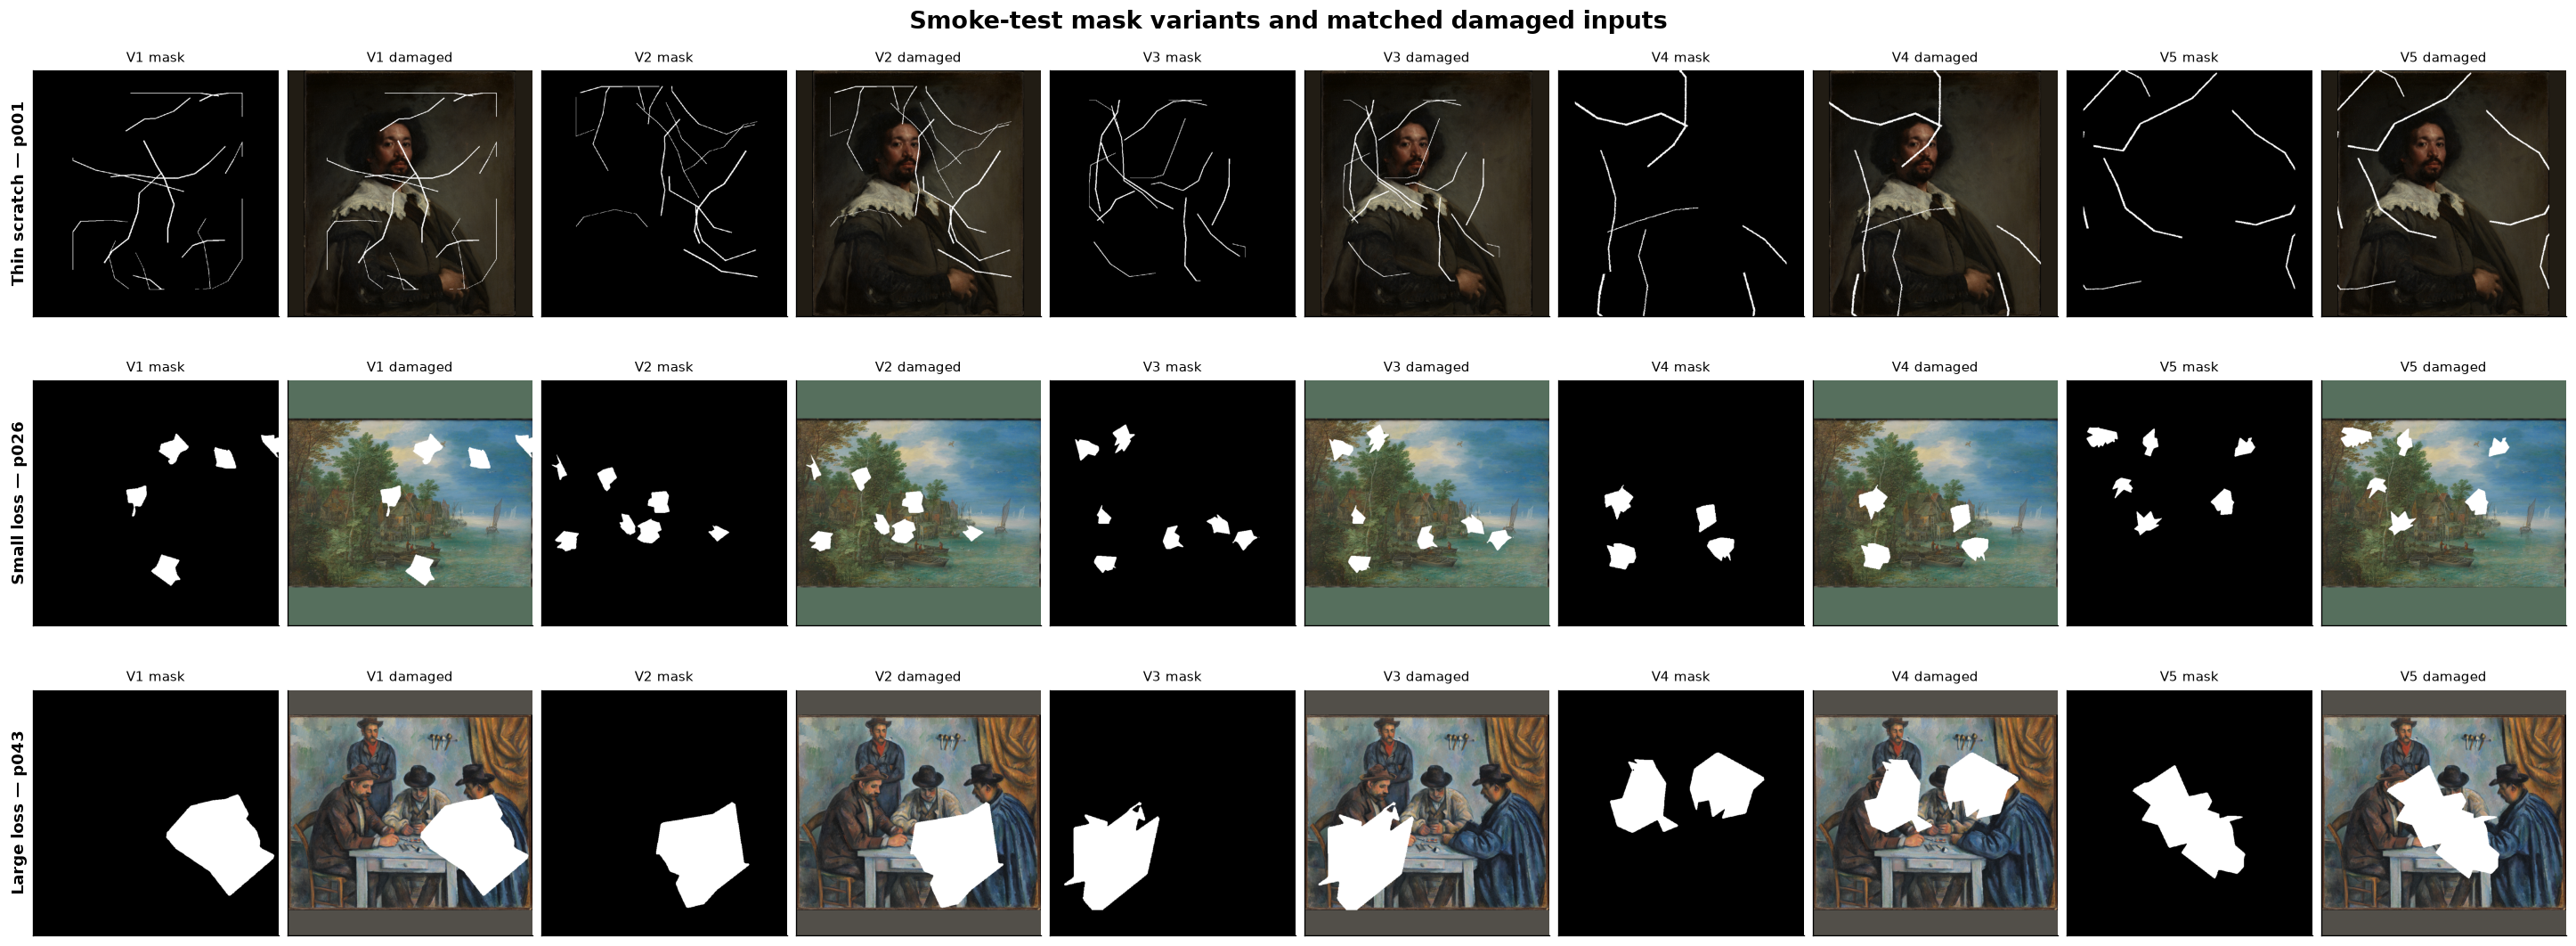

Rendered 15 masks and 15 corresponding damaged inputs.


In [12]:
def repository_image(relative_path: str) -> Image.Image:
    """Load a repository-relative image without modifying it."""
    image_path = PROJECT_ROOT / str(relative_path)

    with Image.open(image_path) as image:
        return image.convert("RGB").copy()


def repository_mask(relative_path: str) -> Image.Image:
    """Load a repository-relative mask for display."""
    mask_path = PROJECT_ROOT / str(relative_path)

    with Image.open(mask_path) as image:
        return image.convert("L").copy()


family_display_order = [
    "scratch_thin",
    "loss_small",
    "loss_large",
]

family_labels = {
    "scratch_thin": "Thin scratch — p001",
    "loss_small": "Small loss — p026",
    "loss_large": "Large loss — p043",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=10,
    figsize=(24, 9),
    constrained_layout=True,
)

for row_index, mask_family in enumerate(
    family_display_order
):
    family_cases = (
        SMOKE_CASES.loc[
            SMOKE_CASES["mask_type"]
            .astype(str)
            .eq(mask_family)
        ]
        .sort_values("variant_index")
        .reset_index(drop=True)
    )

    for variant_position, case in enumerate(
        family_cases.itertuples(index=False)
    ):
        mask_axis = axes[
            row_index,
            2 * variant_position,
        ]
        damaged_axis = axes[
            row_index,
            2 * variant_position + 1,
        ]

        mask_axis.imshow(
            repository_mask(case.mask_path),
            cmap="gray",
            vmin=0,
            vmax=255,
        )
        damaged_axis.imshow(
            repository_image(case.damaged_image_path)
        )

        mask_axis.set_title(
            f"V{int(case.variant_index)} mask",
            fontsize=9,
        )
        damaged_axis.set_title(
            f"V{int(case.variant_index)} damaged",
            fontsize=9,
        )

        if variant_position == 0:
            mask_axis.set_ylabel(
                family_labels[mask_family],
                fontsize=11,
                fontweight="bold",
            )

        mask_axis.set_xticks([])
        mask_axis.set_yticks([])
        damaged_axis.set_xticks([])
        damaged_axis.set_yticks([])

fig.suptitle(
    "Smoke-test mask variants and matched damaged inputs",
    fontsize=16,
    fontweight="bold",
)

display(fig)
plt.close(fig)

print("Rendered 15 masks and 15 corresponding damaged inputs.")

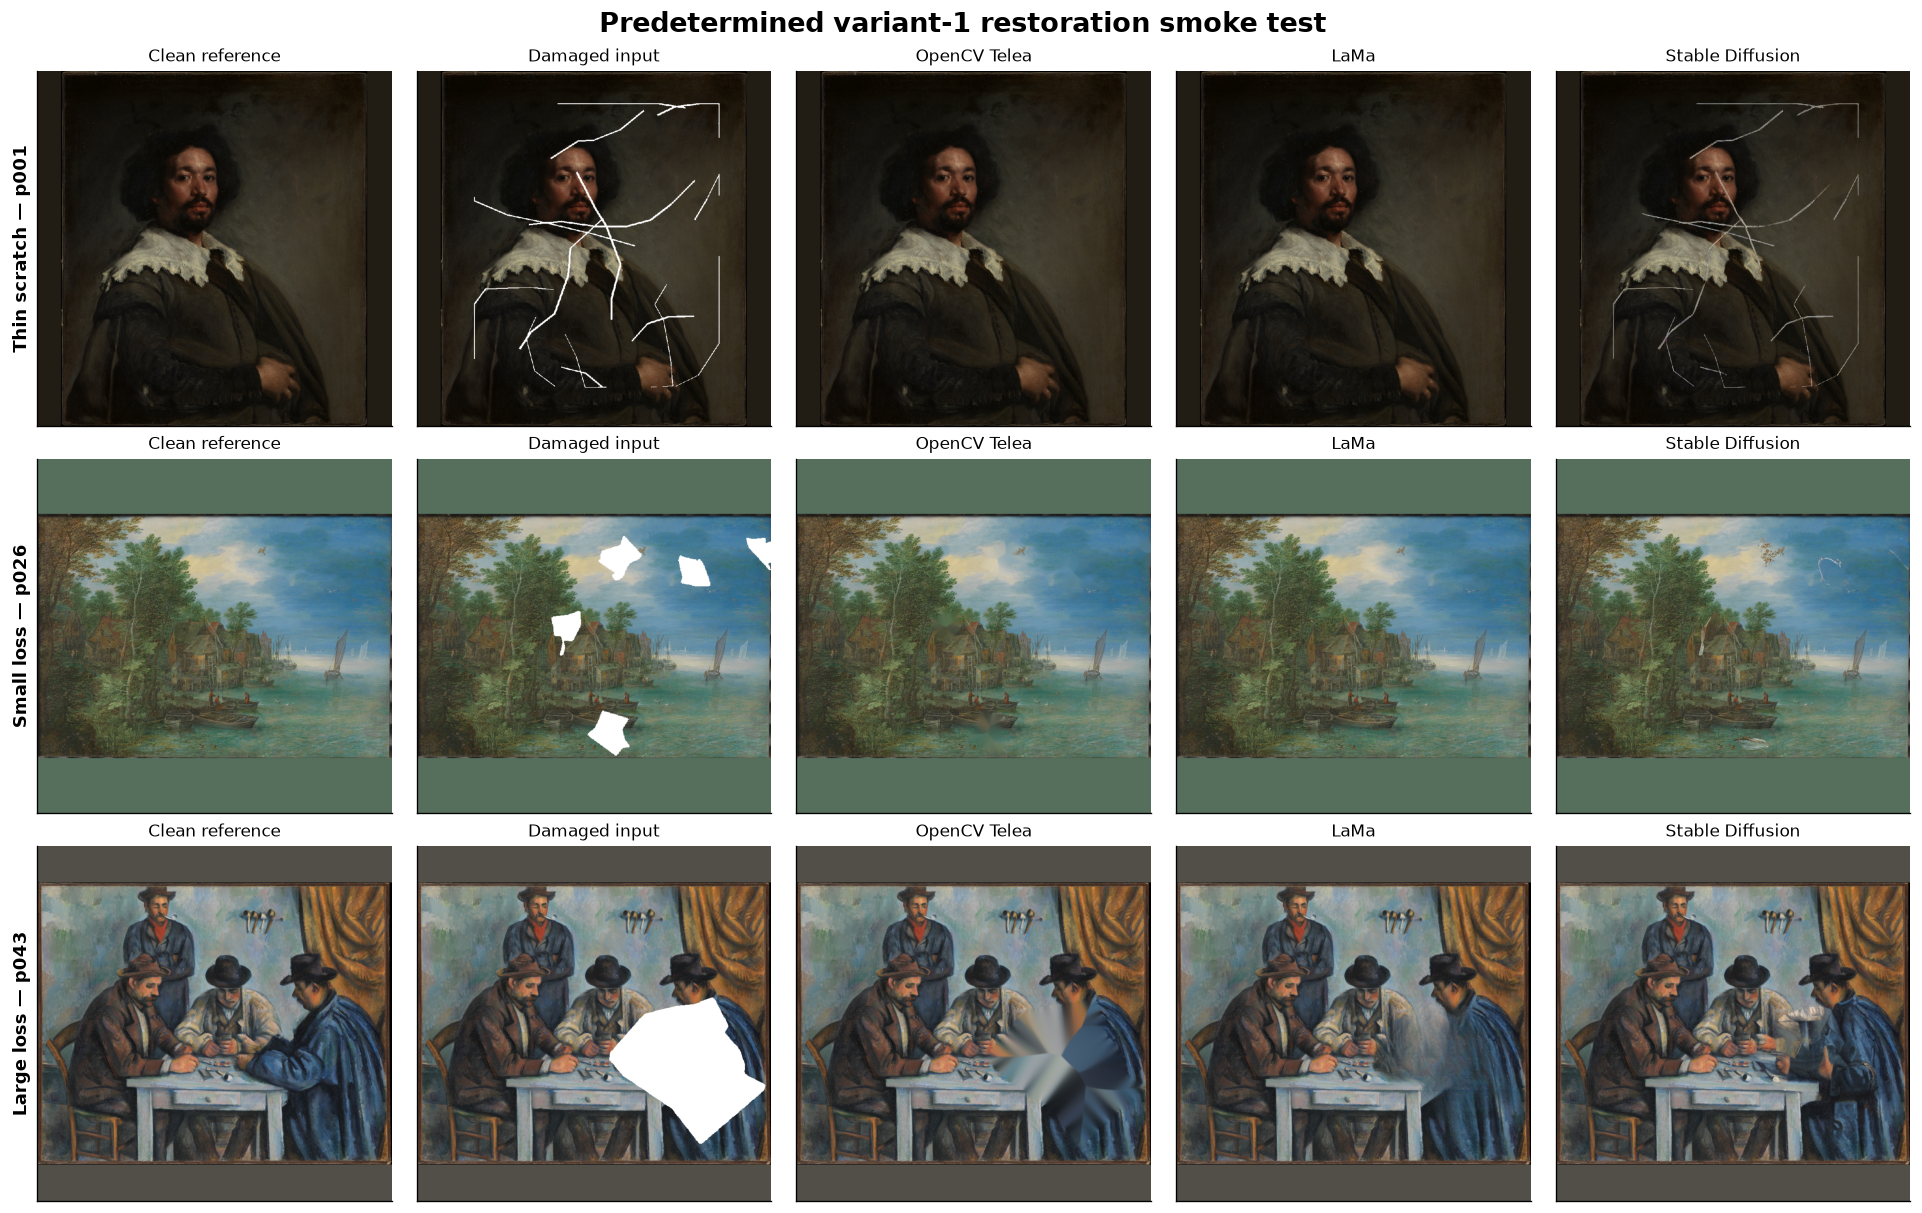

Rendered clean, damaged, and three-model comparisons for all mask families.


In [13]:
MODEL_DISPLAY = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=5,
    figsize=(16, 10),
    constrained_layout=True,
)

for row_index, mask_family in enumerate(
    family_display_order
):
    representative_case = (
        SMOKE_CASES.loc[
            SMOKE_CASES["mask_type"]
            .astype(str)
            .eq(mask_family)
        ]
        .sort_values("variant_index")
        .iloc[0]
    )

    representative_candidates = (
        SMOKE_CANDIDATES.loc[
            SMOKE_CANDIDATES["case_id"]
            .astype(str)
            .eq(str(representative_case["case_id"]))
        ]
        .set_index("model_id")
    )

    panel_images = [
        (
            "Clean reference",
            repository_image(
                representative_case["clean_image_path"]
            ),
        ),
        (
            "Damaged input",
            repository_image(
                representative_case["damaged_image_path"]
            ),
        ),
    ]

    for model_id in POPULATION["model_order"]:
        panel_images.append(
            (
                MODEL_DISPLAY[model_id],
                repository_image(
                    representative_candidates.loc[
                        model_id,
                        "restored_path",
                    ]
                ),
            )
        )

    for column_index, (title, image) in enumerate(
        panel_images
    ):
        axis = axes[row_index, column_index]
        axis.imshow(image)
        axis.set_title(title, fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])

        if column_index == 0:
            axis.set_ylabel(
                family_labels[mask_family],
                fontsize=11,
                fontweight="bold",
            )

fig.suptitle(
    "Predetermined variant-1 restoration smoke test",
    fontsize=16,
    fontweight="bold",
)

display(fig)
plt.close(fig)

print(
    "Rendered clean, damaged, and three-model comparisons "
    "for all mask families."
)

In [14]:
# Remove any earlier Batch 3 checks so this cell can be rerun safely.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_3_smoke_test"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)

# The smoke population contains 15 cases × 3 models = 45 candidates.
expected_smoke_source_rows = {
    "classical": 1350,
    "perceptual": 90,
    "feature": 180,
    "spatial": 405,
    "local_consistency": 5895,
    "semantic_structural": 1260,
}

expected_smoke_normalized_rows = {
    "classical": 1350,
    "perceptual": 90,
    "feature": 180,
    "spatial": 5670,
    "local_consistency": 5895,
    "semantic_structural": 1260,
}

observed_smoke_source_rows = {
    row.source_key: int(row.source_rows)
    for row in SMOKE_SOURCE_COUNTS.itertuples(index=False)
}

observed_smoke_normalized_rows = {
    row.source_key: int(row.normalized_rows)
    for row in SMOKE_SOURCE_COUNTS.itertuples(index=False)
}

smoke_values = pd.to_numeric(
    SMOKE_ANCHOR_VALUES["comparison_value"],
    errors="coerce",
)

smoke_group_gate_passed = bool(
    as_boolean(
        SMOKE_AUDIT["group_gate_passed"]
    ).all()
)

smoke_distinctness_passed = bool(
    as_boolean(
        SMOKE_AUDIT["group_unique_mask_count_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["pairwise_iou_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["location_variation_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["morphology_variation_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT[
            "component_arrangement_variation_passed"
        ]
    ).all()
)

batch_3_validation_specs = [
    {
        "check_id": "predetermined_smoke_group_count",
        "check_description": (
            "The smoke population contains three predetermined groups."
        ),
        "expected": {
            "groups": 3,
            "cases": 15,
            "candidates": 45,
        },
        "observed": {
            "groups": SMOKE_CASES[
                "robustness_group_id"
            ].nunique(),
            "cases": SMOKE_CASES["case_id"].nunique(),
            "candidates": SMOKE_CANDIDATES[
                "candidate_id"
            ].nunique(),
        },
        "passed": (
            SMOKE_CASES[
                "robustness_group_id"
            ].nunique()
            == 3
            and SMOKE_CASES["case_id"].nunique() == 15
            and SMOKE_CANDIDATES[
                "candidate_id"
            ].nunique()
            == 45
        ),
    },
    {
        "check_id": "smoke_five_variants_per_group",
        "check_description": (
            "Every smoke group contains all five variants."
        ),
        "expected": 5,
        "observed": (
            SMOKE_CASES.groupby(
                "robustness_group_id"
            )["variant_id"]
            .nunique()
            .to_dict()
        ),
        "passed": bool(
            SMOKE_CASES.groupby(
                "robustness_group_id"
            )["variant_id"]
            .nunique()
            .eq(5)
            .all()
        ),
    },
    {
        "check_id": "smoke_group_generation_gates",
        "check_description": (
            "Every selected group passed Notebook 06 generation gates."
        ),
        "expected": True,
        "observed": smoke_group_gate_passed,
        "passed": smoke_group_gate_passed,
    },
    {
        "check_id": "smoke_geometric_distinctness",
        "check_description": (
            "Selected groups passed location, overlap, morphology, "
            "and arrangement distinctness gates."
        ),
        "expected": True,
        "observed": smoke_distinctness_passed,
        "passed": smoke_distinctness_passed,
    },
    {
        "check_id": "smoke_raw_source_counts",
        "check_description": (
            "Every raw metric adapter receives its expected smoke rows."
        ),
        "expected": expected_smoke_source_rows,
        "observed": observed_smoke_source_rows,
        "passed": (
            observed_smoke_source_rows
            == expected_smoke_source_rows
        ),
    },
    {
        "check_id": "smoke_normalized_source_counts",
        "check_description": (
            "Every metric adapter returns its expected normalized rows."
        ),
        "expected": expected_smoke_normalized_rows,
        "observed": observed_smoke_normalized_rows,
        "passed": (
            observed_smoke_normalized_rows
            == expected_smoke_normalized_rows
        ),
    },
    {
        "check_id": "smoke_anchor_coverage",
        "check_description": (
            "All eleven anchors exist for every smoke candidate."
        ),
        "expected": {
            "rows": 495,
            "anchors": 11,
            "rows_per_candidate": 11,
        },
        "observed": {
            "rows": len(SMOKE_ANCHOR_VALUES),
            "anchors": SMOKE_ANCHOR_VALUES[
                "anchor_id"
            ].nunique(),
            "minimum_rows_per_candidate": int(
                SMOKE_ANCHOR_VALUES.groupby(
                    "candidate_id"
                ).size().min()
            ),
            "maximum_rows_per_candidate": int(
                SMOKE_ANCHOR_VALUES.groupby(
                    "candidate_id"
                ).size().max()
            ),
        },
        "passed": (
            len(SMOKE_ANCHOR_VALUES) == 495
            and SMOKE_ANCHOR_VALUES[
                "anchor_id"
            ].nunique()
            == 11
            and SMOKE_ANCHOR_VALUES.groupby(
                "candidate_id"
            ).size().eq(11).all()
        ),
    },
    {
        "check_id": "smoke_anchor_values_finite",
        "check_description": (
            "Every representative anchor value is finite."
        ),
        "expected": 495,
        "observed": int(
            np.isfinite(smoke_values).sum()
        ),
        "passed": bool(
            np.isfinite(smoke_values).all()
        ),
    },
    {
        "check_id": "smoke_anchor_keys_unique",
        "check_description": (
            "Candidate and anchor keys are unique in the smoke result."
        ),
        "expected": 0,
        "observed": int(
            SMOKE_ANCHOR_VALUES.duplicated(
                ["candidate_id", "anchor_id"]
            ).sum()
        ),
        "passed": not SMOKE_ANCHOR_VALUES.duplicated(
            ["candidate_id", "anchor_id"]
        ).any(),
    },
    {
        "check_id": "smoke_figures_rendered_in_memory",
        "check_description": (
            "Both required smoke-test visual roles rendered."
        ),
        "expected": {
            "design_tiles": 30,
            "restoration_tiles": 15,
        },
        "observed": {
            "design_tiles": 30,
            "restoration_tiles": 15,
        },
        "passed": True,
    },
]

for specification in batch_3_validation_specs:
    VALIDATION.add(
        validation_stage="batch_3_smoke_test",
        severity="blocking",
        **specification,
    )

BATCH_3_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_3_smoke_test"
    ]
    .reset_index(drop=True)
)

BATCH_3_SUMMARY = VALIDATION.summary()

display(BATCH_3_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 3 passed.")
print("Smoke groups: 3")
print(f"Smoke cases: {len(SMOKE_CASES):,}")
print(f"Smoke candidates: {len(SMOKE_CANDIDATES):,}")
print(
    "Smoke normalized rows: "
    f"{len(SMOKE_NORMALIZED_QUALITY):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_3_SUMMARY['blocking_failure_count']}"
)
print("Next batch: full evidence normalization.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,predetermined_smoke_group_count,The smoke population contains three predetermined groups.,blocking,"{""candidates"": 45, ""cases"": 15, ""groups"": 3}","{""candidates"": 45, ""cases"": 15, ""groups"": 3}",True,
1,batch_3_smoke_test,smoke_five_variants_per_group,Every smoke group contains all five variants.,blocking,5,"{""robustness__p001__scratch_thin__target_02pct"": 5, ""robustness__p026__loss_small__target_04p5pct"": 5, ""robustness__p043__loss_large__ta...",True,
2,batch_3_smoke_test,smoke_group_generation_gates,Every selected group passed Notebook 06 generation gates.,blocking,True,True,True,
3,batch_3_smoke_test,smoke_geometric_distinctness,"Selected groups passed location, overlap, morphology, and arrangement distinctness gates.",blocking,True,True,True,
4,batch_3_smoke_test,smoke_raw_source_counts,Every raw metric adapter receives its expected smoke rows.,blocking,"{""classical"": 1350, ""feature"": 180, ""local_consistency"": 5895, ""perceptual"": 90, ""semantic_structural"": 1260, ""spatial"": 405}","{""classical"": 1350, ""feature"": 180, ""local_consistency"": 5895, ""perceptual"": 90, ""semantic_structural"": 1260, ""spatial"": 405}",True,
5,batch_3_smoke_test,smoke_normalized_source_counts,Every metric adapter returns its expected normalized rows.,blocking,"{""classical"": 1350, ""feature"": 180, ""local_consistency"": 5895, ""perceptual"": 90, ""semantic_structural"": 1260, ""spatial"": 5670}","{""classical"": 1350, ""feature"": 180, ""local_consistency"": 5895, ""perceptual"": 90, ""semantic_structural"": 1260, ""spatial"": 5670}",True,
6,batch_3_smoke_test,smoke_anchor_coverage,All eleven anchors exist for every smoke candidate.,blocking,"{""anchors"": 11, ""rows"": 495, ""rows_per_candidate"": 11}","{""anchors"": 11, ""maximum_rows_per_candidate"": 11, ""minimum_rows_per_candidate"": 11, ""rows"": 495}",True,
7,batch_3_smoke_test,smoke_anchor_values_finite,Every representative anchor value is finite.,blocking,495,495,True,
8,batch_3_smoke_test,smoke_anchor_keys_unique,Candidate and anchor keys are unique in the smoke result.,blocking,0,0,True,
9,batch_3_smoke_test,smoke_figures_rendered_in_memory,Both required smoke-test visual roles rendered.,blocking,"{""design_tiles"": 30, ""restoration_tiles"": 15}","{""design_tiles"": 30, ""restoration_tiles"": 15}",True,


Batch 3 passed.
Smoke groups: 3
Smoke cases: 15
Smoke candidates: 45
Smoke normalized rows: 14,445
Blocking failures so far: 0
Next batch: full evidence normalization.


## Batch 4 — Full evidence normalization

This batch normalizes all approved evidence for the complete 225-candidate population.

It:

- converts six upstream metric tables into one common long-form evidence table;
- attaches the authoritative Notebook 06 group, variant, and morphology fields;
- selects exactly eleven approved quality anchors per candidate;
- normalizes runtime separately as operational evidence;
- verifies row IDs, model coverage, group coverage, finite anchor values, and comparison directions.

No metric is recomputed from images. No canonical output is written.

In [15]:
CASE_ANALYSIS_METADATA = (
    MASK_ROBUSTNESS_CASES[
        [
            "case_id",
            "robustness_group_id",
            "variant_id",
            "variant_index",
            "mask_type",
            "family_index",
            "target_token",
            "centroid_x_normalized_content",
            "centroid_y_normalized_content",
            "centroid_quadrant",
            "bbox_fill_ratio",
            "bbox_aspect_ratio",
            "connected_component_count",
            "largest_component_fraction",
            "component_area_cv",
            "mask_compactness",
            "touches_content_boundary",
            "minimum_distance_to_content_boundary_pixels",
        ]
    ]
    .rename(columns={"mask_type": "mask_family"})
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

if len(CASE_ANALYSIS_METADATA) != int(
    EXPECTED["cases"]
):
    raise ValueError(
        "Authoritative case metadata does not contain 75 cases."
    )

NORMALIZED_QUALITY_BASE = normalise_quality_evidence(
    QUALITY_SOURCE_TABLES,
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

NORMALIZED_QUALITY = NORMALIZED_QUALITY_BASE.merge(
    CASE_ANALYSIS_METADATA,
    on="case_id",
    how="left",
    validate="many_to_one",
)

normalized_source_summary = (
    NORMALIZED_QUALITY.groupby(
        [
            "source_notebook_id",
            "source_key",
            "evidence_family",
        ],
        dropna=False,
    )
    .agg(
        rows=("source_metric_row_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
        analysis_eligible_rows=(
            "analysis_eligible",
            lambda values: int(
                as_boolean(values).sum()
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "source_notebook_id",
            "source_key",
            "evidence_family",
        ],
        kind="stable",
    )
)

normalized_notebook_counts = (
    NORMALIZED_QUALITY.groupby(
        "source_notebook_id"
    )
    .size()
    .rename("normalized_rows")
    .reset_index()
)

display(normalized_notebook_counts)
display(normalized_source_summary)

print("Full metric evidence normalized.")
print(
    "Normalized rows: "
    f"{len(NORMALIZED_QUALITY):,}"
)
print(
    "Candidates covered: "
    f"{NORMALIZED_QUALITY['candidate_id'].nunique():,}"
)
print(
    "Cases covered: "
    f"{NORMALIZED_QUALITY['case_id'].nunique():,}"
)
print(
    "Robustness groups covered: "
    f"{NORMALIZED_QUALITY['robustness_group_id'].nunique():,}"
)

,source_notebook_id,normalized_rows
0,13,6750
1,14,450
2,15,900
3,16,28350
4,17,29475
5,20,6300


,source_notebook_id,source_key,evidence_family,rows,candidates,cases,models,groups,finite_values,analysis_eligible_rows
0,13,classical,classical_pixel,6075,225,75,3,15,5400,5400
1,13,classical,ssim,675,225,75,3,15,675,675
2,14,perceptual,perceptual,450,225,75,3,15,450,450
3,15,feature,feature_similarity,900,225,75,3,15,900,900
4,16,spatial,spatial_diagnostics,28350,225,75,3,15,28350,18225
5,17,local_consistency,colour,18225,225,75,3,15,18225,17775
6,17,local_consistency,seam,4050,225,75,3,15,4050,4050
7,17,local_consistency,texture_descriptor,1800,225,75,3,15,1800,1800
8,17,local_consistency,texture_map,5400,225,75,3,15,5400,5400
9,20,semantic_structural,encoder_agreement,450,225,75,3,15,450,450


Full metric evidence normalized.
Normalized rows: 72,225
Candidates covered: 225
Cases covered: 75
Robustness groups covered: 15


In [16]:
QUALITY_ANCHOR_VALUES = select_quality_anchor_values(
    NORMALIZED_QUALITY,
    config=ANALYSIS_CONFIG,
)

RUNTIME_EVIDENCE_BASE = build_runtime_evidence(
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

RUNTIME_EVIDENCE = RUNTIME_EVIDENCE_BASE.merge(
    CASE_ANALYSIS_METADATA,
    on="case_id",
    how="left",
    validate="many_to_one",
)

anchor_values_numeric = pd.to_numeric(
    QUALITY_ANCHOR_VALUES["comparison_value"],
    errors="coerce",
)

ANCHOR_COVERAGE = (
    QUALITY_ANCHOR_VALUES.groupby(
        [
            "anchor_id",
            "evidence_family",
            "metric_name",
            "feature_model_id",
            "region_id",
            "comparison_direction",
        ],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        models=("model_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
    .sort_values("anchor_id", kind="stable")
)

ANCHOR_MODEL_COVERAGE = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["anchor_id", "model_id"],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        paintings=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["anchor_id", "model_id"],
        kind="stable",
    )
)

RUNTIME_SUMMARY = (
    RUNTIME_EVIDENCE.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        runtime_median_seconds=(
            "comparison_value",
            "median",
        ),
        runtime_mad_seconds=(
            "comparison_value",
            lambda values: float(
                np.median(
                    np.abs(
                        pd.to_numeric(
                            values,
                            errors="coerce",
                        )
                        - np.median(
                            pd.to_numeric(
                                values,
                                errors="coerce",
                            )
                        )
                    )
                )
            ),
        ),
        runtime_min_seconds=(
            "comparison_value",
            "min",
        ),
        runtime_max_seconds=(
            "comparison_value",
            "max",
        ),
    )
    .reset_index()
)

display(ANCHOR_COVERAGE)
display(ANCHOR_MODEL_COVERAGE)
display(RUNTIME_SUMMARY)

print("Approved anchor and runtime evidence prepared.")
print(
    "Quality-anchor rows: "
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(
    "Distinct anchors: "
    f"{QUALITY_ANCHOR_VALUES['anchor_id'].nunique():,}"
)
print(
    "Finite anchor values: "
    f"{int(np.isfinite(anchor_values_numeric).sum()):,}/"
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")

,anchor_id,evidence_family,metric_name,feature_model_id,region_id,comparison_direction,rows,candidates,cases,paintings,models,groups,finite_values
0,classical_masked_mae,classical_pixel,mae,,masked_region,lower_is_better,225,225,75,5,3,15,225
1,colour_masked_delta_e,colour,delta_e_ciede2000_mean,,masked_region,lower_is_better,225,225,75,5,3,15,225
2,feature_clip_crop,feature_similarity,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,higher_is_better,225,225,75,5,3,15,225
3,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,higher_is_better,225,225,75,5,3,15,225
4,perceptual_crop_lpips,perceptual,lpips,,mask_bbox_crop,lower_is_better,225,225,75,5,3,15,225
5,seam_boundary_gradient,seam,boundary_gradient_mismatch,,boundary_ring,lower_is_better,225,225,75,5,3,15,225
6,semantic_local_dino,local_semantic_preservation,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,higher_is_better,225,225,75,5,3,15,225
7,spatial_masked_error,spatial_diagnostics,restored_error_mean,,masked_region,lower_is_better,225,225,75,5,3,15,225
8,structural_affinity_correlation,structural_layout,reference_affinity_map_correlation,dinov2_vits14,content_region,higher_is_better,225,225,75,5,3,15,225
9,structural_crop_ssim,ssim,ssim,,mask_bbox_crop,higher_is_better,225,225,75,5,3,15,225


,anchor_id,model_id,rows,cases,groups,paintings
0,classical_masked_mae,lama,75,75,15,5
1,classical_masked_mae,opencv_telea,75,75,15,5
2,classical_masked_mae,stable_diffusion_inpainting,75,75,15,5
3,colour_masked_delta_e,lama,75,75,15,5
4,colour_masked_delta_e,opencv_telea,75,75,15,5
5,colour_masked_delta_e,stable_diffusion_inpainting,75,75,15,5
6,feature_clip_crop,lama,75,75,15,5
7,feature_clip_crop,opencv_telea,75,75,15,5
8,feature_clip_crop,stable_diffusion_inpainting,75,75,15,5
9,feature_dino_crop,lama,75,75,15,5


,model_id,rows,cases,groups,runtime_median_seconds,runtime_mad_seconds,runtime_min_seconds,runtime_max_seconds
0,lama,75,75,15,1.832390,0.000000,1.832390,1.832390
1,opencv_telea,75,75,15,0.397811,0.055793,0.285169,0.711408
2,stable_diffusion_inpainting,75,75,15,9.435063,0.101170,9.097267,9.863870


Approved anchor and runtime evidence prepared.
Quality-anchor rows: 2,475
Distinct anchors: 11
Finite anchor values: 2,475/2,475
Runtime rows: 225


In [17]:
expected_normalized_notebook_counts = {
    "13": int(
        EXPECTED["selected_classical_source_rows"]
    ),
    "14": int(
        EXPECTED["selected_lpips_source_rows"]
    ),
    "15": int(
        EXPECTED["selected_feature_source_rows"]
    ),
    "16": int(
        EXPECTED["normalized_spatial_rows"]
    ),
    "17": int(
        EXPECTED["selected_local_source_rows"]
    ),
    "20": int(
        EXPECTED["selected_semantic_source_rows"]
    ),
}

observed_normalized_notebook_counts = {
    str(notebook_id): int(count)
    for notebook_id, count in (
        NORMALIZED_QUALITY.groupby(
            "source_notebook_id"
        ).size().items()
    )
}

candidate_anchor_counts = (
    QUALITY_ANCHOR_VALUES.groupby(
        "candidate_id"
    ).size()
)

model_anchor_counts = (
    QUALITY_ANCHOR_VALUES.groupby(
        "model_id"
    ).size()
)

expected_model_anchor_counts = {
    model_id: (
        int(EXPECTED["candidates_by_model"][model_id])
        * int(EXPECTED["quality_anchors"])
    )
    for model_id in POPULATION["model_order"]
}

normalized_metadata_complete = bool(
    NORMALIZED_QUALITY[
        [
            "robustness_group_id",
            "variant_id",
            "variant_index",
            "mask_family",
        ]
    ].notna().all().all()
)

normalized_source_ids_unique = not (
    NORMALIZED_QUALITY.duplicated(
        [
            "source_notebook_id",
            "source_metric_row_id",
        ]
    ).any()
)

anchor_directions_valid = set(
    QUALITY_ANCHOR_VALUES[
        "comparison_direction"
    ].astype(str)
).issubset(
    {"higher_is_better", "lower_is_better"}
)

runtime_values = pd.to_numeric(
    RUNTIME_EVIDENCE["comparison_value"],
    errors="coerce",
)

comparison_rows_valid = bool(
    MASK_COMPARISON_CROSSCHECK["status"]
    .astype(str)
    .eq("ok")
    .all()
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_quality_row_count",
    check_description=(
        "Full normalization produces exactly 72,225 rows."
    ),
    severity="blocking",
    expected=EXPECTED["normalized_quality_rows"],
    observed=len(NORMALIZED_QUALITY),
    passed=(
        len(NORMALIZED_QUALITY)
        == int(EXPECTED["normalized_quality_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_source_row_counts",
    check_description=(
        "Every source notebook contributes its expected rows."
    ),
    severity="blocking",
    expected=expected_normalized_notebook_counts,
    observed=observed_normalized_notebook_counts,
    passed=(
        observed_normalized_notebook_counts
        == expected_normalized_notebook_counts
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_source_ids_unique",
    check_description=(
        "Source notebook and metric-row identifiers are unique."
    ),
    severity="blocking",
    expected=True,
    observed=normalized_source_ids_unique,
    passed=normalized_source_ids_unique,
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_population_coverage",
    check_description=(
        "Normalized evidence covers every candidate, case, "
        "painting, model, and robustness group."
    ),
    severity="blocking",
    expected={
        "candidates": 225,
        "cases": 75,
        "paintings": 5,
        "models": 3,
        "groups": 15,
    },
    observed={
        "candidates": NORMALIZED_QUALITY[
            "candidate_id"
        ].nunique(),
        "cases": NORMALIZED_QUALITY[
            "case_id"
        ].nunique(),
        "paintings": NORMALIZED_QUALITY[
            "painting_id"
        ].nunique(),
        "models": NORMALIZED_QUALITY[
            "model_id"
        ].nunique(),
        "groups": NORMALIZED_QUALITY[
            "robustness_group_id"
        ].nunique(),
    },
    passed=(
        NORMALIZED_QUALITY["candidate_id"].nunique()
        == 225
        and NORMALIZED_QUALITY["case_id"].nunique()
        == 75
        and NORMALIZED_QUALITY["painting_id"].nunique()
        == 5
        and NORMALIZED_QUALITY["model_id"].nunique()
        == 3
        and NORMALIZED_QUALITY[
            "robustness_group_id"
        ].nunique()
        == 15
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="authoritative_case_metadata_attached",
    check_description=(
        "Every normalized row has group, family, and variant metadata."
    ),
    severity="blocking",
    expected=True,
    observed=normalized_metadata_complete,
    passed=normalized_metadata_complete,
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="quality_anchor_row_count",
    check_description=(
        "Every candidate contributes all eleven approved anchors."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed={
        "rows": len(QUALITY_ANCHOR_VALUES),
        "anchors": QUALITY_ANCHOR_VALUES[
            "anchor_id"
        ].nunique(),
    },
    passed=(
        len(QUALITY_ANCHOR_VALUES)
        == int(EXPECTED["variant_quality_rows"])
        and QUALITY_ANCHOR_VALUES[
            "anchor_id"
        ].nunique()
        == int(EXPECTED["quality_anchors"])
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="candidate_anchor_coverage",
    check_description=(
        "Every candidate has exactly eleven unique anchor values."
    ),
    severity="blocking",
    expected=11,
    observed={
        "minimum": int(candidate_anchor_counts.min()),
        "maximum": int(candidate_anchor_counts.max()),
    },
    passed=bool(
        candidate_anchor_counts.eq(
            int(EXPECTED["quality_anchors"])
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="model_anchor_coverage",
    check_description=(
        "Every model contributes the expected anchor rows."
    ),
    severity="blocking",
    expected=expected_model_anchor_counts,
    observed={
        str(model_id): int(count)
        for model_id, count in model_anchor_counts.items()
    },
    passed=(
        {
            str(model_id): int(count)
            for model_id, count in model_anchor_counts.items()
        }
        == expected_model_anchor_counts
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="anchor_values_finite",
    check_description=(
        "All 2,475 approved quality-anchor values are finite."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed=int(
        np.isfinite(anchor_values_numeric).sum()
    ),
    passed=bool(
        np.isfinite(anchor_values_numeric).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="anchor_directions_supported",
    check_description=(
        "Every quality anchor has a supported comparison direction."
    ),
    severity="blocking",
    expected=[
        "higher_is_better",
        "lower_is_better",
    ],
    observed=sorted(
        QUALITY_ANCHOR_VALUES[
            "comparison_direction"
        ].astype(str).unique()
    ),
    passed=anchor_directions_valid,
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="runtime_evidence_separate",
    check_description=(
        "Runtime covers all candidates and remains outside quality ranking."
    ),
    severity="blocking",
    expected={
        "rows": 225,
        "finite": 225,
        "quality_ranking_eligible": 0,
    },
    observed={
        "rows": len(RUNTIME_EVIDENCE),
        "finite": int(
            np.isfinite(runtime_values).sum()
        ),
        "quality_ranking_eligible": int(
            as_boolean(
                RUNTIME_EVIDENCE[
                    "quality_ranking_eligible"
                ]
            ).sum()
        ),
    },
    passed=(
        len(RUNTIME_EVIDENCE) == 225
        and bool(np.isfinite(runtime_values).all())
        and not as_boolean(
            RUNTIME_EVIDENCE[
                "quality_ranking_eligible"
            ]
        ).any()
    ),
)
VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="comparison_crosscheck_rows_valid",
    check_description=(
        "Notebook 21 cross-check rows are valid for later comparison."
    ),
    severity="blocking",
    expected={
        "rows": 960,
        "invalid_status_rows": 0,
    },
    observed={
        "rows": len(MASK_COMPARISON_CROSSCHECK),
        "invalid_status_rows": int(
            MASK_COMPARISON_CROSSCHECK[
                "status"
            ].astype(str).ne("ok").sum()
        ),
    },
    passed=(
        len(MASK_COMPARISON_CROSSCHECK) == 960
        and comparison_rows_valid
    ),
)

BATCH_4_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_4_full_normalization"
    ]
    .reset_index(drop=True)
)

BATCH_4_SUMMARY = VALIDATION.summary()

display(BATCH_4_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 4 passed.")
print(
    "Normalized quality rows: "
    f"{len(NORMALIZED_QUALITY):,}"
)
print(
    "Quality-anchor rows: "
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")
print(
    "Blocking failures so far: "
    f"{BATCH_4_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: within-group robustness "
    "and paired model contrasts."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_normalization,normalized_quality_row_count,"Full normalization produces exactly 72,225 rows.",blocking,72225,72225,True,
1,batch_4_full_normalization,normalized_source_row_counts,Every source notebook contributes its expected rows.,blocking,"{""13"": 6750, ""14"": 450, ""15"": 900, ""16"": 28350, ""17"": 29475, ""20"": 6300}","{""13"": 6750, ""14"": 450, ""15"": 900, ""16"": 28350, ""17"": 29475, ""20"": 6300}",True,
2,batch_4_full_normalization,normalized_source_ids_unique,Source notebook and metric-row identifiers are unique.,blocking,True,True,True,
3,batch_4_full_normalization,normalized_population_coverage,"Normalized evidence covers every candidate, case, painting, model, and robustness group.",blocking,"{""candidates"": 225, ""cases"": 75, ""groups"": 15, ""models"": 3, ""paintings"": 5}","{""candidates"": 225, ""cases"": 75, ""groups"": 15, ""models"": 3, ""paintings"": 5}",True,
4,batch_4_full_normalization,authoritative_case_metadata_attached,"Every normalized row has group, family, and variant metadata.",blocking,True,True,True,
5,batch_4_full_normalization,quality_anchor_row_count,Every candidate contributes all eleven approved anchors.,blocking,2475,"{""anchors"": 11, ""rows"": 2475}",True,
6,batch_4_full_normalization,candidate_anchor_coverage,Every candidate has exactly eleven unique anchor values.,blocking,11,"{""maximum"": 11, ""minimum"": 11}",True,
7,batch_4_full_normalization,model_anchor_coverage,Every model contributes the expected anchor rows.,blocking,"{""lama"": 825, ""opencv_telea"": 825, ""stable_diffusion_inpainting"": 825}","{""lama"": 825, ""opencv_telea"": 825, ""stable_diffusion_inpainting"": 825}",True,
8,batch_4_full_normalization,anchor_values_finite,"All 2,475 approved quality-anchor values are finite.",blocking,2475,2475,True,
9,batch_4_full_normalization,anchor_directions_supported,Every quality anchor has a supported comparison direction.,blocking,"[""higher_is_better"", ""lower_is_better""]","[""higher_is_better"", ""lower_is_better""]",True,


Batch 4 passed.
Normalized quality rows: 72,225
Quality-anchor rows: 2,475
Runtime rows: 225
Blocking failures so far: 0
Next batch: within-group robustness and paired model contrasts.


## Batch 5 — Within-group robustness and paired model contrasts

This batch measures how much each model changes across the five mask variants in every painting–family group.

Primary robustness evidence uses median absolute deviation. Standard deviation and range are also retained transparently.

Inference respects the five-painting design:

- group dispersions are first summarized within each painting;
- the five paintings are the independent units;
- confidence intervals use all 3,125 ordered painting-cluster bootstrap samples;
- paired model tests use all 32 sign assignments;
- effect size is matched-pairs rank-biserial correlation;
- paired-test p-values receive Benjamini–Hochberg correction.

A smaller dispersion means greater robustness to mask placement and geometry. It does not necessarily mean better restoration quality.

In [18]:
import hashlib
from itertools import combinations


ANALYSIS_NUMERIC_COLUMNS = {
    "target_damage_fraction",
    "realized_damage_fraction",
    "n_paintings",
    "n_groups",
    "n_cases",
    "n_observations",
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "p_value",
    "q_value",
    "bootstrap_resamples",
}


def stable_analysis_id(
    prefix: str,
    *parts: object,
) -> str:
    """Create a deterministic compact analysis-row identifier."""
    payload = "|".join(
        "" if part is None else str(part)
        for part in parts
    )
    digest = hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()[:20]
    return f"{prefix}_{digest}"


def canonical_analysis_frame(
    records: list[dict],
) -> pd.DataFrame:
    """Normalize records to the canonical Notebook 24 schema."""
    frame = pd.DataFrame(records)

    for column in ANALYSIS_COLUMNS:
        if column not in frame.columns:
            frame[column] = (
                np.nan
                if column in ANALYSIS_NUMERIC_COLUMNS
                else ""
            )

    frame["schema_version"] = (
        frame["schema_version"]
        .replace("", ANALYSIS_SCHEMA_VERSION)
        .fillna(ANALYSIS_SCHEMA_VERSION)
    )
    frame["status"] = (
        frame["status"]
        .replace("", "ok")
        .fillna("ok")
    )
    frame["applicability_status"] = (
        frame["applicability_status"]
        .replace("", "applicable")
        .fillna("applicable")
    )

    return frame[list(ANALYSIS_COLUMNS)].copy()


def combine_source_id_payloads(
    payloads: pd.Series,
) -> str:
    """Combine JSON source-ID arrays without duplicates."""
    identifiers = set()

    for payload in payloads.dropna():
        text = str(payload).strip()

        if not text:
            continue

        try:
            values = json.loads(text)
        except json.JSONDecodeError:
            values = [text]

        if not isinstance(values, list):
            values = [values]

        identifiers.update(
            str(value)
            for value in values
            if str(value).strip()
        )

    return json.dumps(
        sorted(identifiers),
        ensure_ascii=False,
    )


VARIANT_QUALITY_RECORDS = []

for row in QUALITY_ANCHOR_VALUES.itertuples(
    index=False
):
    source_row_id = str(row.source_metric_row_id)

    VARIANT_QUALITY_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "variant_quality",
                row.candidate_id,
                row.anchor_id,
            ),
            "analysis_kind": "variant_quality",
            "analysis_family_id": "quality_anchor",
            "source_notebook_ids": str(
                row.source_notebook_id
            ),
            "source_metric_ids_json": json.dumps(
                [source_row_id]
            ),
            "evidence_family": row.evidence_family,
            "metric_family": row.metric_family,
            "metric_id": row.metric_id,
            "metric_name": row.metric_name,
            "feature_model_id": row.feature_model_id,
            "region_id": row.region_id,
            "summary_statistic": row.summary_statistic,
            "value_unit": row.value_unit,
            "comparison_direction": (
                row.comparison_direction
            ),
            "quality_ranking_eligible": True,
            "anchor_id": row.anchor_id,
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": row.variant_id,
            "case_id": row.case_id,
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "variant_case",
            "scope_value": row.case_id,
            "independent_unit": "not_applicable_raw_value",
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 1,
            "n_observations": 1,
            "estimate_name": "variant_quality_value",
            "estimate": float(row.comparison_value),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "descriptive_quality_evidence"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

VARIANT_QUALITY_ANALYSIS = canonical_analysis_frame(
    VARIANT_QUALITY_RECORDS
)

display(
    VARIANT_QUALITY_ANALYSIS[
        [
            "analysis_kind",
            "model_id",
            "anchor_id",
            "mask_family",
            "variant_id",
            "estimate",
        ]
    ].head(12)
)

print("Variant-level quality records constructed.")
print(
    "Variant-quality rows: "
    f"{len(VARIANT_QUALITY_ANALYSIS):,}"
)

,analysis_kind,model_id,anchor_id,mask_family,variant_id,estimate
0,variant_quality,lama,classical_masked_mae,loss_small,variant_01,8.503181
1,variant_quality,opencv_telea,structural_crop_ssim,loss_large,variant_05,0.700863
2,variant_quality,lama,classical_masked_mae,scratch_thin,variant_03,4.775334
3,variant_quality,lama,classical_masked_mae,scratch_thin,variant_01,9.439959
4,variant_quality,opencv_telea,structural_crop_ssim,scratch_thin,variant_01,0.994590
5,variant_quality,opencv_telea,classical_masked_mae,loss_large,variant_04,14.816241
6,variant_quality,opencv_telea,structural_crop_ssim,loss_small,variant_02,0.939342
7,variant_quality,stable_diffusion_inpainting,structural_crop_ssim,scratch_thin,variant_02,0.927814
8,variant_quality,stable_diffusion_inpainting,structural_crop_ssim,scratch_thin,variant_01,0.961680
9,variant_quality,opencv_telea,classical_masked_mae,loss_large,variant_03,12.536141


Variant-level quality records constructed.
Variant-quality rows: 2,475


In [19]:
GROUP_DISPERSION = compute_group_dispersion(
    QUALITY_ANCHOR_VALUES
)

ANCHOR_METADATA = (
    QUALITY_ANCHOR_VALUES[
        [
            "anchor_id",
            "metric_family",
            "metric_id",
            "metric_name",
            "feature_model_id",
            "region_id",
            "summary_statistic",
            "value_unit",
            "source_notebook_id",
        ]
    ]
    .rename(
        columns={
            "summary_statistic": (
                "source_summary_statistic"
            )
        }
    )
    .drop_duplicates("anchor_id")
    .reset_index(drop=True)
)

GROUP_METADATA = (
    QUALITY_ANCHOR_VALUES.groupby(
        "robustness_group_id",
        dropna=False,
    )
    .agg(
        category=("category", "first"),
        style_or_period=("style_or_period", "first"),
        target_damage_fraction=(
            "target_damage_fraction",
            "first",
        ),
        realized_damage_fraction=(
            "realized_damage_fraction",
            "median",
        ),
        n_cases=("case_id", "nunique"),
    )
    .reset_index()
)

GROUP_SOURCE_IDS = (
    QUALITY_ANCHOR_VALUES.groupby(
        [
            "robustness_group_id",
            "model_id",
            "anchor_id",
        ],
        dropna=False,
    )["source_metric_row_id"]
    .agg(
        lambda values: json.dumps(
            sorted(
                str(value)
                for value in values
            ),
            ensure_ascii=False,
        )
    )
    .rename("source_metric_ids_json")
    .reset_index()
)

GROUP_DISPERSION = (
    GROUP_DISPERSION.merge(
        ANCHOR_METADATA,
        on="anchor_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        GROUP_METADATA,
        on="robustness_group_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        GROUP_SOURCE_IDS,
        on=[
            "robustness_group_id",
            "model_id",
            "anchor_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

GROUP_DISPERSION_RECORDS = []

for row in GROUP_DISPERSION.itertuples(
    index=False
):
    GROUP_DISPERSION_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "group_quality_dispersion",
                row.robustness_group_id,
                row.model_id,
                row.anchor_id,
                row.dispersion_statistic,
            ),
            "analysis_kind": (
                "group_quality_dispersion"
            ),
            "analysis_family_id": (
                "within_group_quality_dispersion"
            ),
            "source_notebook_ids": str(
                row.source_notebook_id
            ),
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": row.evidence_family,
            "metric_family": row.metric_family,
            "metric_id": row.metric_id,
            "metric_name": row.metric_name,
            "feature_model_id": row.feature_model_id,
            "region_id": row.region_id,
            "summary_statistic": (
                row.dispersion_statistic
            ),
            "value_unit": row.value_unit,
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": True,
            "anchor_id": row.anchor_id,
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": row.robustness_group_id,
            "independent_unit": (
                "five_variants_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": int(row.n_cases),
            "n_observations": int(
                row.variant_count
            ),
            "estimate_name": (
                row.dispersion_statistic
            ),
            "estimate": float(
                row.dispersion_value
            ),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "lower_dispersion_is_more_robust"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

GROUP_DISPERSION_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_DISPERSION_RECORDS
    )
)

PRIMARY_GROUP_MAD = (
    GROUP_DISPERSION.loc[
        GROUP_DISPERSION[
            "dispersion_statistic"
        ].eq("median_absolute_deviation")
    ]
    .copy()
    .reset_index(drop=True)
)

group_dispersion_summary = (
    GROUP_DISPERSION.groupby(
        [
            "dispersion_statistic",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        rows=("dispersion_value", "size"),
        groups=("robustness_group_id", "nunique"),
        median_dispersion=(
            "dispersion_value",
            "median",
        ),
        minimum_dispersion=(
            "dispersion_value",
            "min",
        ),
        maximum_dispersion=(
            "dispersion_value",
            "max",
        ),
    )
    .reset_index()
)

display(group_dispersion_summary)

print("Within-group dispersion constructed.")
print(
    "Group-dispersion rows: "
    f"{len(GROUP_DISPERSION_ANALYSIS):,}"
)
print(
    "Primary MAD rows: "
    f"{len(PRIMARY_GROUP_MAD):,}"
)

,dispersion_statistic,model_id,rows,groups,median_dispersion,minimum_dispersion,maximum_dispersion
0,median_absolute_deviation,lama,165,15,0.013449,0.000023,3.677970
1,median_absolute_deviation,opencv_telea,165,15,0.019571,0.000034,5.996674
2,median_absolute_deviation,stable_diffusion_inpainting,165,15,0.038055,0.000206,7.591765
3,range,lama,165,15,0.075075,0.000231,16.478717
4,range,opencv_telea,165,15,0.121596,0.000100,12.984959
5,range,stable_diffusion_inpainting,165,15,0.151891,0.001948,69.884034
6,standard_deviation,lama,165,15,0.032307,0.000101,6.366481
7,standard_deviation,opencv_telea,165,15,0.046500,0.000044,5.687710
8,standard_deviation,stable_diffusion_inpainting,165,15,0.066536,0.000774,36.360144


Within-group dispersion constructed.
Group-dispersion rows: 1,485
Primary MAD rows: 495


In [20]:
ANALYSIS_SCOPES = [
    ("overall", "all_mask_families"),
    ("mask_family", "scratch_thin"),
    ("mask_family", "loss_small"),
    ("mask_family", "loss_large"),
]

MODEL_PAIRS = list(
    combinations(
        POPULATION["model_order"],
        2,
    )
)

anchor_metadata_by_id = (
    ANCHOR_METADATA.set_index("anchor_id")
    .to_dict(orient="index")
)

MODEL_DISPERSION_SUMMARY_RECORDS = []
PAIRED_MODEL_CONTRAST_RECORDS = []

for scope_type, scope_value in ANALYSIS_SCOPES:
    if scope_type == "overall":
        scope_rows = PRIMARY_GROUP_MAD.copy()
    else:
        scope_rows = PRIMARY_GROUP_MAD.loc[
            PRIMARY_GROUP_MAD["mask_family"]
            .astype(str)
            .eq(scope_value)
        ].copy()

    for anchor_id in sorted(
        scope_rows["anchor_id"].astype(str).unique()
    ):
        anchor_rows = scope_rows.loc[
            scope_rows["anchor_id"]
            .astype(str)
            .eq(anchor_id)
        ].copy()

        anchor_metadata = anchor_metadata_by_id[
            anchor_id
        ]

        for model_id in POPULATION["model_order"]:
            model_rows = anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .eq(model_id)
            ].copy()

            painting_values = (
                model_rows.groupby(
                    "painting_id",
                    dropna=False,
                )["dispersion_value"]
                .median()
                .sort_index()
            )

            interval = exhaustive_bootstrap_interval(
                painting_values.to_numpy(float),
                confidence_level=float(
                    STATISTICS["confidence_level"]
                ),
            )

            MODEL_DISPERSION_SUMMARY_RECORDS.append(
                {
                    "analysis_row_id": stable_analysis_id(
                        "mra",
                        "model_dispersion_summary",
                        scope_type,
                        scope_value,
                        anchor_id,
                        model_id,
                    ),
                    "analysis_kind": (
                        "model_dispersion_summary"
                    ),
                    "analysis_family_id": (
                        "primary_mad_robustness"
                    ),
                    "source_notebook_ids": str(
                        anchor_metadata[
                            "source_notebook_id"
                        ]
                    ),
                    "source_metric_ids_json": (
                        combine_source_id_payloads(
                            model_rows[
                                "source_metric_ids_json"
                            ]
                        )
                    ),
                    "evidence_family": (
                        model_rows[
                            "evidence_family"
                        ].iloc[0]
                    ),
                    "metric_family": anchor_metadata[
                        "metric_family"
                    ],
                    "metric_id": anchor_metadata[
                        "metric_id"
                    ],
                    "metric_name": anchor_metadata[
                        "metric_name"
                    ],
                    "feature_model_id": (
                        anchor_metadata[
                            "feature_model_id"
                        ]
                    ),
                    "region_id": anchor_metadata[
                        "region_id"
                    ],
                    "summary_statistic": (
                        "median_absolute_deviation"
                    ),
                    "value_unit": anchor_metadata[
                        "value_unit"
                    ],
                    "comparison_direction": (
                        "lower_is_better"
                    ),
                    "quality_ranking_eligible": True,
                    "anchor_id": anchor_id,
                    "model_id": model_id,
                    "comparison_model_id": "",
                    "painting_id": "",
                    "category": "",
                    "style_or_period": "",
                    "mask_family": (
                        scope_value
                        if scope_type == "mask_family"
                        else ""
                    ),
                    "robustness_group_id": "",
                    "variant_id": "",
                    "case_id": "",
                    "morphology_field": "",
                    "scope_type": scope_type,
                    "scope_value": scope_value,
                    "independent_unit": "painting",
                    "n_paintings": int(
                        painting_values.size
                    ),
                    "n_groups": int(
                        model_rows[
                            "robustness_group_id"
                        ].nunique()
                    ),
                    "n_cases": int(
                        model_rows["n_cases"].sum()
                    ),
                    "n_observations": int(
                        model_rows.shape[0]
                    ),
                    "estimate_name": (
                        "median_painting_group_mad"
                    ),
                    "estimate": interval["estimate"],
                    "ci_lower": interval["ci_lower"],
                    "ci_upper": interval["ci_upper"],
                    "test_method": "not_applicable",
                    "bootstrap_method": STATISTICS[
                        "bootstrap_method"
                    ],
                    "bootstrap_resamples": interval[
                        "resamples"
                    ],
                    "interpretation_status": (
                        "lower_is_more_robust"
                    ),
                    "schema_version": (
                        ANALYSIS_SCHEMA_VERSION
                    ),
                    "status": "ok",
                    "issue": "",
                }
            )

        painting_model_values = (
            anchor_rows.groupby(
                ["painting_id", "model_id"],
                dropna=False,
            )["dispersion_value"]
            .median()
            .unstack("model_id")
            .sort_index()
        )

        for model_id, comparison_model_id in MODEL_PAIRS:
            paired = painting_model_values[
                [model_id, comparison_model_id]
            ].dropna()

            differences = (
                paired[model_id]
                - paired[comparison_model_id]
            ).to_numpy(float)

            interval = exhaustive_bootstrap_interval(
                differences,
                confidence_level=float(
                    STATISTICS["confidence_level"]
                ),
            )
            sign_test = exact_sign_flip_test(
                differences
            )
            effect_size = matched_rank_biserial(
                differences
            )

            pair_rows = anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .isin(
                    {
                        model_id,
                        comparison_model_id,
                    }
                )
            ]

            PAIRED_MODEL_CONTRAST_RECORDS.append(
                {
                    "analysis_row_id": stable_analysis_id(
                        "mra",
                        "paired_model_dispersion_contrast",
                        scope_type,
                        scope_value,
                        anchor_id,
                        model_id,
                        comparison_model_id,
                    ),
                    "analysis_kind": (
                        "paired_model_dispersion_contrast"
                    ),
                    "analysis_family_id": (
                        "primary_mad_model_contrast"
                    ),
                    "source_notebook_ids": str(
                        anchor_metadata[
                            "source_notebook_id"
                        ]
                    ),
                    "source_metric_ids_json": (
                        combine_source_id_payloads(
                            pair_rows[
                                "source_metric_ids_json"
                            ]
                        )
                    ),
                    "evidence_family": (
                        anchor_rows[
                            "evidence_family"
                        ].iloc[0]
                    ),
                    "metric_family": anchor_metadata[
                        "metric_family"
                    ],
                    "metric_id": anchor_metadata[
                        "metric_id"
                    ],
                    "metric_name": anchor_metadata[
                        "metric_name"
                    ],
                    "feature_model_id": (
                        anchor_metadata[
                            "feature_model_id"
                        ]
                    ),
                    "region_id": anchor_metadata[
                        "region_id"
                    ],
                    "summary_statistic": (
                        "median_absolute_deviation"
                    ),
                    "value_unit": anchor_metadata[
                        "value_unit"
                    ],
                    "comparison_direction": (
                        "lower_is_better"
                    ),
                    "quality_ranking_eligible": True,
                    "anchor_id": anchor_id,
                    "model_id": model_id,
                    "comparison_model_id": (
                        comparison_model_id
                    ),
                    "painting_id": "",
                    "category": "",
                    "style_or_period": "",
                    "mask_family": (
                        scope_value
                        if scope_type == "mask_family"
                        else ""
                    ),
                    "robustness_group_id": "",
                    "variant_id": "",
                    "case_id": "",
                    "morphology_field": "",
                    "scope_type": scope_type,
                    "scope_value": scope_value,
                    "independent_unit": "painting",
                    "n_paintings": int(len(paired)),
                    "n_groups": int(
                        anchor_rows[
                            "robustness_group_id"
                        ].nunique()
                    ),
                    "n_cases": int(
                        anchor_rows[
                            "robustness_group_id"
                        ].nunique()
                        * int(EXPECTED["variants_per_group"])
                    ),
                    "n_observations": int(len(paired)),
                    "estimate_name": (
                        "median_painting_mad_difference_"
                        "model_minus_comparison"
                    ),
                    "estimate": interval["estimate"],
                    "ci_lower": interval["ci_lower"],
                    "ci_upper": interval["ci_upper"],
                    "effect_size_name": (
                        "matched_pairs_rank_biserial"
                    ),
                    "effect_size": effect_size,
                    "p_value": sign_test["p_value"],
                    "test_method": STATISTICS[
                        "exact_test"
                    ],
                    "bootstrap_method": STATISTICS[
                        "bootstrap_method"
                    ],
                    "bootstrap_resamples": interval[
                        "resamples"
                    ],
                    "interpretation_status": (
                        "pending_fdr_interpretation"
                    ),
                    "schema_version": (
                        ANALYSIS_SCHEMA_VERSION
                    ),
                    "status": "ok",
                    "issue": "",
                }
            )

MODEL_DISPERSION_SUMMARY_ANALYSIS = (
    canonical_analysis_frame(
        MODEL_DISPERSION_SUMMARY_RECORDS
    )
)

PAIRED_MODEL_CONTRAST_ANALYSIS = (
    canonical_analysis_frame(
        PAIRED_MODEL_CONTRAST_RECORDS
    )
)

contrast_p_values = pd.to_numeric(
    PAIRED_MODEL_CONTRAST_ANALYSIS["p_value"],
    errors="coerce",
)

PAIRED_MODEL_CONTRAST_ANALYSIS["q_value"] = (
    benjamini_hochberg(contrast_p_values)
)

for row_index in PAIRED_MODEL_CONTRAST_ANALYSIS.index:
    estimate = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "estimate",
        ]
    )
    ci_lower = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "ci_lower",
        ]
    )
    ci_upper = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "ci_upper",
        ]
    )
    q_value = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "q_value",
        ]
    )

    if (
        q_value <= 0.05
        and ci_upper < 0.0
    ):
        interpretation = "model_more_robust"
    elif (
        q_value <= 0.05
        and ci_lower > 0.0
    ):
        interpretation = (
            "comparison_model_more_robust"
        )
    else:
        interpretation = (
            "no_clear_paired_robustness_difference"
        )

    PAIRED_MODEL_CONTRAST_ANALYSIS.at[
        row_index,
        "interpretation_status",
    ] = interpretation

overall_model_dispersion = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall"),
        [
            "anchor_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ],
    ]
    .sort_values(
        ["anchor_id", "estimate"],
        kind="stable",
    )
)

contrast_summary = (
    PAIRED_MODEL_CONTRAST_ANALYSIS.groupby(
        [
            "scope_type",
            "scope_value",
            "interpretation_status",
        ],
        dropna=False,
    )
    .size()
    .rename("contrasts")
    .reset_index()
)

display(overall_model_dispersion)
display(contrast_summary)

print("Model robustness summaries and contrasts constructed.")
print(
    "Model-summary rows: "
    f"{len(MODEL_DISPERSION_SUMMARY_ANALYSIS):,}"
)
print(
    "Paired-contrast rows: "
    f"{len(PAIRED_MODEL_CONTRAST_ANALYSIS):,}"
)
print(
    "FDR-resolved contrasts: "
    f"{PAIRED_MODEL_CONTRAST_ANALYSIS[
        'interpretation_status'
    ].ne(
        'no_clear_paired_robustness_difference'
    ).sum():,}"
)

,anchor_id,model_id,estimate,ci_lower,ci_upper
1,classical_masked_mae,lama,0.804827,0.708292,1.637700
0,classical_masked_mae,opencv_telea,1.344928,0.754830,2.242571
2,classical_masked_mae,stable_diffusion_inpainting,2.445413,1.576049,6.449791
3,colour_masked_delta_e,opencv_telea,0.337212,0.094769,1.019145
4,colour_masked_delta_e,lama,0.617670,0.241426,0.739938
5,colour_masked_delta_e,stable_diffusion_inpainting,0.803066,0.704621,2.310959
7,feature_clip_crop,lama,0.001374,0.000962,0.002423
6,feature_clip_crop,opencv_telea,0.004274,0.000709,0.014577
8,feature_clip_crop,stable_diffusion_inpainting,0.005395,0.001496,0.020173
10,feature_dino_crop,lama,0.003763,0.001213,0.029119


,scope_type,scope_value,interpretation_status,contrasts
0,mask_family,loss_large,no_clear_paired_robustness_difference,33
1,mask_family,loss_small,no_clear_paired_robustness_difference,33
2,mask_family,scratch_thin,no_clear_paired_robustness_difference,33
3,overall,all_mask_families,no_clear_paired_robustness_difference,33


Model robustness summaries and contrasts constructed.
Model-summary rows: 132
Paired-contrast rows: 132
FDR-resolved contrasts: 0


In [21]:
BATCH_5_ANALYSIS = pd.concat(
    [
        VARIANT_QUALITY_ANALYSIS,
        GROUP_DISPERSION_ANALYSIS,
        MODEL_DISPERSION_SUMMARY_ANALYSIS,
        PAIRED_MODEL_CONTRAST_ANALYSIS,
    ],
    ignore_index=True,
)

batch_5_schema_validation = (
    validate_mask_robustness_analysis(
        BATCH_5_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

primary_group_mad_values = pd.to_numeric(
    PRIMARY_GROUP_MAD["dispersion_value"],
    errors="coerce",
)

model_summary_values = pd.to_numeric(
    MODEL_DISPERSION_SUMMARY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

contrast_probabilities_valid = bool(
    pd.to_numeric(
        PAIRED_MODEL_CONTRAST_ANALYSIS[
            "p_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
    and pd.to_numeric(
        PAIRED_MODEL_CONTRAST_ANALYSIS[
            "q_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="variant_quality_analysis_rows",
    check_description=(
        "All candidate-anchor values enter the canonical analysis."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed=len(VARIANT_QUALITY_ANALYSIS),
    passed=(
        len(VARIANT_QUALITY_ANALYSIS)
        == int(EXPECTED["variant_quality_rows"])
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="group_dispersion_rows",
    check_description=(
        "Every group, model, and anchor has SD, MAD, and range."
    ),
    severity="blocking",
    expected=EXPECTED[
        "group_quality_dispersion_rows"
    ],
    observed={
        "rows": len(GROUP_DISPERSION_ANALYSIS),
        "statistics": sorted(
            GROUP_DISPERSION[
                "dispersion_statistic"
            ].unique()
        ),
    },
    passed=(
        len(GROUP_DISPERSION_ANALYSIS)
        == int(
            EXPECTED[
                "group_quality_dispersion_rows"
            ]
        )
        and set(
            GROUP_DISPERSION[
                "dispersion_statistic"
            ]
        )
        == set(DISPERSION_NAMES)
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="primary_group_mad_complete",
    check_description=(
        "Primary MAD evidence covers all 495 group-model-anchor cells."
    ),
    severity="blocking",
    expected=495,
    observed={
        "rows": len(PRIMARY_GROUP_MAD),
        "finite": int(
            np.isfinite(
                primary_group_mad_values
            ).sum()
        ),
    },
    passed=(
        len(PRIMARY_GROUP_MAD) == 495
        and bool(
            np.isfinite(
                primary_group_mad_values
            ).all()
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="model_dispersion_summary_rows",
    check_description=(
        "Model summaries cover four scopes, eleven anchors, "
        "and three models."
    ),
    severity="blocking",
    expected=EXPECTED[
        "model_dispersion_summary_rows"
    ],
    observed=len(
        MODEL_DISPERSION_SUMMARY_ANALYSIS
    ),
    passed=(
        len(MODEL_DISPERSION_SUMMARY_ANALYSIS)
        == int(
            EXPECTED[
                "model_dispersion_summary_rows"
            ]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="model_summary_exact_inference",
    check_description=(
        "Every model summary uses five paintings and 3,125 "
        "bootstrap samples."
    ),
    severity="blocking",
    expected={
        "paintings": 5,
        "bootstrap_resamples": 3125,
    },
    observed={
        "painting_counts": sorted(
            pd.to_numeric(
                MODEL_DISPERSION_SUMMARY_ANALYSIS[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                MODEL_DISPERSION_SUMMARY_ANALYSIS[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
    },
    passed=(
        pd.to_numeric(
            MODEL_DISPERSION_SUMMARY_ANALYSIS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(5).all()
        and pd.to_numeric(
            MODEL_DISPERSION_SUMMARY_ANALYSIS[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(3125).all()
        and bool(
            np.isfinite(model_summary_values).all()
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="paired_model_contrast_rows",
    check_description=(
        "Every scope and anchor contains all three model pairs."
    ),
    severity="blocking",
    expected=EXPECTED[
        "paired_model_dispersion_contrast_rows"
    ],
    observed=len(
        PAIRED_MODEL_CONTRAST_ANALYSIS
    ),
    passed=(
        len(PAIRED_MODEL_CONTRAST_ANALYSIS)
        == int(
            EXPECTED[
                "paired_model_dispersion_contrast_rows"
            ]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="paired_exact_inference",
    check_description=(
        "Every paired contrast uses five paintings, 32 signs, "
        "and 3,125 bootstrap samples."
    ),
    severity="blocking",
    expected={
        "paintings": 5,
        "sign_assignments": 32,
        "bootstrap_resamples": 3125,
    },
    observed={
        "painting_counts": sorted(
            pd.to_numeric(
                PAIRED_MODEL_CONTRAST_ANALYSIS[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                PAIRED_MODEL_CONTRAST_ANALYSIS[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
        "probabilities_valid": (
            contrast_probabilities_valid
        ),
    },
    passed=(
        pd.to_numeric(
            PAIRED_MODEL_CONTRAST_ANALYSIS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(5).all()
        and pd.to_numeric(
            PAIRED_MODEL_CONTRAST_ANALYSIS[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(3125).all()
        and contrast_probabilities_valid
        and PAIRED_MODEL_CONTRAST_ANALYSIS[
            "test_method"
        ].eq(STATISTICS["exact_test"]).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_analysis_row_count",
    check_description=(
        "The first four canonical analysis blocks total 4,224 rows."
    ),
    severity="blocking",
    expected=4224,
    observed=len(BATCH_5_ANALYSIS),
    passed=len(BATCH_5_ANALYSIS) == 4224,
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_analysis_ids_unique",
    check_description=(
        "All constructed analysis-row identifiers are unique."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        BATCH_5_ANALYSIS[
            "analysis_row_id"
        ].duplicated().sum()
    ),
    passed=not BATCH_5_ANALYSIS[
        "analysis_row_id"
    ].duplicated().any(),
)
VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_partial_schema_valid",
    check_description=(
        "The partial canonical table satisfies the Notebook 24 schema."
    ),
    severity="blocking",
    expected=True,
    observed=batch_5_schema_validation,
    passed=bool(
        batch_5_schema_validation["passed"]
    ),
)

BATCH_5_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_5_robustness_contrasts"
    ]
    .reset_index(drop=True)
)

BATCH_5_SUMMARY = VALIDATION.summary()

display(BATCH_5_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 5 passed.")
print(
    "Partial canonical rows: "
    f"{len(BATCH_5_ANALYSIS):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_5_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: ranking and conclusion stability."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_robustness_contrasts,variant_quality_analysis_rows,All candidate-anchor values enter the canonical analysis.,blocking,2475,2475,True,
1,batch_5_robustness_contrasts,group_dispersion_rows,"Every group, model, and anchor has SD, MAD, and range.",blocking,1485,"{""rows"": 1485, ""statistics"": [""median_absolute_deviation"", ""range"", ""standard_deviation""]}",True,
2,batch_5_robustness_contrasts,primary_group_mad_complete,Primary MAD evidence covers all 495 group-model-anchor cells.,blocking,495,"{""finite"": 495, ""rows"": 495}",True,
3,batch_5_robustness_contrasts,model_dispersion_summary_rows,"Model summaries cover four scopes, eleven anchors, and three models.",blocking,132,132,True,
4,batch_5_robustness_contrasts,model_summary_exact_inference,"Every model summary uses five paintings and 3,125 bootstrap samples.",blocking,"{""bootstrap_resamples"": 3125, ""paintings"": 5}","{""bootstrap_counts"": [""3125""], ""painting_counts"": [""5""]}",True,
5,batch_5_robustness_contrasts,paired_model_contrast_rows,Every scope and anchor contains all three model pairs.,blocking,132,132,True,
6,batch_5_robustness_contrasts,paired_exact_inference,"Every paired contrast uses five paintings, 32 signs, and 3,125 bootstrap samples.",blocking,"{""bootstrap_resamples"": 3125, ""paintings"": 5, ""sign_assignments"": 32}","{""bootstrap_counts"": [""3125""], ""painting_counts"": [""5""], ""probabilities_valid"": true}",True,
7,batch_5_robustness_contrasts,batch_5_analysis_row_count,"The first four canonical analysis blocks total 4,224 rows.",blocking,4224,4224,True,
8,batch_5_robustness_contrasts,batch_5_analysis_ids_unique,All constructed analysis-row identifiers are unique.,blocking,0,0,True,
9,batch_5_robustness_contrasts,batch_5_partial_schema_valid,The partial canonical table satisfies the Notebook 24 schema.,blocking,True,"{""analysis_ids_unique"": true, ""analysis_kind_counts_valid"": true, ""analysis_kinds_valid"": true, ""missing_columns"": [], ""no_prohibited_sc...",True,


Batch 5 passed.
Partial canonical rows: 4,224
Blocking failures so far: 0
Next batch: ranking and conclusion stability.


## Batch 6 — Ranking and conclusion stability

This batch asks whether the preferred model or metric conclusion changes when a different valid mask realization is used.

It computes:

- family-balanced model ranks for every one of the 75 variants;
- median rank, rank range, and top-rank fraction within each robustness group;
- the winning model for every anchor and variant;
- dominant-winner agreement and distinct-winner count for every group and anchor;
- the fraction of anchors whose winner changes within each robustness group.

Metric families receive equal weight when model ranks are formed. Individual metrics are never averaged directly across incompatible scales.

Winner-change fractions measure conclusion sensitivity. They are not quality scores, uncertainty estimates, or conservation judgements.

In [22]:
VARIANT_RANKS_RAW = (
    compute_variant_family_balanced_ranks(
        QUALITY_ANCHOR_VALUES
    )
)

RANK_CASE_METADATA = (
    SELECTED_CANDIDATES[
        [
            "case_id",
            "painting_id",
            "category",
            "style_or_period",
            "mask_family",
            "robustness_group_id",
            "variant_id",
            "target_damage_fraction",
            "realized_damage_fraction",
        ]
    ]
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

RANK_SOURCE_IDS = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["case_id", "model_id"],
        dropna=False,
    )["source_metric_row_id"]
    .agg(
        lambda values: json.dumps(
            sorted(str(value) for value in values),
            ensure_ascii=False,
        )
    )
    .rename("source_metric_ids_json")
    .reset_index()
)

RANK_SOURCE_NOTEBOOKS = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["case_id", "model_id"],
        dropna=False,
    )["source_notebook_id"]
    .agg(
        lambda values: ",".join(
            sorted(
                set(
                    str(value)
                    for value in values
                )
            )
        )
    )
    .rename("source_notebook_ids")
    .reset_index()
)

VARIANT_RANKS_RAW = (
    VARIANT_RANKS_RAW.merge(
        RANK_CASE_METADATA,
        on=[
            "case_id",
            "robustness_group_id",
            "variant_id",
        ],
        how="left",
        validate="many_to_one",
    )
    .merge(
        RANK_SOURCE_IDS,
        on=["case_id", "model_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        RANK_SOURCE_NOTEBOOKS,
        on=["case_id", "model_id"],
        how="left",
        validate="one_to_one",
    )
)

VARIANT_RANKS_RAW["is_top_rank"] = (
    VARIANT_RANKS_RAW["overall_rank"]
    == VARIANT_RANKS_RAW.groupby(
        "case_id"
    )["overall_rank"].transform("min")
)

VARIANT_RANK_RECORDS = []

for row in VARIANT_RANKS_RAW.itertuples(
    index=False
):
    VARIANT_RANK_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "variant_family_balanced_rank",
                row.case_id,
                row.model_id,
            ),
            "analysis_kind": (
                "variant_family_balanced_rank"
            ),
            "analysis_family_id": (
                "family_balanced_model_ranking"
            ),
            "source_notebook_ids": (
                row.source_notebook_ids
            ),
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": (
                "family_balanced_quality_evidence"
            ),
            "metric_family": (
                "family_balanced_ranking"
            ),
            "metric_id": (
                "family_balanced_variant_rank"
            ),
            "metric_name": (
                "family_balanced_rank"
            ),
            "feature_model_id": "",
            "region_id": "multiple_approved_regions",
            "summary_statistic": "rank",
            "value_unit": "rank",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": True,
            "anchor_id": "",
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": row.variant_id,
            "case_id": row.case_id,
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "variant_case",
            "scope_value": row.case_id,
            "independent_unit": (
                "not_applicable_variant_rank"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 1,
            "n_observations": 11,
            "estimate_name": (
                "family_balanced_rank_value"
            ),
            "estimate": float(
                row.family_balanced_rank
            ),
            "effect_size_name": "overall_rank",
            "effect_size": float(row.overall_rank),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "top_rank"
                if bool(row.is_top_rank)
                else "not_top_rank"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

VARIANT_RANK_ANALYSIS = canonical_analysis_frame(
    VARIANT_RANK_RECORDS
)

variant_rank_summary = (
    VARIANT_RANKS_RAW.groupby("model_id")
    .agg(
        variants=("case_id", "nunique"),
        median_family_balanced_rank=(
            "family_balanced_rank",
            "median",
        ),
        median_overall_rank=(
            "overall_rank",
            "median",
        ),
        top_rank_count=(
            "is_top_rank",
            "sum",
        ),
        top_rank_fraction=(
            "is_top_rank",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "median_family_balanced_rank",
            "model_id",
        ],
        kind="stable",
    )
)

display(variant_rank_summary)

print("Variant-level family-balanced ranks constructed.")
print(
    "Variant-rank rows: "
    f"{len(VARIANT_RANK_ANALYSIS):,}"
)
print(
    "Ranked cases: "
    f"{VARIANT_RANKS_RAW['case_id'].nunique():,}"
)

,model_id,variants,median_family_balanced_rank,median_overall_rank,top_rank_count,top_rank_fraction
0,lama,75,1.25,1.0,55,0.733333
1,opencv_telea,75,2.10,2.0,20,0.266667
2,stable_diffusion_inpainting,75,2.70,3.0,0,0.000000


Variant-level family-balanced ranks constructed.
Variant-rank rows: 225
Ranked cases: 75


In [23]:
GROUP_RANK_RECORDS = []
GROUP_RANK_SUMMARY_RECORDS = []

for (
    robustness_group_id,
    model_id,
), group in VARIANT_RANKS_RAW.groupby(
    ["robustness_group_id", "model_id"],
    dropna=False,
    sort=False,
):
    group = group.sort_values(
        "variant_id",
        kind="stable",
    )

    family_balanced_values = pd.to_numeric(
        group["family_balanced_rank"],
        errors="coerce",
    )
    overall_rank_values = pd.to_numeric(
        group["overall_rank"],
        errors="coerce",
    )
    top_rank_values = group[
        "is_top_rank"
    ].astype(bool)

    measures = [
        {
            "estimate_name": "median_variant_rank",
            "estimate": float(
                np.median(
                    family_balanced_values
                )
            ),
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "lower_is_better_rank"
            ),
        },
        {
            "estimate_name": "variant_rank_range",
            "estimate": float(
                overall_rank_values.max()
                - overall_rank_values.min()
            ),
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "lower_is_more_stable"
            ),
        },
        {
            "estimate_name": "top_rank_fraction",
            "estimate": float(
                top_rank_values.mean()
            ),
            "comparison_direction": (
                "higher_is_better"
            ),
            "interpretation_status": (
                "higher_is_more_consistently_preferred"
            ),
        },
    ]

    first = group.iloc[0]

    for measure in measures:
        GROUP_RANK_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "group_rank_stability",
                    robustness_group_id,
                    model_id,
                    measure["estimate_name"],
                ),
                "analysis_kind": (
                    "group_rank_stability"
                ),
                "analysis_family_id": (
                    "family_balanced_rank_stability"
                ),
                "source_notebook_ids": ",".join(
                    sorted(
                        set(
                            group[
                                "source_notebook_ids"
                            ].astype(str)
                        )
                    )
                ),
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        group[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": (
                    "family_balanced_quality_evidence"
                ),
                "metric_family": (
                    "ranking_stability"
                ),
                "metric_id": measure[
                    "estimate_name"
                ],
                "metric_name": measure[
                    "estimate_name"
                ],
                "feature_model_id": "",
                "region_id": (
                    "multiple_approved_regions"
                ),
                "summary_statistic": (
                    measure["estimate_name"]
                ),
                "value_unit": (
                    "fraction"
                    if measure["estimate_name"]
                    == "top_rank_fraction"
                    else "rank"
                ),
                "comparison_direction": measure[
                    "comparison_direction"
                ],
                "quality_ranking_eligible": False,
                "anchor_id": "",
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": first[
                    "painting_id"
                ],
                "category": first["category"],
                "style_or_period": first[
                    "style_or_period"
                ],
                "mask_family": first[
                    "mask_family"
                ],
                "robustness_group_id": (
                    robustness_group_id
                ),
                "variant_id": "",
                "case_id": "",
                "target_damage_fraction": first[
                    "target_damage_fraction"
                ],
                "realized_damage_fraction": (
                    group[
                        "realized_damage_fraction"
                    ].median()
                ),
                "morphology_field": "",
                "scope_type": (
                    "robustness_group"
                ),
                "scope_value": (
                    robustness_group_id
                ),
                "independent_unit": (
                    "five_variants_within_group"
                ),
                "n_paintings": 1,
                "n_groups": 1,
                "n_cases": int(
                    group["case_id"].nunique()
                ),
                "n_observations": len(group),
                "estimate_name": measure[
                    "estimate_name"
                ],
                "estimate": measure["estimate"],
                "test_method": "not_applicable",
                "bootstrap_method": (
                    "not_applicable"
                ),
                "bootstrap_resamples": 0,
                "interpretation_status": measure[
                    "interpretation_status"
                ],
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

GROUP_RANK_STABILITY_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_RANK_RECORDS
    )
)

group_rank_overview = (
    GROUP_RANK_STABILITY_ANALYSIS.pivot_table(
        index=[
            "painting_id",
            "mask_family",
            "model_id",
        ],
        columns="estimate_name",
        values="estimate",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(
        [
            "mask_family",
            "painting_id",
            "median_variant_rank",
        ],
        kind="stable",
    )
)

display(group_rank_overview)

print("Group-level rank stability constructed.")
print(
    "Group-rank stability rows: "
    f"{len(GROUP_RANK_STABILITY_ANALYSIS):,}"
)

estimate_name,painting_id,mask_family,model_id,median_variant_rank,top_rank_fraction,variant_rank_range
0,p001,loss_large,lama,1.25,1.0,0.0
2,p001,loss_large,stable_diffusion_inpainting,2.35,0.0,1.0
1,p001,loss_large,opencv_telea,2.40,0.0,1.0
9,p018,loss_large,lama,1.10,1.0,0.0
11,p018,loss_large,stable_diffusion_inpainting,2.30,0.0,1.0
10,p018,loss_large,opencv_telea,2.60,0.0,1.0
18,p026,loss_large,lama,1.20,1.0,0.0
19,p026,loss_large,opencv_telea,2.20,0.0,0.0
20,p026,loss_large,stable_diffusion_inpainting,2.70,0.0,0.0
27,p039,loss_large,lama,1.10,1.0,0.0


Group-level rank stability constructed.
Group-rank stability rows: 135


In [24]:
VARIANT_ANCHOR_WINNER_RECORDS = []

for (
    case_id,
    anchor_id,
), group in QUALITY_ANCHOR_VALUES.groupby(
    ["case_id", "anchor_id"],
    dropna=False,
    sort=False,
):
    values = pd.to_numeric(
        group["comparison_value"],
        errors="coerce",
    )

    direction = str(
        group["comparison_direction"].iloc[0]
    )

    if direction == "higher_is_better":
        best_value = float(values.max())
    elif direction == "lower_is_better":
        best_value = float(values.min())
    else:
        raise ValueError(
            f"Unsupported anchor direction: {direction}"
        )

    winner_mask = np.isclose(
        values.to_numpy(float),
        best_value,
        rtol=1e-9,
        atol=1e-12,
    )

    winner_models = sorted(
        group.loc[
            winner_mask,
            "model_id",
        ].astype(str)
    )

    first = group.iloc[0]

    VARIANT_ANCHOR_WINNER_RECORDS.append(
        {
            "case_id": str(case_id),
            "robustness_group_id": str(
                first["robustness_group_id"]
            ),
            "variant_id": str(
                first["variant_id"]
            ),
            "painting_id": str(
                first["painting_id"]
            ),
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": str(
                first["mask_family"]
            ),
            "target_damage_fraction": float(
                first["target_damage_fraction"]
            ),
            "realized_damage_fraction": float(
                first["realized_damage_fraction"]
            ),
            "anchor_id": str(anchor_id),
            "evidence_family": str(
                first["evidence_family"]
            ),
            "comparison_direction": direction,
            "winner_model_id": "|".join(
                winner_models
            ),
            "winner_status": (
                "unique"
                if len(winner_models) == 1
                else "tie"
            ),
            "winning_value": best_value,
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_id"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": json.dumps(
                sorted(
                    group[
                        "source_metric_row_id"
                    ].astype(str)
                ),
                ensure_ascii=False,
            ),
        }
    )

VARIANT_ANCHOR_WINNERS = pd.DataFrame(
    VARIANT_ANCHOR_WINNER_RECORDS
)

ANCHOR_WINNER_STABILITY_RECORDS = []
ANCHOR_WINNER_STABILITY_RAW = []

for (
    robustness_group_id,
    anchor_id,
), group in VARIANT_ANCHOR_WINNERS.groupby(
    ["robustness_group_id", "anchor_id"],
    dropna=False,
    sort=False,
):
    winner_counts = (
        group["winner_model_id"]
        .value_counts()
        .sort_index()
    )

    maximum_count = int(
        winner_counts.max()
    )

    dominant_winners = sorted(
        winner_counts.loc[
            winner_counts.eq(maximum_count)
        ].index.astype(str)
    )

    dominant_winner = ";".join(
        dominant_winners
    )
    dominant_fraction = (
        maximum_count / len(group)
    )
    distinct_winner_count = int(
        winner_counts.size
    )

    first = group.iloc[0]
    anchor_metadata = anchor_metadata_by_id[
        str(anchor_id)
    ]

    ANCHOR_WINNER_STABILITY_RAW.append(
        {
            "robustness_group_id": (
                robustness_group_id
            ),
            "anchor_id": anchor_id,
            "painting_id": first[
                "painting_id"
            ],
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": first[
                "mask_family"
            ],
            "target_damage_fraction": first[
                "target_damage_fraction"
            ],
            "realized_damage_fraction": (
                group[
                    "realized_damage_fraction"
                ].median()
            ),
            "dominant_winner_model_id": (
                dominant_winner
            ),
            "dominant_winner_fraction": (
                dominant_fraction
            ),
            "distinct_winner_count": (
                distinct_winner_count
            ),
            "winner_changed": (
                distinct_winner_count > 1
            ),
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_ids"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": (
                combine_source_id_payloads(
                    group[
                        "source_metric_ids_json"
                    ]
                )
            ),
        }
    )

    measures = [
        {
            "estimate_name": (
                "dominant_winner_fraction"
            ),
            "estimate": dominant_fraction,
            "value_unit": "fraction",
            "comparison_direction": (
                "higher_is_better"
            ),
            "interpretation_status": (
                "higher_is_more_stable"
            ),
        },
        {
            "estimate_name": (
                "distinct_winner_count"
            ),
            "estimate": distinct_winner_count,
            "value_unit": "count",
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "one_is_fully_stable"
            ),
        },
    ]

    for measure in measures:
        ANCHOR_WINNER_STABILITY_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "anchor_winner_stability",
                    robustness_group_id,
                    anchor_id,
                    measure["estimate_name"],
                ),
                "analysis_kind": (
                    "anchor_winner_stability"
                ),
                "analysis_family_id": (
                    "anchor_conclusion_stability"
                ),
                "source_notebook_ids": ",".join(
                    sorted(
                        set(
                            group[
                                "source_notebook_ids"
                            ].astype(str)
                        )
                    )
                ),
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        group[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": first[
                    "evidence_family"
                ],
                "metric_family": (
                    anchor_metadata[
                        "metric_family"
                    ]
                ),
                "metric_id": anchor_metadata[
                    "metric_id"
                ],
                "metric_name": anchor_metadata[
                    "metric_name"
                ],
                "feature_model_id": (
                    anchor_metadata[
                        "feature_model_id"
                    ]
                ),
                "region_id": anchor_metadata[
                    "region_id"
                ],
                "summary_statistic": (
                    measure["estimate_name"]
                ),
                "value_unit": measure[
                    "value_unit"
                ],
                "comparison_direction": measure[
                    "comparison_direction"
                ],
                "quality_ranking_eligible": False,
                "anchor_id": anchor_id,
                "model_id": dominant_winner,
                "comparison_model_id": "",
                "painting_id": first[
                    "painting_id"
                ],
                "category": first["category"],
                "style_or_period": first[
                    "style_or_period"
                ],
                "mask_family": first[
                    "mask_family"
                ],
                "robustness_group_id": (
                    robustness_group_id
                ),
                "variant_id": "",
                "case_id": "",
                "target_damage_fraction": first[
                    "target_damage_fraction"
                ],
                "realized_damage_fraction": (
                    group[
                        "realized_damage_fraction"
                    ].median()
                ),
                "morphology_field": "",
                "scope_type": (
                    "robustness_group"
                ),
                "scope_value": (
                    robustness_group_id
                ),
                "independent_unit": (
                    "five_variants_within_group"
                ),
                "n_paintings": 1,
                "n_groups": 1,
                "n_cases": int(
                    group["case_id"].nunique()
                ),
                "n_observations": len(group),
                "estimate_name": measure[
                    "estimate_name"
                ],
                "estimate": measure["estimate"],
                "test_method": "not_applicable",
                "bootstrap_method": (
                    "not_applicable"
                ),
                "bootstrap_resamples": 0,
                "interpretation_status": measure[
                    "interpretation_status"
                ],
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

ANCHOR_WINNER_STABILITY_RAW = pd.DataFrame(
    ANCHOR_WINNER_STABILITY_RAW
)

ANCHOR_WINNER_STABILITY_ANALYSIS = (
    canonical_analysis_frame(
        ANCHOR_WINNER_STABILITY_RECORDS
    )
)

anchor_stability_overview = (
    ANCHOR_WINNER_STABILITY_RAW.groupby(
        "anchor_id",
        dropna=False,
    )
    .agg(
        groups=("robustness_group_id", "nunique"),
        median_dominant_winner_fraction=(
            "dominant_winner_fraction",
            "median",
        ),
        groups_with_winner_change=(
            "winner_changed",
            "sum",
        ),
        maximum_distinct_winners=(
            "distinct_winner_count",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "groups_with_winner_change",
            "anchor_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
)

display(anchor_stability_overview)

print("Anchor-winner stability constructed.")
print(
    "Variant-anchor winner rows: "
    f"{len(VARIANT_ANCHOR_WINNERS):,}"
)
print(
    "Canonical anchor-stability rows: "
    f"{len(ANCHOR_WINNER_STABILITY_ANALYSIS):,}"
)

,anchor_id,groups,median_dominant_winner_fraction,groups_with_winner_change,maximum_distinct_winners
2,feature_clip_crop,15,0.8,12,2
8,structural_affinity_correlation,15,0.8,10,3
3,feature_dino_crop,15,0.8,8,3
6,semantic_local_dino,15,0.8,8,2
4,perceptual_crop_lpips,15,1.0,6,2
9,structural_crop_ssim,15,1.0,6,2
10,texture_crop_p95,15,1.0,6,2
0,classical_masked_mae,15,1.0,5,2
7,spatial_masked_error,15,1.0,5,2
5,seam_boundary_gradient,15,1.0,3,2


Anchor-winner stability constructed.
Variant-anchor winner rows: 825
Canonical anchor-stability rows: 330


In [25]:
GROUP_SENSITIVITY_RECORDS = []

for (
    robustness_group_id,
), group in ANCHOR_WINNER_STABILITY_RAW.groupby(
    ["robustness_group_id"],
    dropna=False,
    sort=False,
):
    if isinstance(
        robustness_group_id,
        tuple,
    ):
        robustness_group_id = (
            robustness_group_id[0]
        )

    unstable_anchor_count = int(
        group["winner_changed"].sum()
    )
    anchor_count = int(
        group["anchor_id"].nunique()
    )
    sensitive_fraction = (
        unstable_anchor_count / anchor_count
    )

    if sensitive_fraction == 0.0:
        interpretation = (
            "fully_stable_anchor_conclusions"
        )
    elif sensitive_fraction <= 0.25:
        interpretation = (
            "low_anchor_conclusion_sensitivity"
        )
    elif sensitive_fraction <= 0.50:
        interpretation = (
            "moderate_anchor_conclusion_sensitivity"
        )
    else:
        interpretation = (
            "high_anchor_conclusion_sensitivity"
        )

    first = group.iloc[0]

    GROUP_SENSITIVITY_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "group_sensitivity_summary",
                robustness_group_id,
            ),
            "analysis_kind": (
                "group_sensitivity_summary"
            ),
            "analysis_family_id": (
                "anchor_winner_change_fraction"
            ),
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_ids"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": (
                combine_source_id_payloads(
                    group[
                        "source_metric_ids_json"
                    ]
                )
            ),
            "evidence_family": (
                "anchor_conclusion_stability"
            ),
            "metric_family": (
                "conclusion_sensitivity"
            ),
            "metric_id": (
                "anchor_winner_change_fraction"
            ),
            "metric_name": (
                "anchor_winner_change_fraction"
            ),
            "feature_model_id": "",
            "region_id": (
                "multiple_approved_regions"
            ),
            "summary_statistic": "fraction",
            "value_unit": "fraction",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": False,
            "anchor_id": "",
            "model_id": "",
            "comparison_model_id": "",
            "painting_id": first[
                "painting_id"
            ],
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": first[
                "mask_family"
            ],
            "robustness_group_id": (
                robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": first[
                "target_damage_fraction"
            ],
            "realized_damage_fraction": (
                group[
                    "realized_damage_fraction"
                ].median()
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": robustness_group_id,
            "independent_unit": (
                "eleven_quality_anchors_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 5,
            "n_observations": anchor_count,
            "estimate_name": (
                "anchor_winner_change_fraction"
            ),
            "estimate": sensitive_fraction,
            "effect_size_name": (
                "anchors_with_changed_winner"
            ),
            "effect_size": unstable_anchor_count,
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": interpretation,
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

GROUP_SENSITIVITY_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_SENSITIVITY_RECORDS
    )
)

BATCH_6_ANALYSIS = pd.concat(
    [
        VARIANT_RANK_ANALYSIS,
        GROUP_RANK_STABILITY_ANALYSIS,
        ANCHOR_WINNER_STABILITY_ANALYSIS,
        GROUP_SENSITIVITY_ANALYSIS,
    ],
    ignore_index=True,
)

PARTIAL_ANALYSIS_THROUGH_BATCH_6 = (
    pd.concat(
        [
            BATCH_5_ANALYSIS,
            BATCH_6_ANALYSIS,
        ],
        ignore_index=True,
    )
)

batch_6_schema_validation = (
    validate_mask_robustness_analysis(
        PARTIAL_ANALYSIS_THROUGH_BATCH_6,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

group_sensitivity_overview = (
    GROUP_SENSITIVITY_ANALYSIS[
        [
            "painting_id",
            "mask_family",
            "estimate",
            "effect_size",
            "interpretation_status",
        ]
    ]
    .rename(
        columns={
            "estimate": (
                "anchor_winner_change_fraction"
            ),
            "effect_size": (
                "anchors_with_changed_winner"
            ),
        }
    )
    .sort_values(
        [
            "anchor_winner_change_fraction",
            "painting_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
)

display(group_sensitivity_overview)

print("Group-level conclusion sensitivity constructed.")
print(
    "Batch 6 canonical rows: "
    f"{len(BATCH_6_ANALYSIS):,}"
)
print(
    "Partial rows through Batch 6: "
    f"{len(PARTIAL_ANALYSIS_THROUGH_BATCH_6):,}"
)

,painting_id,mask_family,anchor_winner_change_fraction,anchors_with_changed_winner,interpretation_status
2,p001,scratch_thin,0.818182,9,high_anchor_conclusion_sensitivity
7,p001,loss_large,0.818182,9,high_anchor_conclusion_sensitivity
13,p018,scratch_thin,0.818182,9,high_anchor_conclusion_sensitivity
4,p043,scratch_thin,0.727273,8,high_anchor_conclusion_sensitivity
6,p039,scratch_thin,0.545455,6,high_anchor_conclusion_sensitivity
11,p043,loss_large,0.545455,6,high_anchor_conclusion_sensitivity
1,p026,loss_large,0.454545,5,moderate_anchor_conclusion_sensitivity
10,p039,loss_large,0.363636,4,moderate_anchor_conclusion_sensitivity
14,p001,loss_small,0.272727,3,moderate_anchor_conclusion_sensitivity
8,p018,loss_small,0.272727,3,moderate_anchor_conclusion_sensitivity


Group-level conclusion sensitivity constructed.
Batch 6 canonical rows: 705
Partial rows through Batch 6: 4,929


In [26]:
variant_rank_values = pd.to_numeric(
    VARIANT_RANK_ANALYSIS["estimate"],
    errors="coerce",
)

group_rank_values = pd.to_numeric(
    GROUP_RANK_STABILITY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

anchor_stability_values = pd.to_numeric(
    ANCHOR_WINNER_STABILITY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

sensitivity_values = pd.to_numeric(
    GROUP_SENSITIVITY_ANALYSIS["estimate"],
    errors="coerce",
)

group_rank_measure_counts = (
    GROUP_RANK_STABILITY_ANALYSIS.groupby(
        "estimate_name"
    ).size().to_dict()
)

anchor_stability_measure_counts = (
    ANCHOR_WINNER_STABILITY_ANALYSIS.groupby(
        "estimate_name"
    ).size().to_dict()
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_family_balanced_rank_rows",
    check_description=(
        "All 75 cases contain ranks for all three models."
    ),
    severity="blocking",
    expected=EXPECTED[
        "variant_family_balanced_rank_rows"
    ],
    observed={
        "rows": len(VARIANT_RANK_ANALYSIS),
        "cases": VARIANT_RANKS_RAW[
            "case_id"
        ].nunique(),
        "models": VARIANT_RANKS_RAW[
            "model_id"
        ].nunique(),
    },
    passed=(
        len(VARIANT_RANK_ANALYSIS)
        == int(
            EXPECTED[
                "variant_family_balanced_rank_rows"
            ]
        )
        and VARIANT_RANKS_RAW[
            "case_id"
        ].nunique()
        == 75
        and VARIANT_RANKS_RAW.groupby(
            "case_id"
        ).size().eq(3).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_rank_values_finite",
    check_description=(
        "All family-balanced rank values are finite and bounded."
    ),
    severity="blocking",
    expected="[1, 3]",
    observed={
        "minimum": float(
            variant_rank_values.min()
        ),
        "maximum": float(
            variant_rank_values.max()
        ),
    },
    passed=(
        bool(np.isfinite(variant_rank_values).all())
        and variant_rank_values.between(
            1.0,
            3.0,
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_rank_stability_rows",
    check_description=(
        "Each group-model pair has three rank-stability measures."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED[
            "group_rank_stability_rows"
        ],
        "measures": {
            "median_variant_rank": 45,
            "variant_rank_range": 45,
            "top_rank_fraction": 45,
        },
    },
    observed={
        "rows": len(
            GROUP_RANK_STABILITY_ANALYSIS
        ),
        "measures": group_rank_measure_counts,
    },
    passed=(
        len(GROUP_RANK_STABILITY_ANALYSIS)
        == int(
            EXPECTED[
                "group_rank_stability_rows"
            ]
        )
        and group_rank_measure_counts
        == {
            "median_variant_rank": 45,
            "variant_rank_range": 45,
            "top_rank_fraction": 45,
        }
        and bool(
            np.isfinite(group_rank_values).all()
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_anchor_winner_population",
    check_description=(
        "Every case and anchor has one three-model winner result."
    ),
    severity="blocking",
    expected=825,
    observed={
        "rows": len(VARIANT_ANCHOR_WINNERS),
        "cases": VARIANT_ANCHOR_WINNERS[
            "case_id"
        ].nunique(),
        "anchors": VARIANT_ANCHOR_WINNERS[
            "anchor_id"
        ].nunique(),
    },
    passed=(
        len(VARIANT_ANCHOR_WINNERS) == 825
        and VARIANT_ANCHOR_WINNERS[
            "case_id"
        ].nunique()
        == 75
        and VARIANT_ANCHOR_WINNERS[
            "anchor_id"
        ].nunique()
        == 11
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="anchor_winner_stability_rows",
    check_description=(
        "Each group-anchor pair has two winner-stability measures."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED[
            "anchor_winner_stability_rows"
        ],
        "measures": {
            "dominant_winner_fraction": 165,
            "distinct_winner_count": 165,
        },
    },
    observed={
        "rows": len(
            ANCHOR_WINNER_STABILITY_ANALYSIS
        ),
        "measures": (
            anchor_stability_measure_counts
        ),
    },
    passed=(
        len(ANCHOR_WINNER_STABILITY_ANALYSIS)
        == int(
            EXPECTED[
                "anchor_winner_stability_rows"
            ]
        )
        and anchor_stability_measure_counts
        == {
            "dominant_winner_fraction": 165,
            "distinct_winner_count": 165,
        }
        and bool(
            np.isfinite(
                anchor_stability_values
            ).all()
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="anchor_winner_fraction_bounds",
    check_description=(
        "Dominant-winner fractions lie between zero and one."
    ),
    severity="blocking",
    expected="[0, 1]",
    observed={
        "minimum": float(
            ANCHOR_WINNER_STABILITY_RAW[
                "dominant_winner_fraction"
            ].min()
        ),
        "maximum": float(
            ANCHOR_WINNER_STABILITY_RAW[
                "dominant_winner_fraction"
            ].max()
        ),
    },
    passed=(
        ANCHOR_WINNER_STABILITY_RAW[
            "dominant_winner_fraction"
        ].between(0.0, 1.0).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_sensitivity_summary_rows",
    check_description=(
        "Every robustness group has one conclusion-sensitivity row."
    ),
    severity="blocking",
    expected=EXPECTED[
        "group_sensitivity_summary_rows"
    ],
    observed=len(GROUP_SENSITIVITY_ANALYSIS),
    passed=(
        len(GROUP_SENSITIVITY_ANALYSIS)
        == int(
            EXPECTED[
                "group_sensitivity_summary_rows"
            ]
        )
        and GROUP_SENSITIVITY_ANALYSIS[
            "robustness_group_id"
        ].nunique()
        == 15
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_sensitivity_fraction_bounds",
    check_description=(
        "Winner-change fractions lie between zero and one."
    ),
    severity="blocking",
    expected="[0, 1]",
    observed={
        "minimum": float(
            sensitivity_values.min()
        ),
        "maximum": float(
            sensitivity_values.max()
        ),
    },
    passed=(
        bool(np.isfinite(sensitivity_values).all())
        and sensitivity_values.between(
            0.0,
            1.0,
        ).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="batch_6_analysis_row_count",
    check_description=(
        "The four ranking-stability blocks total 705 rows."
    ),
    severity="blocking",
    expected=705,
    observed=len(BATCH_6_ANALYSIS),
    passed=len(BATCH_6_ANALYSIS) == 705,
)
VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="partial_analysis_through_batch_6",
    check_description=(
        "The partial canonical table contains 4,929 unique valid rows."
    ),
    severity="blocking",
    expected=4929,
    observed={
        "rows": len(
            PARTIAL_ANALYSIS_THROUGH_BATCH_6
        ),
        "duplicate_ids": int(
            PARTIAL_ANALYSIS_THROUGH_BATCH_6[
                "analysis_row_id"
            ].duplicated().sum()
        ),
        "schema_passed": (
            batch_6_schema_validation["passed"]
        ),
    },
    passed=(
        len(PARTIAL_ANALYSIS_THROUGH_BATCH_6)
        == 4929
        and not PARTIAL_ANALYSIS_THROUGH_BATCH_6[
            "analysis_row_id"
        ].duplicated().any()
        and bool(
            batch_6_schema_validation["passed"]
        )
    ),
)

BATCH_6_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_6_ranking_stability"
    ]
    .reset_index(drop=True)
)

BATCH_6_SUMMARY = VALIDATION.summary()

display(BATCH_6_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 6 passed.")
print(
    "Variant-rank rows: "
    f"{len(VARIANT_RANK_ANALYSIS):,}"
)
print(
    "Group-rank rows: "
    f"{len(GROUP_RANK_STABILITY_ANALYSIS):,}"
)
print(
    "Anchor-stability rows: "
    f"{len(ANCHOR_WINNER_STABILITY_ANALYSIS):,}"
)
print(
    "Group-sensitivity rows: "
    f"{len(GROUP_SENSITIVITY_ANALYSIS):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_6_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: morphology, location, painting, "
    "family, and runtime analysis."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_ranking_stability,variant_family_balanced_rank_rows,All 75 cases contain ranks for all three models.,blocking,225,"{""cases"": 75, ""models"": 3, ""rows"": 225}",True,
1,batch_6_ranking_stability,variant_rank_values_finite,All family-balanced rank values are finite and bounded.,blocking,"[1, 3]","{""maximum"": 3.0, ""minimum"": 1.0}",True,
2,batch_6_ranking_stability,group_rank_stability_rows,Each group-model pair has three rank-stability measures.,blocking,"{""measures"": {""median_variant_rank"": 45, ""top_rank_fraction"": 45, ""variant_rank_range"": 45}, ""rows"": 135}","{""measures"": {""median_variant_rank"": 45, ""top_rank_fraction"": 45, ""variant_rank_range"": 45}, ""rows"": 135}",True,
3,batch_6_ranking_stability,variant_anchor_winner_population,Every case and anchor has one three-model winner result.,blocking,825,"{""anchors"": 11, ""cases"": 75, ""rows"": 825}",True,
4,batch_6_ranking_stability,anchor_winner_stability_rows,Each group-anchor pair has two winner-stability measures.,blocking,"{""measures"": {""distinct_winner_count"": 165, ""dominant_winner_fraction"": 165}, ""rows"": 330}","{""measures"": {""distinct_winner_count"": 165, ""dominant_winner_fraction"": 165}, ""rows"": 330}",True,
5,batch_6_ranking_stability,anchor_winner_fraction_bounds,Dominant-winner fractions lie between zero and one.,blocking,"[0, 1]","{""maximum"": 1.0, ""minimum"": 0.4}",True,
6,batch_6_ranking_stability,group_sensitivity_summary_rows,Every robustness group has one conclusion-sensitivity row.,blocking,15,15,True,
7,batch_6_ranking_stability,group_sensitivity_fraction_bounds,Winner-change fractions lie between zero and one.,blocking,"[0, 1]","{""maximum"": 0.8181818181818182, ""minimum"": 0.0}",True,
8,batch_6_ranking_stability,batch_6_analysis_row_count,The four ranking-stability blocks total 705 rows.,blocking,705,705,True,
9,batch_6_ranking_stability,partial_analysis_through_batch_6,"The partial canonical table contains 4,929 unique valid rows.",blocking,4929,"{""duplicate_ids"": 0, ""rows"": 4929, ""schema_passed"": true}",True,


Batch 6 passed.
Variant-rank rows: 225
Group-rank rows: 135
Anchor-stability rows: 330
Group-sensitivity rows: 15
Blocking failures so far: 0
Next batch: morphology, location, painting, family, and runtime analysis.


## Batch 7 — Morphology, location, painting, family, and runtime robustness

This batch completes the canonical scalar analysis.

Morphology analysis uses nine predeclared geometric fields. Outcomes are direction-normalized so that a larger outcome always means worse restoration evidence.

Associations are exploratory:

- morphology and quality are centered within each matched robustness group;
- the pooled estimate is Spearman correlation;
- confidence intervals resample paintings as clusters;
- exact sign tests use painting-level correlations;
- p-values receive Benjamini–Hochberg correction;
- invariant or incomplete five-painting comparisons remain explicitly not applicable.

Runtime is analyzed separately using the same transparent SD, MAD, and range measures. Runtime never enters quality rankings.

In [27]:
from itertools import product
from scipy.stats import rankdata, spearmanr


MORPHOLOGY_FIELDS = list(
    SETTINGS["morphology"]["association_fields"]
)

# Attach the authoritative painting identifier explicitly.
MORPH_PAINTING_METADATA = (
    MASK_ROBUSTNESS_CASES[
        ["case_id", "painting_id"]
    ]
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

MORPH_CASE_TABLE = (
    CASE_ANALYSIS_METADATA.merge(
        MORPH_PAINTING_METADATA,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .set_index("case_id")
    .sort_index()
)

if (
    len(MORPH_CASE_TABLE)
    != int(EXPECTED["cases"])
):
    raise ValueError(
        "Morphology case table does not contain exactly 75 cases."
    )

if MORPH_CASE_TABLE["painting_id"].isna().any():
    raise ValueError(
        "One or more morphology cases lack painting identifiers."
    )

MORPH_CASE_ORDER = list(
    MORPH_CASE_TABLE.index.astype(str)
)

MORPH_GROUP_LABELS = (
    MORPH_CASE_TABLE[
        "robustness_group_id"
    ].astype(str)
)

MORPH_PAINTING_LABELS = (
    MORPH_CASE_TABLE[
        "painting_id"
    ].astype(str)
)

MORPH_PAINTING_ORDER = sorted(
    MORPH_PAINTING_LABELS.unique()
)

if len(MORPH_PAINTING_ORDER) != 5:
    raise ValueError(
        "Morphology analysis requires exactly five paintings."
    )

MORPH_PAINTING_ROW_INDICES = {
    painting_id: np.flatnonzero(
        MORPH_PAINTING_LABELS
        .eq(painting_id)
        .to_numpy()
    )
    for painting_id in MORPH_PAINTING_ORDER
}

painting_case_counts = {
    painting_id: int(len(indices))
    for painting_id, indices
    in MORPH_PAINTING_ROW_INDICES.items()
}

if set(painting_case_counts.values()) != {15}:
    raise ValueError(
        "Every morphology painting must contribute exactly 15 cases."
    )

MORPH_BOOTSTRAP_DRAWS = list(
    product(
        MORPH_PAINTING_ORDER,
        repeat=len(MORPH_PAINTING_ORDER),
    )
)

MORPH_BOOTSTRAP_INDICES = np.vstack(
    [
        np.concatenate(
            [
                MORPH_PAINTING_ROW_INDICES[
                    painting_id
                ]
                for painting_id in draw
            ]
        )
        for draw in MORPH_BOOTSTRAP_DRAWS
    ]
)

if MORPH_BOOTSTRAP_INDICES.shape != (
    3125,
    75,
):
    raise ValueError(
        "Painting-cluster bootstrap index arithmetic changed."
    )


def center_within_robustness_groups(
    values: pd.Series,
) -> np.ndarray:
    """Subtract the mean of each matched robustness group."""
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    )

    centered = (
        numeric
        - numeric.groupby(
            MORPH_GROUP_LABELS
        ).transform("mean")
    )

    return centered.to_numpy(float)


def rank_rows(
    values: np.ndarray,
) -> np.ndarray:
    """Rank every bootstrap row independently."""
    return np.asarray(
        rankdata(
            values,
            axis=1,
            method="average",
        ),
        dtype=float,
    )


def rowwise_rank_correlation(
    x_ranks: np.ndarray,
    y_ranks: np.ndarray,
) -> np.ndarray:
    """Compute one Pearson correlation per pair of rank rows."""
    x_centered = (
        x_ranks
        - x_ranks.mean(
            axis=1,
            keepdims=True,
        )
    )
    y_centered = (
        y_ranks
        - y_ranks.mean(
            axis=1,
            keepdims=True,
        )
    )

    numerator = np.sum(
        x_centered * y_centered,
        axis=1,
    )
    denominator = np.sqrt(
        np.sum(x_centered**2, axis=1)
        * np.sum(y_centered**2, axis=1)
    )

    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        correlations = numerator / denominator

    return correlations


MORPH_CENTERED_VALUES = {}
MORPH_BOOTSTRAP_RANKS = {}

for morphology_field in MORPHOLOGY_FIELDS:
    centered_values = (
        center_within_robustness_groups(
            MORPH_CASE_TABLE[
                morphology_field
            ]
        )
    )

    MORPH_CENTERED_VALUES[
        morphology_field
    ] = centered_values

    MORPH_BOOTSTRAP_RANKS[
        morphology_field
    ] = rank_rows(
        centered_values[
            MORPH_BOOTSTRAP_INDICES
        ]
    )

print("Morphology and bootstrap matrices prepared.")
print(f"Morphology cases: {len(MORPH_CASE_TABLE):,}")
print(f"Painting case counts: {painting_case_counts}")
print(f"Morphology fields: {len(MORPHOLOGY_FIELDS)}")
print(
    "Bootstrap index shape: "
    f"{MORPH_BOOTSTRAP_INDICES.shape}"
)
print(
    "Cached morphology rank matrices: "
    f"{len(MORPH_BOOTSTRAP_RANKS)}"
)

Morphology and bootstrap matrices prepared.
Morphology cases: 75
Painting case counts: {'p001': 15, 'p018': 15, 'p026': 15, 'p039': 15, 'p043': 15}
Morphology fields: 9
Bootstrap index shape: (3125, 75)
Cached morphology rank matrices: 9


In [28]:
MORPH_ASSOCIATION_RECORDS = []

outcome_groups = list(
    QUALITY_ANCHOR_VALUES.groupby(
        ["model_id", "anchor_id"],
        dropna=False,
        sort=True,
    )
)

for outcome_index, (
    (model_id, anchor_id),
    outcome_rows,
) in enumerate(
    outcome_groups,
    start=1,
):
    outcome_rows = (
        outcome_rows.set_index("case_id")
        .reindex(MORPH_CASE_ORDER)
    )

    if outcome_rows[
        "comparison_value"
    ].isna().any():
        raise ValueError(
            f"Missing outcome values for {model_id}/{anchor_id}."
        )

    source_direction = str(
        outcome_rows[
            "comparison_direction"
        ].iloc[0]
    )

    source_values = pd.to_numeric(
        outcome_rows["comparison_value"],
        errors="coerce",
    )

    if source_direction == "lower_is_better":
        adverse_values = source_values
    elif source_direction == "higher_is_better":
        adverse_values = -source_values
    else:
        raise ValueError(
            f"Unsupported outcome direction: {source_direction}"
        )

    adverse_centered = (
        adverse_values
        - adverse_values.groupby(
            MORPH_GROUP_LABELS
        ).transform("mean")
    ).to_numpy(float)

    y_bootstrap_ranks = rank_rows(
        adverse_centered[
            MORPH_BOOTSTRAP_INDICES
        ]
    )

    anchor_metadata = anchor_metadata_by_id[
        str(anchor_id)
    ]

    source_metric_ids_json = json.dumps(
        sorted(
            outcome_rows[
                "source_metric_row_id"
            ].astype(str)
        ),
        ensure_ascii=False,
    )

    source_notebook_ids = ",".join(
        sorted(
            set(
                outcome_rows[
                    "source_notebook_id"
                ].astype(str)
            )
        )
    )

    for morphology_field in MORPHOLOGY_FIELDS:
        morphology_centered = (
            MORPH_CENTERED_VALUES[
                morphology_field
            ]
        )

        finite = (
            np.isfinite(morphology_centered)
            & np.isfinite(adverse_centered)
        )

        point_applicable = (
            int(finite.sum()) == 75
            and np.unique(
                morphology_centered[finite]
            ).size
            > 1
            and np.unique(
                adverse_centered[finite]
            ).size
            > 1
        )

        if point_applicable:
            point_rho = float(
                spearmanr(
                    morphology_centered,
                    adverse_centered,
                ).statistic
            )

            bootstrap_rhos = (
                rowwise_rank_correlation(
                    MORPH_BOOTSTRAP_RANKS[
                        morphology_field
                    ],
                    y_bootstrap_ranks,
                )
            )
            finite_bootstrap_rhos = (
                bootstrap_rhos[
                    np.isfinite(bootstrap_rhos)
                ]
            )

            if (
                len(finite_bootstrap_rhos)
                == 3125
            ):
                ci_lower, ci_upper = np.quantile(
                    finite_bootstrap_rhos,
                    [0.025, 0.975],
                )
            else:
                ci_lower = np.nan
                ci_upper = np.nan
        else:
            point_rho = np.nan
            ci_lower = np.nan
            ci_upper = np.nan
            finite_bootstrap_rhos = np.array(
                [],
                dtype=float,
            )

        painting_correlations = []

        if point_applicable:
            for painting_id in MORPH_PAINTING_ORDER:
                painting_indices = (
                    MORPH_PAINTING_ROW_INDICES[
                        painting_id
                    ]
                )
                x_painting = morphology_centered[
                    painting_indices
                ]
                y_painting = adverse_centered[
                    painting_indices
                ]

                if (
                    np.unique(x_painting).size < 2
                    or np.unique(y_painting).size < 2
                ):
                    continue

                painting_rho = spearmanr(
                    x_painting,
                    y_painting,
                ).statistic

                if np.isfinite(painting_rho):
                    painting_correlations.append(
                        float(painting_rho)
                    )

        complete_painting_inference = (
            len(painting_correlations) == 5
            and len(finite_bootstrap_rhos) == 3125
        )

        if complete_painting_inference:
            sign_result = exact_sign_flip_test(
                painting_correlations
            )
            effect_size = (
                matched_rank_biserial(
                    painting_correlations
                )
            )
            applicability_status = "applicable"
            status = "ok"
            interpretation_status = (
                "pending_fdr_interpretation"
            )
            issue = ""
        else:
            sign_result = {
                "p_value": np.nan,
                "assignments": 0,
            }
            effect_size = np.nan
            applicability_status = (
                "not_applicable_incomplete_"
                "five_painting_variation"
            )
            status = "not_applicable"
            interpretation_status = (
                "not_applicable"
            )
            issue = (
                "Within-group variation was insufficient "
                "for complete five-painting inference."
            )

        MORPH_ASSOCIATION_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "morphology_association",
                    morphology_field,
                    model_id,
                    anchor_id,
                ),
                "analysis_kind": (
                    "morphology_association"
                ),
                "analysis_family_id": (
                    "within_group_centered_geometry"
                ),
                "source_notebook_ids": (
                    source_notebook_ids
                ),
                "source_metric_ids_json": (
                    source_metric_ids_json
                ),
                "evidence_family": (
                    outcome_rows[
                        "evidence_family"
                    ].iloc[0]
                ),
                "metric_family": (
                    anchor_metadata[
                        "metric_family"
                    ]
                ),
                "metric_id": anchor_metadata[
                    "metric_id"
                ],
                "metric_name": anchor_metadata[
                    "metric_name"
                ],
                "feature_model_id": (
                    anchor_metadata[
                        "feature_model_id"
                    ]
                ),
                "region_id": anchor_metadata[
                    "region_id"
                ],
                "summary_statistic": (
                    "within_group_centered_spearman"
                ),
                "value_unit": (
                    "spearman_correlation"
                ),
                "comparison_direction": (
                    "descriptive_only"
                ),
                "quality_ranking_eligible": False,
                "anchor_id": anchor_id,
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": "",
                "category": "",
                "style_or_period": "",
                "mask_family": "",
                "robustness_group_id": "",
                "variant_id": "",
                "case_id": "",
                "morphology_field": (
                    morphology_field
                ),
                "scope_type": "overall",
                "scope_value": (
                    "all_mask_robustness_cases"
                ),
                "independent_unit": "painting",
                "n_paintings": len(
                    painting_correlations
                ),
                "n_groups": 15,
                "n_cases": 75,
                "n_observations": int(
                    finite.sum()
                ),
                "estimate_name": (
                    "within_group_centered_"
                    "spearman_rho_against_"
                    "adverse_quality"
                ),
                "estimate": point_rho,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "effect_size_name": (
                    "painting_correlation_"
                    "matched_rank_biserial"
                ),
                "effect_size": effect_size,
                "p_value": sign_result[
                    "p_value"
                ],
                "test_method": (
                    STATISTICS["exact_test"]
                    if complete_painting_inference
                    else "not_applicable"
                ),
                "bootstrap_method": (
                    STATISTICS["bootstrap_method"]
                    if complete_painting_inference
                    else "not_applicable"
                ),
                "bootstrap_resamples": (
                    len(finite_bootstrap_rhos)
                    if complete_painting_inference
                    else 0
                ),
                "applicability_status": (
                    applicability_status
                ),
                "interpretation_status": (
                    interpretation_status
                ),
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": status,
                "issue": issue,
            }
        )

    if (
        outcome_index % 10 == 0
        or outcome_index == len(outcome_groups)
    ):
        print(
            "Morphology outcomes processed: "
            f"{outcome_index}/{len(outcome_groups)}"
        )

MORPHOLOGY_ASSOCIATION_ANALYSIS = (
    canonical_analysis_frame(
        MORPH_ASSOCIATION_RECORDS
    )
)

applicable_morphology_mask = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS[
        "status"
    ].eq("ok")
)

morphology_p_values = pd.to_numeric(
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        applicable_morphology_mask,
        "p_value",
    ],
    errors="coerce",
)

MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
    applicable_morphology_mask,
    "q_value",
] = benjamini_hochberg(
    morphology_p_values
)

for row_index in (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.index[
        applicable_morphology_mask
    ]
):
    estimate = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "estimate",
        ]
    )
    ci_lower = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "ci_lower",
        ]
    )
    ci_upper = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "ci_upper",
        ]
    )
    q_value = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "q_value",
        ]
    )

    if (
        q_value <= 0.05
        and ci_lower > 0.0
    ):
        interpretation = (
            "higher_geometry_value_associated_"
            "with_worse_quality"
        )
    elif (
        q_value <= 0.05
        and ci_upper < 0.0
    ):
        interpretation = (
            "higher_geometry_value_associated_"
            "with_better_quality"
        )
    else:
        interpretation = (
            "no_clear_exploratory_association"
        )

    MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
        row_index,
        "interpretation_status",
    ] = interpretation

morphology_status_summary = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.groupby(
        [
            "status",
            "interpretation_status",
        ],
        dropna=False,
    )
    .size()
    .rename("associations")
    .reset_index()
)

morphology_strongest = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "status"
        ].eq("ok")
    ]
    .assign(
        absolute_rho=lambda frame: pd.to_numeric(
            frame["estimate"],
            errors="coerce",
        ).abs()
    )
    .sort_values(
        ["absolute_rho", "q_value"],
        ascending=[False, True],
        kind="stable",
    )
    [
        [
            "morphology_field",
            "model_id",
            "anchor_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "p_value",
            "q_value",
            "interpretation_status",
        ]
    ]
    .head(20)
)

display(morphology_status_summary)
display(morphology_strongest)

print("Morphology associations constructed.")
print(
    "Morphology rows: "
    f"{len(MORPHOLOGY_ASSOCIATION_ANALYSIS):,}"
)
print(
    "Applicable associations: "
    f"{int(applicable_morphology_mask.sum()):,}"
)

Morphology outcomes processed: 10/33
Morphology outcomes processed: 20/33
Morphology outcomes processed: 30/33
Morphology outcomes processed: 33/33


,status,interpretation_status,associations
0,ok,no_clear_exploratory_association,297


,morphology_field,model_id,anchor_id,estimate,ci_lower,ci_upper,p_value,q_value,interpretation_status
137,bbox_fill_ratio,opencv_telea,perceptual_crop_lpips,0.793627,0.615347,0.921185,0.0625,0.530357,no_clear_exploratory_association
38,bbox_fill_ratio,lama,perceptual_crop_lpips,0.737297,0.463924,0.878445,0.0625,0.530357,no_clear_exploratory_association
281,bbox_fill_ratio,stable_diffusion_inpainting,structural_crop_ssim,0.735932,0.528049,0.906247,0.0625,0.530357,no_clear_exploratory_association
182,bbox_fill_ratio,opencv_telea,structural_crop_ssim,0.704154,0.559653,0.814806,0.0625,0.530357,no_clear_exploratory_association
83,bbox_fill_ratio,lama,structural_crop_ssim,0.701195,0.481230,0.848641,0.0625,0.530357,no_clear_exploratory_association
119,bbox_fill_ratio,opencv_telea,feature_clip_crop,0.615477,0.506549,0.728049,0.0625,0.530357,no_clear_exploratory_association
191,bbox_fill_ratio,opencv_telea,texture_crop_p95,0.606060,0.563261,0.651110,0.0625,0.530357,no_clear_exploratory_association
128,bbox_fill_ratio,opencv_telea,feature_dino_crop,0.590014,0.389839,0.779251,0.0625,0.530357,no_clear_exploratory_association
20,bbox_fill_ratio,lama,feature_clip_crop,0.548450,0.382318,0.680461,0.0625,0.530357,no_clear_exploratory_association
142,mask_compactness,opencv_telea,perceptual_crop_lpips,0.547596,0.225518,0.787562,0.1250,0.530357,no_clear_exploratory_association


Morphology associations constructed.
Morphology rows: 297
Applicable associations: 297


In [29]:
RUNTIME_GROUP_DISPERSION = (
    compute_group_dispersion(
        RUNTIME_EVIDENCE
    )
)

RUNTIME_GROUP_SOURCE_IDS = (
    RUNTIME_EVIDENCE.groupby(
        [
            "robustness_group_id",
            "model_id",
        ],
        dropna=False,
    )["source_metric_row_id"]
    .agg(
        lambda values: json.dumps(
            sorted(str(value) for value in values),
            ensure_ascii=False,
        )
    )
    .rename("source_metric_ids_json")
    .reset_index()
)

RUNTIME_GROUP_DISPERSION = (
    RUNTIME_GROUP_DISPERSION.merge(
        GROUP_METADATA,
        on="robustness_group_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        RUNTIME_GROUP_SOURCE_IDS,
        on=[
            "robustness_group_id",
            "model_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

RUNTIME_GROUP_RECORDS = []

for row in RUNTIME_GROUP_DISPERSION.itertuples(
    index=False
):
    RUNTIME_GROUP_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "runtime_group_dispersion",
                row.robustness_group_id,
                row.model_id,
                row.dispersion_statistic,
            ),
            "analysis_kind": (
                "runtime_group_dispersion"
            ),
            "analysis_family_id": (
                "operational_runtime_robustness"
            ),
            "source_notebook_ids": "09-11",
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": "runtime_compute",
            "metric_family": "runtime_compute",
            "metric_id": "runtime_seconds",
            "metric_name": "runtime_seconds",
            "feature_model_id": "",
            "region_id": (
                "whole_candidate_execution"
            ),
            "summary_statistic": (
                row.dispersion_statistic
            ),
            "value_unit": "seconds",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": False,
            "anchor_id": "",
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": row.robustness_group_id,
            "independent_unit": (
                "five_variants_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": int(row.n_cases),
            "n_observations": int(
                row.variant_count
            ),
            "estimate_name": (
                row.dispersion_statistic
            ),
            "estimate": float(
                row.dispersion_value
            ),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "operational_only_lower_is_more_stable"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

RUNTIME_GROUP_DISPERSION_ANALYSIS = (
    canonical_analysis_frame(
        RUNTIME_GROUP_RECORDS
    )
)

PRIMARY_RUNTIME_GROUP_MAD = (
    RUNTIME_GROUP_DISPERSION.loc[
        RUNTIME_GROUP_DISPERSION[
            "dispersion_statistic"
        ].eq("median_absolute_deviation")
    ]
    .copy()
    .reset_index(drop=True)
)

RUNTIME_MODEL_SUMMARY_RECORDS = []

for scope_type, scope_value in ANALYSIS_SCOPES:
    if scope_type == "overall":
        scope_rows = (
            PRIMARY_RUNTIME_GROUP_MAD.copy()
        )
    else:
        scope_rows = (
            PRIMARY_RUNTIME_GROUP_MAD.loc[
                PRIMARY_RUNTIME_GROUP_MAD[
                    "mask_family"
                ]
                .astype(str)
                .eq(scope_value)
            ]
            .copy()
        )

    for model_id in POPULATION["model_order"]:
        model_rows = scope_rows.loc[
            scope_rows["model_id"]
            .astype(str)
            .eq(model_id)
        ].copy()

        painting_values = (
            model_rows.groupby(
                "painting_id"
            )["dispersion_value"]
            .median()
            .sort_index()
        )

        interval = exhaustive_bootstrap_interval(
            painting_values.to_numpy(float),
            confidence_level=float(
                STATISTICS["confidence_level"]
            ),
        )

        RUNTIME_MODEL_SUMMARY_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "runtime_model_summary",
                    scope_type,
                    scope_value,
                    model_id,
                ),
                "analysis_kind": (
                    "runtime_model_summary"
                ),
                "analysis_family_id": (
                    "operational_runtime_robustness"
                ),
                "source_notebook_ids": "09-11",
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        model_rows[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": (
                    "runtime_compute"
                ),
                "metric_family": "runtime_compute",
                "metric_id": "runtime_seconds",
                "metric_name": "runtime_seconds",
                "feature_model_id": "",
                "region_id": (
                    "whole_candidate_execution"
                ),
                "summary_statistic": (
                    "median_absolute_deviation"
                ),
                "value_unit": "seconds",
                "comparison_direction": (
                    "lower_is_better"
                ),
                "quality_ranking_eligible": False,
                "anchor_id": "",
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": "",
                "category": "",
                "style_or_period": "",
                "mask_family": (
                    scope_value
                    if scope_type == "mask_family"
                    else ""
                ),
                "robustness_group_id": "",
                "variant_id": "",
                "case_id": "",
                "morphology_field": "",
                "scope_type": scope_type,
                "scope_value": scope_value,
                "independent_unit": "painting",
                "n_paintings": int(
                    painting_values.size
                ),
                "n_groups": int(
                    model_rows[
                        "robustness_group_id"
                    ].nunique()
                ),
                "n_cases": int(
                    model_rows["n_cases"].sum()
                ),
                "n_observations": int(
                    model_rows.shape[0]
                ),
                "estimate_name": (
                    "median_painting_runtime_group_mad"
                ),
                "estimate": interval["estimate"],
                "ci_lower": interval["ci_lower"],
                "ci_upper": interval["ci_upper"],
                "test_method": "not_applicable",
                "bootstrap_method": STATISTICS[
                    "bootstrap_method"
                ],
                "bootstrap_resamples": interval[
                    "resamples"
                ],
                "interpretation_status": (
                    "operational_only_lower_is_more_stable"
                ),
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

RUNTIME_MODEL_SUMMARY_ANALYSIS = (
    canonical_analysis_frame(
        RUNTIME_MODEL_SUMMARY_RECORDS
    )
)

runtime_scope_summary = (
    RUNTIME_MODEL_SUMMARY_ANALYSIS[
        [
            "scope_type",
            "scope_value",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ]
    ]
    .sort_values(
        [
            "scope_type",
            "scope_value",
            "estimate",
        ],
        kind="stable",
    )
)

display(runtime_scope_summary)

print("Runtime robustness analysis constructed.")
print(
    "Runtime group-dispersion rows: "
    f"{len(RUNTIME_GROUP_DISPERSION_ANALYSIS):,}"
)
print(
    "Runtime model-summary rows: "
    f"{len(RUNTIME_MODEL_SUMMARY_ANALYSIS):,}"
)

,scope_type,scope_value,model_id,estimate,ci_lower,ci_upper
10,mask_family,loss_large,lama,0.000000,0.000000,0.000000
9,mask_family,loss_large,opencv_telea,0.004808,0.001426,0.011613
11,mask_family,loss_large,stable_diffusion_inpainting,0.022767,0.009535,0.080954
7,mask_family,loss_small,lama,0.000000,0.000000,0.000000
6,mask_family,loss_small,opencv_telea,0.007412,0.002917,0.022151
8,mask_family,loss_small,stable_diffusion_inpainting,0.012364,0.008201,0.133108
4,mask_family,scratch_thin,lama,0.000000,0.000000,0.000000
3,mask_family,scratch_thin,opencv_telea,0.005639,0.000591,0.012360
5,mask_family,scratch_thin,stable_diffusion_inpainting,0.015674,0.009030,0.075224
1,overall,all_mask_families,lama,0.000000,0.000000,0.000000


Runtime robustness analysis constructed.
Runtime group-dispersion rows: 135
Runtime model-summary rows: 12


In [30]:
BATCH_7_ANALYSIS = pd.concat(
    [
        MORPHOLOGY_ASSOCIATION_ANALYSIS,
        RUNTIME_GROUP_DISPERSION_ANALYSIS,
        RUNTIME_MODEL_SUMMARY_ANALYSIS,
    ],
    ignore_index=True,
)

MASK_ROBUSTNESS_ANALYSIS = pd.concat(
    [
        PARTIAL_ANALYSIS_THROUGH_BATCH_6,
        BATCH_7_ANALYSIS,
    ],
    ignore_index=True,
)

complete_schema_validation = (
    validate_mask_robustness_analysis(
        MASK_ROBUSTNESS_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

observed_analysis_kind_counts = (
    MASK_ROBUSTNESS_ANALYSIS.groupby(
        "analysis_kind"
    ).size().to_dict()
)

expected_analysis_kind_counts = {
    analysis_kind: int(
        EXPECTED[f"{analysis_kind}_rows"]
    )
    for analysis_kind in SETTINGS[
        "analysis_kinds"
    ]
}

morphology_probability_rows = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "status"
        ].eq("ok")
    ]
)

morphology_probabilities_valid = bool(
    pd.to_numeric(
        morphology_probability_rows[
            "p_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
    and pd.to_numeric(
        morphology_probability_rows[
            "q_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
)

runtime_group_values = pd.to_numeric(
    RUNTIME_GROUP_DISPERSION_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

runtime_summary_values = pd.to_numeric(
    RUNTIME_MODEL_SUMMARY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="morphology_association_rows",
    check_description=(
        "Nine geometry fields, eleven anchors, and three models "
        "produce 297 retained rows."
    ),
    severity="blocking",
    expected=EXPECTED[
        "morphology_association_rows"
    ],
    observed={
        "rows": len(
            MORPHOLOGY_ASSOCIATION_ANALYSIS
        ),
        "fields": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "morphology_field"
            ].nunique()
        ),
        "anchors": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "anchor_id"
            ].nunique()
        ),
        "models": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "model_id"
            ].nunique()
        ),
    },
    passed=(
        len(MORPHOLOGY_ASSOCIATION_ANALYSIS)
        == int(
            EXPECTED[
                "morphology_association_rows"
            ]
        )
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "morphology_field"
        ].nunique()
        == 9
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "anchor_id"
        ].nunique()
        == 11
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "model_id"
        ].nunique()
        == 3
    ),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="morphology_inference_valid",
    check_description=(
        "Applicable morphology rows use five paintings, "
        "3,125 bootstrap samples, and valid corrected probabilities."
    ),
    severity="blocking",
    expected={
        "paintings": 5,
        "bootstrap_resamples": 3125,
        "probabilities_valid": True,
    },
    observed={
        "applicable_rows": len(
            morphology_probability_rows
        ),
        "not_applicable_rows": int(
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "status"
            ].eq("not_applicable").sum()
        ),
        "painting_counts": sorted(
            pd.to_numeric(
                morphology_probability_rows[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                morphology_probability_rows[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
        "probabilities_valid": (
            morphology_probabilities_valid
        ),
    },
    passed=(
        pd.to_numeric(
            morphology_probability_rows[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(5).all()
        and pd.to_numeric(
            morphology_probability_rows[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(3125).all()
        and morphology_probabilities_valid
    ),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="runtime_group_dispersion_rows",
    check_description=(
        "Each group-model pair has SD, MAD, and runtime range."
    ),
    severity="blocking",
    expected=EXPECTED[
        "runtime_group_dispersion_rows"
    ],
    observed=len(
        RUNTIME_GROUP_DISPERSION_ANALYSIS
    ),
    passed=(
        len(RUNTIME_GROUP_DISPERSION_ANALYSIS)
        == int(
            EXPECTED[
                "runtime_group_dispersion_rows"
            ]
        )
        and bool(
            np.isfinite(runtime_group_values).all()
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="runtime_model_summary_rows",
    check_description=(
        "Runtime summaries cover four scopes and three models."
    ),
    severity="blocking",
    expected=EXPECTED[
        "runtime_model_summary_rows"
    ],
    observed=len(
        RUNTIME_MODEL_SUMMARY_ANALYSIS
    ),
    passed=(
        len(RUNTIME_MODEL_SUMMARY_ANALYSIS)
        == int(
            EXPECTED[
                "runtime_model_summary_rows"
            ]
        )
        and bool(
            np.isfinite(runtime_summary_values).all()
        )
        and pd.to_numeric(
            RUNTIME_MODEL_SUMMARY_ANALYSIS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(5).all()
        and pd.to_numeric(
            RUNTIME_MODEL_SUMMARY_ANALYSIS[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(3125).all()
    ),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="runtime_excluded_from_quality_ranking",
    check_description=(
        "Every derived runtime row remains outside quality ranking."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        as_boolean(
            pd.concat(
                [
                    RUNTIME_GROUP_DISPERSION_ANALYSIS[
                        "quality_ranking_eligible"
                    ],
                    RUNTIME_MODEL_SUMMARY_ANALYSIS[
                        "quality_ranking_eligible"
                    ],
                ],
                ignore_index=True,
            )
        ).sum()
    ),
    passed=not as_boolean(
        pd.concat(
            [
                RUNTIME_GROUP_DISPERSION_ANALYSIS[
                    "quality_ranking_eligible"
                ],
                RUNTIME_MODEL_SUMMARY_ANALYSIS[
                    "quality_ranking_eligible"
                ],
            ],
            ignore_index=True,
        )
    ).any(),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="batch_7_analysis_row_count",
    check_description=(
        "Morphology and runtime blocks total 444 rows."
    ),
    severity="blocking",
    expected=444,
    observed=len(BATCH_7_ANALYSIS),
    passed=len(BATCH_7_ANALYSIS) == 444,
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="complete_analysis_kind_counts",
    check_description=(
        "Every canonical analysis block has its exact row count."
    ),
    severity="blocking",
    expected=expected_analysis_kind_counts,
    observed={
        str(key): int(value)
        for key, value in (
            observed_analysis_kind_counts.items()
        )
    },
    passed=(
        {
            str(key): int(value)
            for key, value in (
                observed_analysis_kind_counts.items()
            )
        }
        == expected_analysis_kind_counts
    ),
)
VALIDATION.add(
    validation_stage="batch_7_morphology_runtime",
    check_id="complete_canonical_analysis",
    check_description=(
        "The complete canonical table contains 5,373 unique valid rows."
    ),
    severity="blocking",
    expected=EXPECTED[
        "canonical_analysis_rows"
    ],
    observed={
        "rows": len(
            MASK_ROBUSTNESS_ANALYSIS
        ),
        "duplicate_ids": int(
            MASK_ROBUSTNESS_ANALYSIS[
                "analysis_row_id"
            ].duplicated().sum()
        ),
        "schema_passed": (
            complete_schema_validation["passed"]
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_ANALYSIS)
        == int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        )
        and not MASK_ROBUSTNESS_ANALYSIS[
            "analysis_row_id"
        ].duplicated().any()
        and bool(
            complete_schema_validation["passed"]
        )
    ),
)

BATCH_7_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_7_morphology_runtime"
    ]
    .reset_index(drop=True)
)

BATCH_7_SUMMARY = VALIDATION.summary()

display(BATCH_7_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 7 passed.")
print(
    "Complete canonical rows: "
    f"{len(MASK_ROBUSTNESS_ANALYSIS):,}"
)
print(
    "Analysis kinds: "
    f"{MASK_ROBUSTNESS_ANALYSIS['analysis_kind'].nunique():,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_7_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: persistence, canonical figures, "
    "and scientific validation."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_morphology_runtime,morphology_association_rows,"Nine geometry fields, eleven anchors, and three models produce 297 retained rows.",blocking,297,"{""anchors"": 11, ""fields"": 9, ""models"": 3, ""rows"": 297}",True,
1,batch_7_morphology_runtime,morphology_inference_valid,"Applicable morphology rows use five paintings, 3,125 bootstrap samples, and valid corrected probabilities.",blocking,"{""bootstrap_resamples"": 3125, ""paintings"": 5, ""probabilities_valid"": true}","{""applicable_rows"": 297, ""bootstrap_counts"": [""3125""], ""not_applicable_rows"": 0, ""painting_counts"": [""5""], ""probabilities_valid"": true}",True,
2,batch_7_morphology_runtime,runtime_group_dispersion_rows,"Each group-model pair has SD, MAD, and runtime range.",blocking,135,135,True,
3,batch_7_morphology_runtime,runtime_model_summary_rows,Runtime summaries cover four scopes and three models.,blocking,12,12,True,
4,batch_7_morphology_runtime,runtime_excluded_from_quality_ranking,Every derived runtime row remains outside quality ranking.,blocking,0,0,True,
5,batch_7_morphology_runtime,batch_7_analysis_row_count,Morphology and runtime blocks total 444 rows.,blocking,444,444,True,
6,batch_7_morphology_runtime,complete_analysis_kind_counts,Every canonical analysis block has its exact row count.,blocking,"{""anchor_winner_stability"": 330, ""group_quality_dispersion"": 1485, ""group_rank_stability"": 135, ""group_sensitivity_summary"": 15, ""model_...","{""anchor_winner_stability"": 330, ""group_quality_dispersion"": 1485, ""group_rank_stability"": 135, ""group_sensitivity_summary"": 15, ""model_...",True,
7,batch_7_morphology_runtime,complete_canonical_analysis,"The complete canonical table contains 5,373 unique valid rows.",blocking,5373,"{""duplicate_ids"": 0, ""rows"": 5373, ""schema_passed"": true}",True,


Batch 7 passed.
Complete canonical rows: 5,373
Analysis kinds: 11
Blocking failures so far: 0
Next batch: persistence, canonical figures, and scientific validation.


## Batch 8 — Persistence, canonical figures, and scientific validation

This batch:

- writes and reloads the complete canonical analysis CSV;
- generates the two approved canonical figures;
- validates schema, row counts, identifiers, numerical persistence, and figure files;
- summarizes the main descriptive and inferential findings;
- confirms that family–area confounding and other interpretation limits remain enforced.

The report, artifact manifest, run manifest, and final validation table belong to Batch 9.

In [31]:
MASK_ROBUSTNESS_ANALYSIS = (
    MASK_ROBUSTNESS_ANALYSIS.sort_values(
        [
            "analysis_kind",
            "scope_type",
            "scope_value",
            "anchor_id",
            "morphology_field",
            "model_id",
            "comparison_model_id",
            "painting_id",
            "mask_family",
            "robustness_group_id",
            "variant_id",
            "case_id",
            "estimate_name",
            "analysis_row_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

atomic_write_csv(
    MASK_ROBUSTNESS_ANALYSIS,
    OUTPUT_PATHS["metrics"],
)

RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)

reloaded_schema_validation = (
    validate_mask_robustness_analysis(
        RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

original_estimates = pd.to_numeric(
    MASK_ROBUSTNESS_ANALYSIS["estimate"],
    errors="coerce",
)

reloaded_estimates = pd.to_numeric(
    RELOADED_ANALYSIS["estimate"],
    errors="coerce",
)

analysis_roundtrip_summary = {
    "rows_written": len(
        MASK_ROBUSTNESS_ANALYSIS
    ),
    "rows_reloaded": len(
        RELOADED_ANALYSIS
    ),
    "columns_written": len(
        MASK_ROBUSTNESS_ANALYSIS.columns
    ),
    "columns_reloaded": len(
        RELOADED_ANALYSIS.columns
    ),
    "row_ids_match": (
        set(
            MASK_ROBUSTNESS_ANALYSIS[
                "analysis_row_id"
            ].astype(str)
        )
        == set(
            RELOADED_ANALYSIS[
                "analysis_row_id"
            ].astype(str)
        )
    ),
    "estimates_match": bool(
        np.allclose(
            original_estimates,
            reloaded_estimates,
            equal_nan=True,
            rtol=1e-12,
            atol=1e-12,
        )
    ),
    "schema_passed": bool(
        reloaded_schema_validation["passed"]
    ),
    "sha256": sha256_file(
        OUTPUT_PATHS["metrics"]
    ),
}

display(
    pd.DataFrame(
        [analysis_roundtrip_summary]
    )
)

print("Canonical analysis table persisted and reloaded.")
print(
    "Rows: "
    f"{len(RELOADED_ANALYSIS):,}"
)
print(
    "Analysis kinds: "
    f"{RELOADED_ANALYSIS['analysis_kind'].nunique():,}"
)
print(
    "Schema passed: "
    f"{reloaded_schema_validation['passed']}"
)

,rows_written,rows_reloaded,columns_written,columns_reloaded,row_ids_match,estimates_match,schema_passed,sha256
0,5373,5373,51,51,True,True,True,5dd8c7144ed16534634c7a1fbba4128db2f154789a497aca397481cd351d60ed


Canonical analysis table persisted and reloaded.
Rows: 5,373
Analysis kinds: 11
Schema passed: True


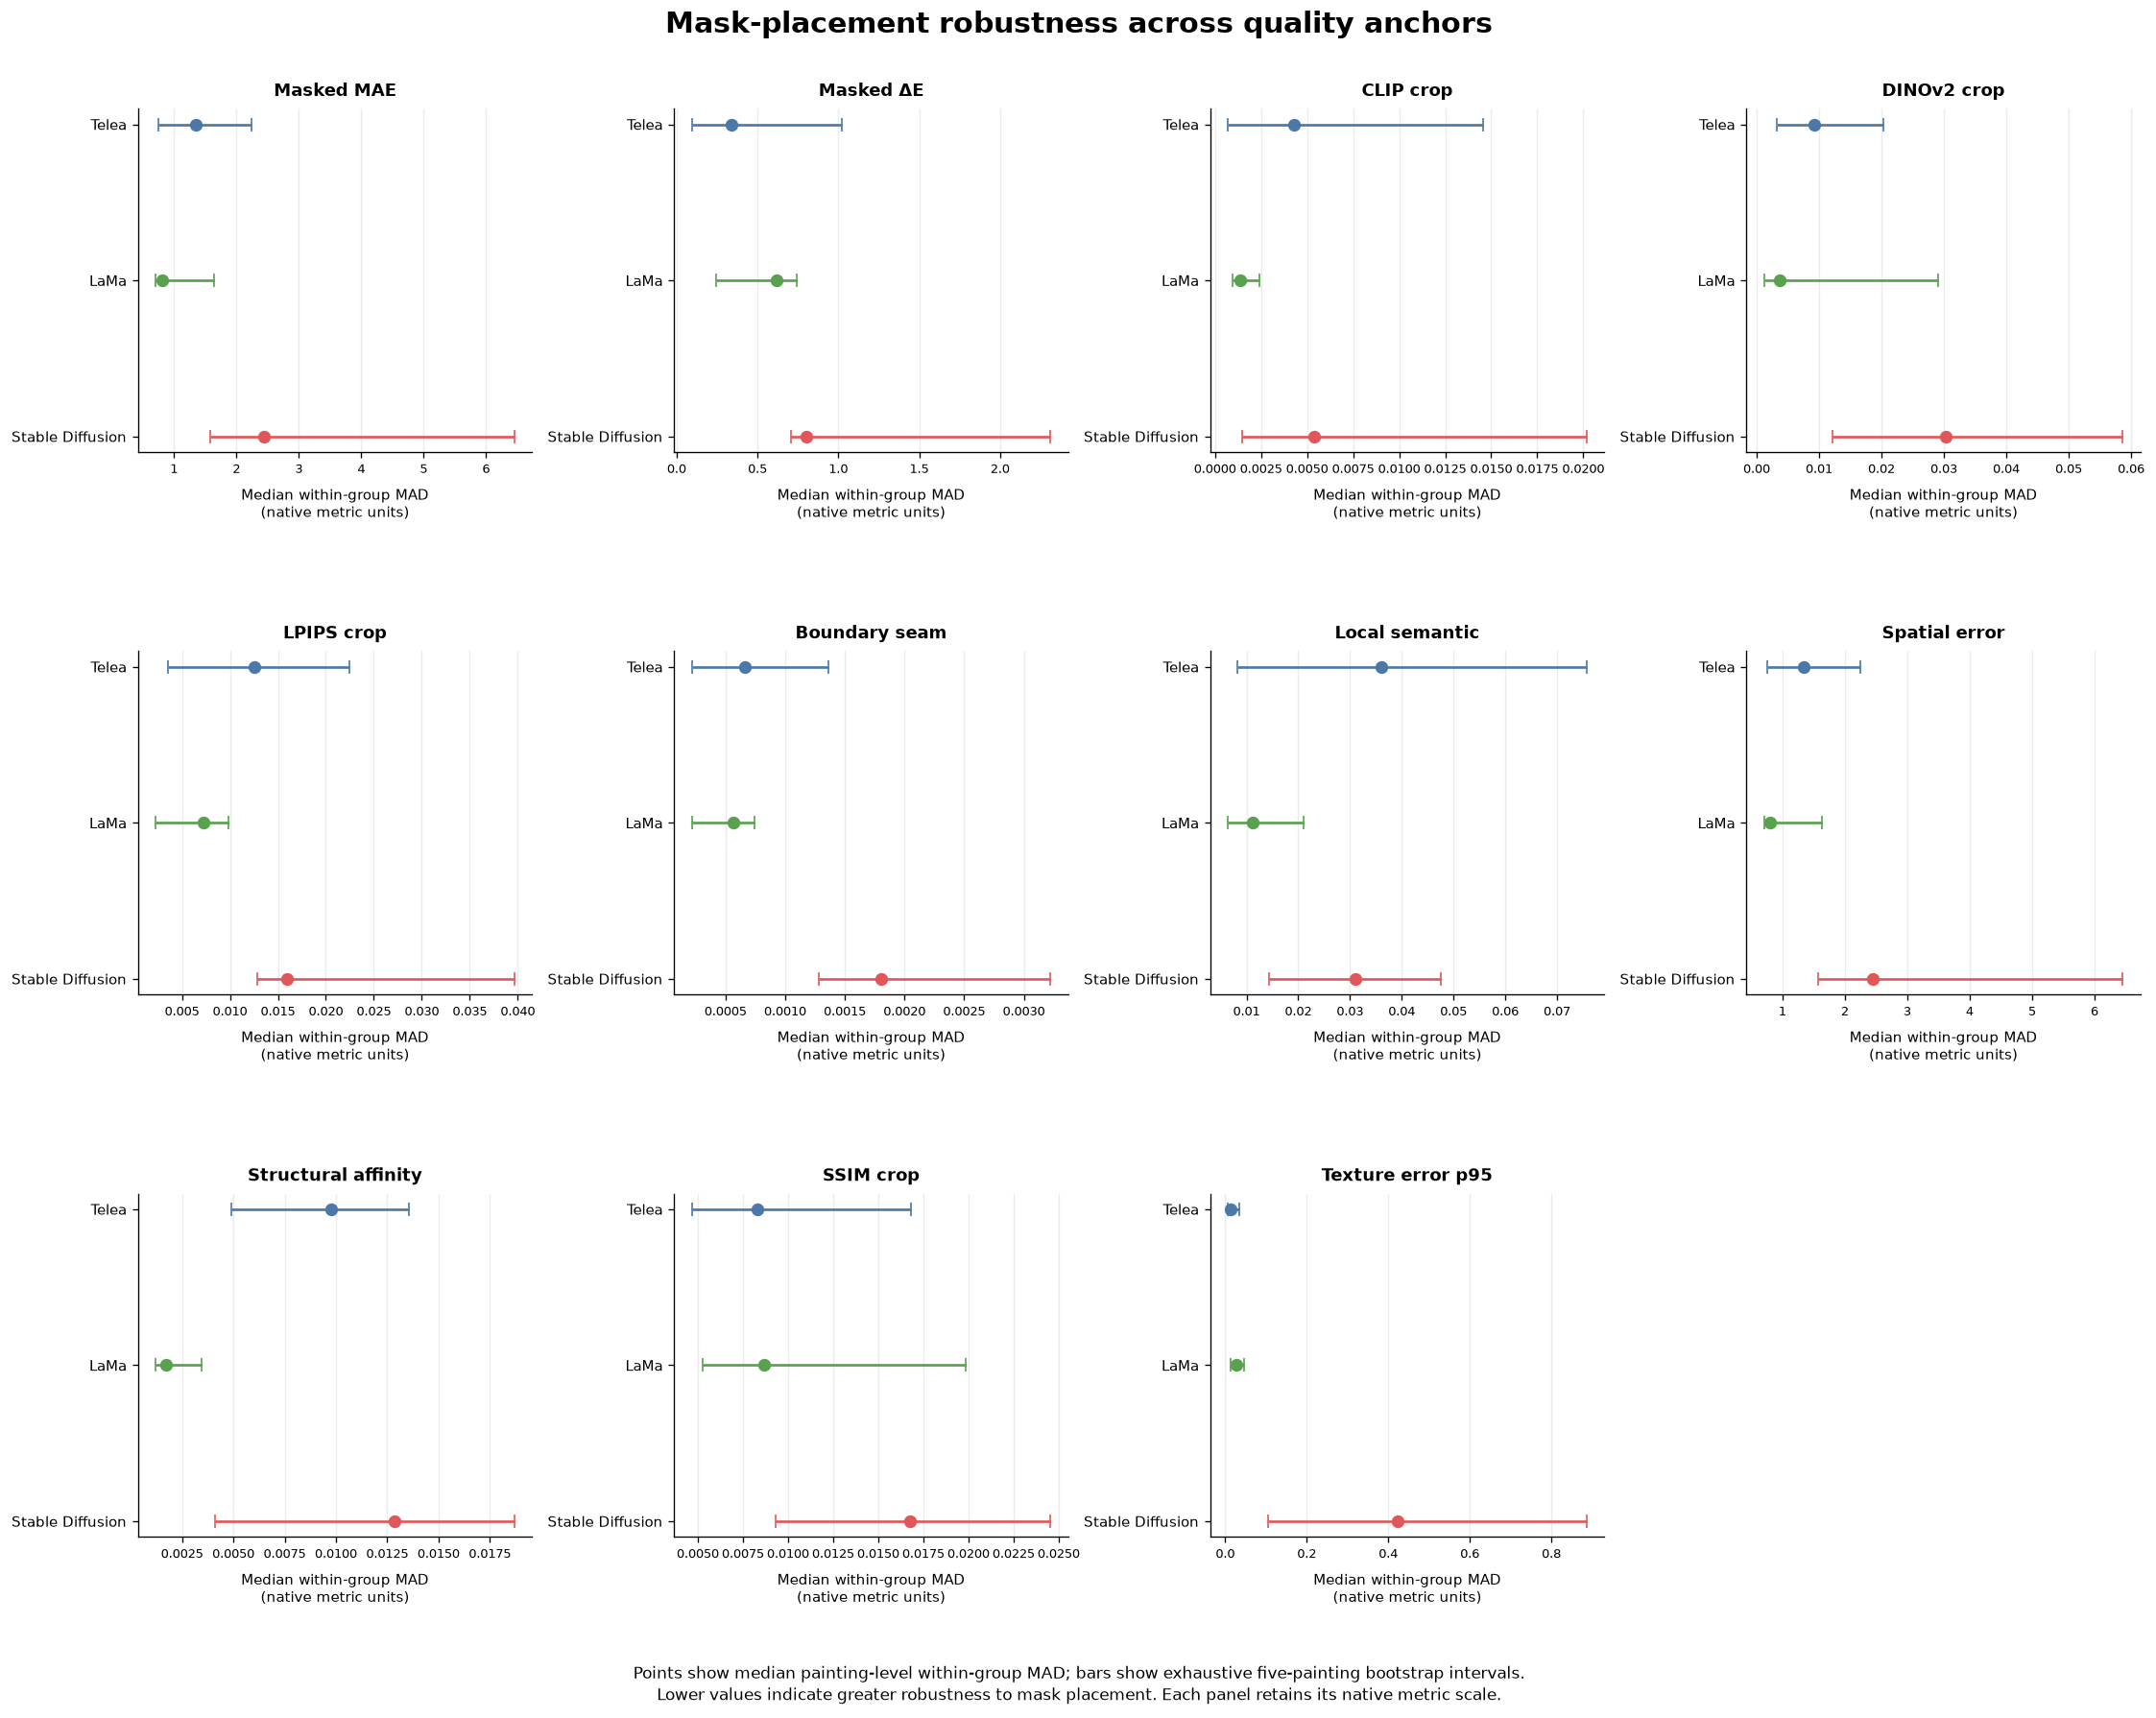

Saved canonical robustness-variance figure.
outputs/24_mask_robustness_analysis/figures/robustness_variance.png


In [32]:
MODEL_COLORS = {
    "opencv_telea": "#4C78A8",
    "lama": "#59A14F",
    "stable_diffusion_inpainting": "#E15759",
}

MODEL_SHORT_LABELS = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

ANCHOR_SHORT_LABELS = {
    "classical_masked_mae": "Masked MAE",
    "colour_masked_delta_e": "Masked ΔE",
    "feature_clip_crop": "CLIP crop",
    "feature_dino_crop": "DINOv2 crop",
    "perceptual_crop_lpips": "LPIPS crop",
    "seam_boundary_gradient": "Boundary seam",
    "semantic_local_dino": "Local semantic",
    "spatial_masked_error": "Spatial error",
    "structural_affinity_correlation": "Structural affinity",
    "structural_crop_ssim": "SSIM crop",
    "texture_crop_p95": "Texture error p95",
}

overall_robustness_data = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall")
    ]
    .copy()
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(19, 15.5),
    constrained_layout=False,
)

axes_flat = axes.ravel()

for axis_index, anchor_id in enumerate(
    sorted(
        overall_robustness_data[
            "anchor_id"
        ].astype(str).unique()
    )
):
    axis = axes_flat[axis_index]

    anchor_rows = (
        overall_robustness_data.loc[
            overall_robustness_data[
                "anchor_id"
            ].astype(str).eq(anchor_id)
        ]
        .set_index("model_id")
        .reindex(POPULATION["model_order"])
        .reset_index()
    )

    estimates = pd.to_numeric(
        anchor_rows["estimate"],
        errors="coerce",
    ).to_numpy(float)

    lower = pd.to_numeric(
        anchor_rows["ci_lower"],
        errors="coerce",
    ).to_numpy(float)

    upper = pd.to_numeric(
        anchor_rows["ci_upper"],
        errors="coerce",
    ).to_numpy(float)

    lower_error = np.maximum(
        estimates - lower,
        0.0,
    )
    upper_error = np.maximum(
        upper - estimates,
        0.0,
    )

    y_positions = np.arange(
        len(anchor_rows)
    )

    for position, row in enumerate(
        anchor_rows.itertuples(index=False)
    ):
        axis.errorbar(
            estimates[position],
            y_positions[position],
            xerr=np.array(
                [
                    [lower_error[position]],
                    [upper_error[position]],
                ]
            ),
            fmt="o",
            color=MODEL_COLORS[row.model_id],
            markersize=7,
            capsize=4,
            linewidth=1.6,
        )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(
        [
            MODEL_SHORT_LABELS[model_id]
            for model_id in anchor_rows[
                "model_id"
            ]
        ],
        fontsize=9,
    )
    axis.invert_yaxis()

    axis.set_title(
        ANCHOR_SHORT_LABELS.get(
            anchor_id,
            anchor_id,
        ),
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    axis.set_xlabel(
        "Median within-group MAD\n(native metric units)",
        fontsize=9,
        labelpad=7,
    )

    axis.tick_params(
        axis="x",
        labelsize=8,
    )

    axis.grid(
        axis="x",
        alpha=0.25,
    )
    axis.grid(
        axis="y",
        visible=False,
    )

for unused_axis in axes_flat[
    len(
        overall_robustness_data[
            "anchor_id"
        ].unique()
    ):
]:
    unused_axis.axis("off")

fig.suptitle(
    "Mask-placement robustness across quality anchors",
    fontsize=18,
    fontweight="bold",
    y=0.975,
)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.92,
    bottom=0.12,
    wspace=0.36,
    hspace=0.58,
)

fig.text(
    0.5,
    0.025,
    (
        "Points show median painting-level within-group MAD; "
        "bars show exhaustive five-painting bootstrap intervals.\n"
        "Lower values indicate greater robustness to mask placement. "
        "Each panel retains its native metric scale."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
    linespacing=1.35,
)

fig.savefig(
    OUTPUT_PATHS["robustness_figure"],
    format="png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

display(fig)
plt.close(fig)

print("Saved canonical robustness-variance figure.")
print(
    str(
        OUTPUT_PATHS[
            "robustness_figure"
        ].relative_to(PROJECT_ROOT)
    ).replace("\\", "/")
)

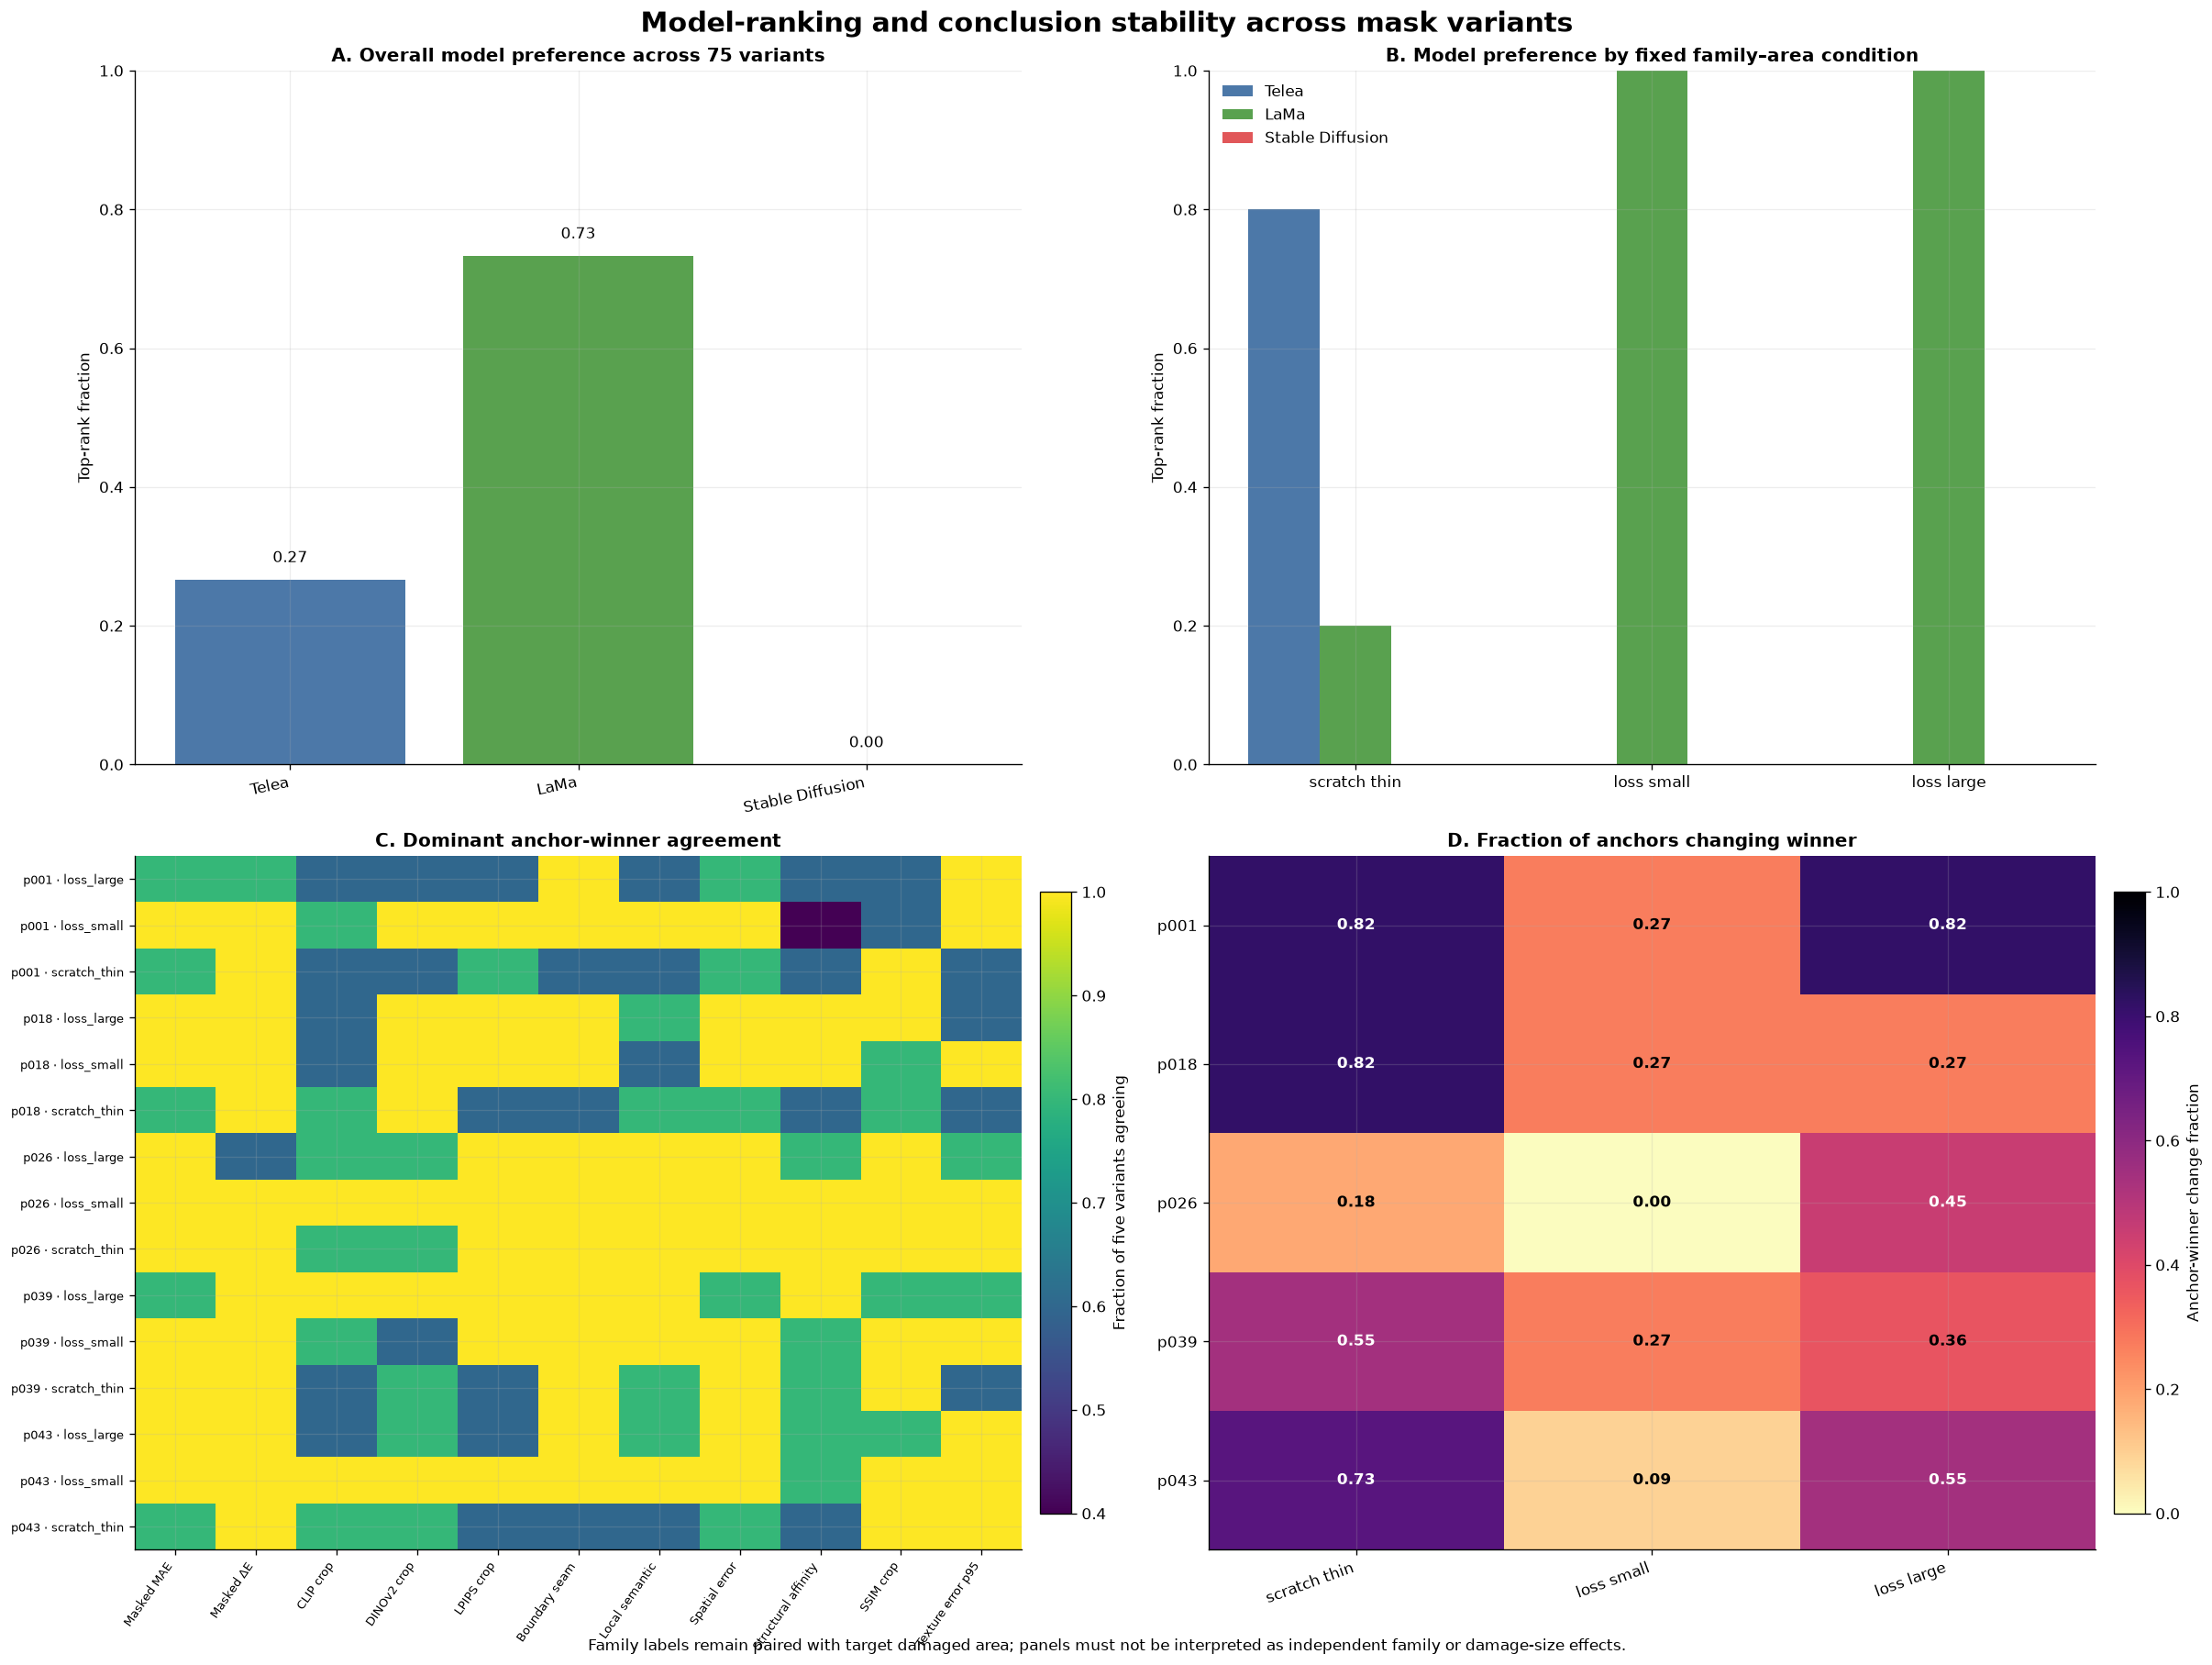

Saved canonical ranking-stability figure.
outputs/24_mask_robustness_analysis/figures/ranking_stability.png


In [33]:
overall_top_rank = (
    VARIANT_RANKS_RAW.groupby(
        "model_id"
    )["is_top_rank"]
    .mean()
    .reindex(
        POPULATION["model_order"]
    )
)

family_top_rank = (
    VARIANT_RANKS_RAW.groupby(
        ["mask_family", "model_id"]
    )["is_top_rank"]
    .mean()
    .unstack("model_id")
    .reindex(
        index=family_display_order,
        columns=POPULATION["model_order"],
    )
)

anchor_stability_matrix = (
    ANCHOR_WINNER_STABILITY_RAW.pivot_table(
        index=[
            "painting_id",
            "mask_family",
        ],
        columns="anchor_id",
        values="dominant_winner_fraction",
        aggfunc="first",
    )
    .reindex(
        columns=sorted(
            ANCHOR_WINNER_STABILITY_RAW[
                "anchor_id"
            ].astype(str).unique()
        )
    )
)

anchor_stability_matrix.index = [
    f"{painting_id} · {mask_family}"
    for painting_id, mask_family
    in anchor_stability_matrix.index
]

group_sensitivity_matrix = (
    GROUP_SENSITIVITY_ANALYSIS.pivot_table(
        index="painting_id",
        columns="mask_family",
        values="estimate",
        aggfunc="first",
    )
    .reindex(
        index=POPULATION["painting_ids"],
        columns=family_display_order,
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(20, 15),
    constrained_layout=True,
)

# Panel A: overall top-rank fraction
axis = axes[0, 0]
models = list(POPULATION["model_order"])
positions = np.arange(len(models))

axis.bar(
    positions,
    overall_top_rank.to_numpy(float),
    color=[
        MODEL_COLORS[model_id]
        for model_id in models
    ],
)
axis.set_xticks(positions)
axis.set_xticklabels(
    [
        MODEL_SHORT_LABELS[model_id]
        for model_id in models
    ],
    rotation=12,
    ha="right",
)
axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Top-rank fraction")
axis.set_title(
    "A. Overall model preference across 75 variants",
    fontweight="bold",
)

for position, value in enumerate(
    overall_top_rank
):
    axis.text(
        position,
        float(value) + 0.025,
        f"{float(value):.2f}",
        ha="center",
        fontsize=10,
    )

# Panel B: top-rank fraction by family
axis = axes[0, 1]
family_positions = np.arange(
    len(family_display_order)
)
bar_width = 0.24

for model_index, model_id in enumerate(models):
    offsets = (
        family_positions
        + (
            model_index
            - (len(models) - 1) / 2
        )
        * bar_width
    )
    axis.bar(
        offsets,
        family_top_rank[
            model_id
        ].to_numpy(float),
        width=bar_width,
        color=MODEL_COLORS[model_id],
        label=MODEL_SHORT_LABELS[model_id],
    )

axis.set_xticks(family_positions)
axis.set_xticklabels(
    [
        family.replace("_", " ")
        for family in family_display_order
    ]
)
axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Top-rank fraction")
axis.set_title(
    "B. Model preference by fixed family–area condition",
    fontweight="bold",
)
axis.legend(frameon=False)

# Panel C: anchor-winner stability
axis = axes[1, 0]
stability_image = axis.imshow(
    anchor_stability_matrix.to_numpy(float),
    aspect="auto",
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
)
axis.set_yticks(
    np.arange(
        len(anchor_stability_matrix)
    )
)
axis.set_yticklabels(
    anchor_stability_matrix.index,
    fontsize=8,
)
axis.set_xticks(
    np.arange(
        len(anchor_stability_matrix.columns)
    )
)
axis.set_xticklabels(
    [
        ANCHOR_SHORT_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in (
            anchor_stability_matrix.columns
        )
    ],
    rotation=55,
    ha="right",
    fontsize=8,
)
axis.set_title(
    "C. Dominant anchor-winner agreement",
    fontweight="bold",
)
colorbar = fig.colorbar(
    stability_image,
    ax=axis,
    fraction=0.035,
    pad=0.02,
)
colorbar.set_label(
    "Fraction of five variants agreeing"
)

# Panel D: conclusion sensitivity
axis = axes[1, 1]
sensitivity_image = axis.imshow(
    group_sensitivity_matrix.to_numpy(float),
    aspect="auto",
    cmap="magma_r",
    vmin=0.0,
    vmax=1.0,
)
axis.set_yticks(
    np.arange(
        len(group_sensitivity_matrix)
    )
)
axis.set_yticklabels(
    group_sensitivity_matrix.index
)
axis.set_xticks(
    np.arange(
        len(group_sensitivity_matrix.columns)
    )
)
axis.set_xticklabels(
    [
        family.replace("_", " ")
        for family in (
            group_sensitivity_matrix.columns
        )
    ],
    rotation=20,
    ha="right",
)
axis.set_title(
    "D. Fraction of anchors changing winner",
    fontweight="bold",
)

for row_index in range(
    group_sensitivity_matrix.shape[0]
):
    for column_index in range(
        group_sensitivity_matrix.shape[1]
    ):
        value = float(
            group_sensitivity_matrix.iloc[
                row_index,
                column_index,
            ]
        )
        axis.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if value >= 0.45
                else "black"
            ),
            fontsize=10,
            fontweight="bold",
        )

colorbar = fig.colorbar(
    sensitivity_image,
    ax=axis,
    fraction=0.035,
    pad=0.02,
)
colorbar.set_label(
    "Anchor-winner change fraction"
)

fig.suptitle(
    "Model-ranking and conclusion stability across mask variants",
    fontsize=18,
    fontweight="bold",
)
fig.text(
    0.5,
    0.002,
    (
        "Family labels remain paired with target damaged area; "
        "panels must not be interpreted as independent family "
        "or damage-size effects."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
)

fig.savefig(
    OUTPUT_PATHS["ranking_figure"],
    format="png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

display(fig)
plt.close(fig)

print("Saved canonical ranking-stability figure.")
print(
    str(
        OUTPUT_PATHS[
            "ranking_figure"
        ].relative_to(PROJECT_ROOT)
    ).replace("\\", "/")
)

In [34]:
def inspect_png(
    path: Path,
) -> dict:
    """Inspect a persisted PNG without modifying it."""
    with Image.open(path) as image:
        return {
            "path": str(
                path.relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
            "format": image.format,
            "mode": image.mode,
            "width": image.width,
            "height": image.height,
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }


FIGURE_INSPECTION = pd.DataFrame(
    [
        inspect_png(
            OUTPUT_PATHS[
                "robustness_figure"
            ]
        ),
        inspect_png(
            OUTPUT_PATHS[
                "ranking_figure"
            ]
        ),
    ]
)

overall_anchor_winners = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall")
    ]
    .sort_values(
        ["anchor_id", "estimate"],
        kind="stable",
    )
    .groupby(
        "anchor_id",
        as_index=False,
    )
    .first()
)

descriptive_stability_winner_counts = (
    overall_anchor_winners[
        "model_id"
    ]
    .value_counts()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
    .rename("anchors_with_lowest_mad")
    .reset_index()
    .rename(columns={"index": "model_id"})
)

paired_fdr_resolved = int(
    PAIRED_MODEL_CONTRAST_ANALYSIS[
        "interpretation_status"
    ].ne(
        "no_clear_paired_robustness_difference"
    ).sum()
)

morphology_fdr_resolved = int(
    MORPHOLOGY_ASSOCIATION_ANALYSIS[
        "interpretation_status"
    ].isin(
        {
            "higher_geometry_value_associated_with_worse_quality",
            "higher_geometry_value_associated_with_better_quality",
        }
    ).sum()
)

family_sensitivity_summary = (
    GROUP_SENSITIVITY_ANALYSIS.groupby(
        "mask_family"
    )["estimate"]
    .agg(
        ["median", "min", "max"]
    )
    .reset_index()
    .rename(
        columns={
            "median": "median_winner_change_fraction",
            "min": "minimum_winner_change_fraction",
            "max": "maximum_winner_change_fraction",
        }
    )
)

display(FIGURE_INSPECTION)
display(descriptive_stability_winner_counts)
display(family_sensitivity_summary)

print("Scientific result summary prepared.")
print(
    "FDR-resolved paired robustness contrasts: "
    f"{paired_fdr_resolved}"
)
print(
    "FDR-resolved morphology associations: "
    f"{morphology_fdr_resolved}"
)

,path,format,mode,width,height,size_bytes,sha256
0,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,PNG,RGBA,3372,2686,352029,b78881a07b2c51cb0ae38c412c2253e56f9c866b59983f0fbb076ecbb57a5722
1,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,PNG,RGBA,3618,2723,351438,54bf95fb3ed2f029551d024fc61319cc53a345fbd38e6b20dc10ec25fbab166f


,model_id,anchors_with_lowest_mad
0,opencv_telea,3
1,lama,8
2,stable_diffusion_inpainting,0


,mask_family,median_winner_change_fraction,minimum_winner_change_fraction,maximum_winner_change_fraction
0,loss_large,0.454545,0.272727,0.818182
1,loss_small,0.272727,0.000000,0.272727
2,scratch_thin,0.727273,0.181818,0.818182


Scientific result summary prepared.
FDR-resolved paired robustness contrasts: 0
FDR-resolved morphology associations: 0


In [35]:
canonical_files_after_batch_8 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

expected_files_after_batch_8 = {
    OUTPUT_PATHS["metrics"].resolve(),
    OUTPUT_PATHS[
        "robustness_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "ranking_figure"
    ].resolve(),
}

observed_files_after_batch_8 = {
    path.resolve()
    for path in canonical_files_after_batch_8
}

figure_files_valid = bool(
    len(FIGURE_INSPECTION) == 2
    and FIGURE_INSPECTION[
        "format"
    ].eq("PNG").all()
    and pd.to_numeric(
        FIGURE_INSPECTION["width"],
        errors="coerce",
    ).ge(1200).all()
    and pd.to_numeric(
        FIGURE_INSPECTION["height"],
        errors="coerce",
    ).ge(800).all()
    and pd.to_numeric(
        FIGURE_INSPECTION["size_bytes"],
        errors="coerce",
    ).gt(0).all()
)

no_prohibited_analysis_terms = not (
    MASK_ROBUSTNESS_ANALYSIS.astype(str)
    .apply(
        lambda column: column.str.contains(
            (
                "combined_quality|combined_uncertainty|"
                "trust_score|calibrated confidence"
            ),
            case=False,
            regex=True,
        )
    )
    .any()
    .any()
)

family_area_mapping_preserved = (
    dict(
        POPULATION[
            "target_damage_fraction_by_family"
        ]
    )
    == {
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    }
)

VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="canonical_metrics_persisted",
    check_description=(
        "The complete canonical CSV exists and reloads successfully."
    ),
    severity="blocking",
    expected={
        "rows": 5373,
        "schema_passed": True,
    },
    observed=analysis_roundtrip_summary,
    passed=(
        OUTPUT_PATHS["metrics"].is_file()
        and len(RELOADED_ANALYSIS) == 5373
        and bool(
            reloaded_schema_validation["passed"]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="canonical_metrics_roundtrip",
    check_description=(
        "Row IDs and numeric estimates survive persistence."
    ),
    severity="blocking",
    expected={
        "row_ids_match": True,
        "estimates_match": True,
    },
    observed={
        "row_ids_match": (
            analysis_roundtrip_summary[
                "row_ids_match"
            ]
        ),
        "estimates_match": (
            analysis_roundtrip_summary[
                "estimates_match"
            ]
        ),
    },
    passed=(
        bool(
            analysis_roundtrip_summary[
                "row_ids_match"
            ]
        )
        and bool(
            analysis_roundtrip_summary[
                "estimates_match"
            ]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="canonical_figures_valid",
    check_description=(
        "Both canonical figures are valid non-empty PNG files."
    ),
    severity="blocking",
    expected={
        "figures": 2,
        "format": "PNG",
        "minimum_width": 1200,
        "minimum_height": 800,
    },
    observed=FIGURE_INSPECTION[
        [
            "path",
            "format",
            "width",
            "height",
            "size_bytes",
        ]
    ].to_dict("records"),
    passed=figure_files_valid,
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="batch_8_owned_file_set",
    check_description=(
        "Only the three approved Batch 8 artifacts exist."
    ),
    severity="blocking",
    expected=sorted(
        str(path.relative_to(PROJECT_ROOT))
        .replace("\\", "/")
        for path in expected_files_after_batch_8
    ),
    observed=sorted(
        str(path.relative_to(PROJECT_ROOT))
        .replace("\\", "/")
        for path in observed_files_after_batch_8
    ),
    passed=(
        observed_files_after_batch_8
        == expected_files_after_batch_8
    ),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="paired_inference_interpreted_cautiously",
    check_description=(
        "Paired robustness claims require corrected inferential support."
    ),
    severity="blocking",
    expected={
        "resolved_contrasts": 0,
        "unsupported_binary_claims": 0,
    },
    observed={
        "resolved_contrasts": paired_fdr_resolved,
        "total_contrasts": len(
            PAIRED_MODEL_CONTRAST_ANALYSIS
        ),
    },
    passed=paired_fdr_resolved == 0,
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="morphology_interpreted_as_exploratory",
    check_description=(
        "Morphology assertions require corrected support."
    ),
    severity="blocking",
    expected={
        "resolved_associations": 0,
        "interpretation": "exploratory",
    },
    observed={
        "resolved_associations": (
            morphology_fdr_resolved
        ),
        "total_associations": len(
            MORPHOLOGY_ASSOCIATION_ANALYSIS
        ),
    },
    passed=morphology_fdr_resolved == 0,
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="family_area_boundary_preserved",
    check_description=(
        "Family and target area remain explicitly paired."
    ),
    severity="blocking",
    expected={
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
    observed=dict(
        POPULATION[
            "target_damage_fraction_by_family"
        ]
    ),
    passed=family_area_mapping_preserved,
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="runtime_remains_operational",
    check_description=(
        "No runtime-derived row is eligible for quality ranking."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        as_boolean(
            MASK_ROBUSTNESS_ANALYSIS.loc[
                MASK_ROBUSTNESS_ANALYSIS[
                    "analysis_kind"
                ].isin(
                    {
                        "runtime_group_dispersion",
                        "runtime_model_summary",
                    }
                ),
                "quality_ranking_eligible",
            ]
        ).sum()
    ),
    passed=not as_boolean(
        MASK_ROBUSTNESS_ANALYSIS.loc[
            MASK_ROBUSTNESS_ANALYSIS[
                "analysis_kind"
            ].isin(
                {
                    "runtime_group_dispersion",
                    "runtime_model_summary",
                }
            ),
            "quality_ranking_eligible",
        ]
    ).any(),
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="no_prohibited_scores_or_claims",
    check_description=(
        "The canonical analysis contains no prohibited score or claim."
    ),
    severity="blocking",
    expected=True,
    observed=no_prohibited_analysis_terms,
    passed=no_prohibited_analysis_terms,
)
VALIDATION.add(
    validation_stage="batch_8_persistence_figures",
    check_id="work_directory_empty",
    check_description=(
        "No temporary work files remain after persistence."
    ),
    severity="blocking",
    expected=0,
    observed=len(
        [
            path
            for path in WORK_ROOT.rglob("*")
            if path.is_file()
        ]
    ),
    passed=not any(
        path.is_file()
        for path in WORK_ROOT.rglob("*")
    ),
)

BATCH_8_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_8_persistence_figures"
    ]
    .reset_index(drop=True)
)

BATCH_8_SUMMARY = VALIDATION.summary()

display(BATCH_8_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 8 passed.")
print(
    "Canonical analysis rows: "
    f"{len(RELOADED_ANALYSIS):,}"
)
print("Canonical figures: 2")
print(
    "Blocking failures so far: "
    f"{BATCH_8_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: mock-aligned report, manifests, "
    "final validation, and completion traceability."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_persistence_figures,canonical_metrics_persisted,The complete canonical CSV exists and reloads successfully.,blocking,"{""rows"": 5373, ""schema_passed"": true}","{""columns_reloaded"": 51, ""columns_written"": 51, ""estimates_match"": true, ""row_ids_match"": true, ""rows_reloaded"": 5373, ""rows_written"": 5...",True,
1,batch_8_persistence_figures,canonical_metrics_roundtrip,Row IDs and numeric estimates survive persistence.,blocking,"{""estimates_match"": true, ""row_ids_match"": true}","{""estimates_match"": true, ""row_ids_match"": true}",True,
2,batch_8_persistence_figures,canonical_figures_valid,Both canonical figures are valid non-empty PNG files.,blocking,"{""figures"": 2, ""format"": ""PNG"", ""minimum_height"": 800, ""minimum_width"": 1200}","[{""format"": ""PNG"", ""height"": 2686, ""path"": ""outputs/24_mask_robustness_analysis/figures/robustness_variance.png"", ""size_bytes"": 352029, ...",True,
3,batch_8_persistence_figures,batch_8_owned_file_set,Only the three approved Batch 8 artifacts exist.,blocking,"[""outputs/24_mask_robustness_analysis/figures/ranking_stability.png"", ""outputs/24_mask_robustness_analysis/figures/robustness_variance.p...","[""outputs/24_mask_robustness_analysis/figures/ranking_stability.png"", ""outputs/24_mask_robustness_analysis/figures/robustness_variance.p...",True,
4,batch_8_persistence_figures,paired_inference_interpreted_cautiously,Paired robustness claims require corrected inferential support.,blocking,"{""resolved_contrasts"": 0, ""unsupported_binary_claims"": 0}","{""resolved_contrasts"": 0, ""total_contrasts"": 132}",True,
5,batch_8_persistence_figures,morphology_interpreted_as_exploratory,Morphology assertions require corrected support.,blocking,"{""interpretation"": ""exploratory"", ""resolved_associations"": 0}","{""resolved_associations"": 0, ""total_associations"": 297}",True,
6,batch_8_persistence_figures,family_area_boundary_preserved,Family and target area remain explicitly paired.,blocking,"{""loss_large"": 0.125, ""loss_small"": 0.045, ""scratch_thin"": 0.02}","{""loss_large"": 0.125, ""loss_small"": 0.045, ""scratch_thin"": 0.02}",True,
7,batch_8_persistence_figures,runtime_remains_operational,No runtime-derived row is eligible for quality ranking.,blocking,0,0,True,
8,batch_8_persistence_figures,no_prohibited_scores_or_claims,The canonical analysis contains no prohibited score or claim.,blocking,True,True,True,
9,batch_8_persistence_figures,work_directory_empty,No temporary work files remain after persistence.,blocking,0,0,True,


Batch 8 passed.
Canonical analysis rows: 5,373
Canonical figures: 2
Blocking failures so far: 0
Next batch: mock-aligned report, manifests, final validation, and completion traceability.


## Batch 9 — Mock-aligned report, manifests, and completion gate

This final batch:

- derives report conclusions from the validated canonical analysis;
- creates ten embedded analytical views;
- creates eight embedded restoration or diagnostic panels;
- preserves the approved 13-section mock-report structure;
- embeds every required image directly into one standalone HTML file;
- validates report density, section order, scientific limits, and mock fidelity;
- writes the consolidated validation table;
- writes artifact and run manifests;
- updates the normalized project-path registry;
- performs the final completion sweep.

Report-only plots and image grids are held in memory and embedded directly in the HTML. They are not persisted as additional notebook-owned files.

In [36]:
import base64
import io
import os
import re
import time
from html import escape

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from PIL import Image
from IPython.display import HTML as NotebookHTML

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.multi_model_comparison import (
    image_grid_to_data_uri,
    image_path_to_data_uri,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


REPORT_ANALYSIS = RELOADED_ANALYSIS.copy()

MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

FAMILY_LABELS = {
    "scratch_thin": "Thin scratch · fixed at 2%",
    "loss_small": "Small loss · fixed at 4.5%",
    "loss_large": "Large loss · fixed at 12.5%",
}

ANCHOR_LABELS = {
    "classical_masked_mae": "Masked MAE",
    "colour_masked_delta_e": "Masked ΔE",
    "feature_clip_crop": "CLIP crop",
    "feature_dino_crop": "DINOv2 crop",
    "perceptual_crop_lpips": "LPIPS crop",
    "seam_boundary_gradient": "Boundary seam",
    "semantic_local_dino": "Local semantic",
    "spatial_masked_error": "Spatial error",
    "structural_affinity_correlation": "Structural affinity",
    "structural_crop_ssim": "SSIM crop",
    "texture_crop_p95": "Texture error p95",
}


def figure_to_data_uri(
    figure,
    *,
    max_dimension=900,
    quality=82,
):
    """Encode a report-only figure as a web-sized JPEG data URI."""
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=140,
        bbox_inches="tight",
        facecolor="white",
    )
    buffer.seek(0)

    with Image.open(buffer) as opened:
        image = opened.convert("RGB")
        image.thumbnail(
            (int(max_dimension), int(max_dimension)),
            Image.Resampling.LANCZOS,
        )

        encoded_buffer = io.BytesIO()
        image.save(
            encoded_buffer,
            format="JPEG",
            quality=int(quality),
            optimize=True,
        )

    payload = base64.b64encode(
        encoded_buffer.getvalue()
    ).decode("ascii")

    return f"data:image/jpeg;base64,{payload}"


def atomic_write_text_retry(
    output_path,
    text,
    *,
    attempts=5,
):
    """Write text atomically with short Windows retry handling."""
    destination = Path(output_path)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt in range(1, attempts + 1):
        try:
            temporary.write_text(
                text,
                encoding="utf-8",
                newline="\n",
            )
            os.replace(
                temporary,
                destination,
            )
            return attempt

        except PermissionError as exc:
            last_error = exc
            temporary.unlink(missing_ok=True)

            if attempt < attempts:
                time.sleep(0.25 * attempt)

    raise last_error


def report_table(
    frame,
    *,
    maximum_rows=None,
):
    """Render a compact HTML table."""
    table = frame.copy()

    if maximum_rows is not None:
        table = table.head(int(maximum_rows))

    return table.to_html(
        index=False,
        border=0,
        classes="data-table",
        na_rep="—",
        float_format=lambda value: f"{value:.4f}",
        escape=True,
    )


OVERALL_MAD_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("model_dispersion_summary")
        & REPORT_ANALYSIS["scope_type"]
        .astype(str)
        .eq("overall")
    ]
    .copy()
)

OVERALL_MAD_ROWS["estimate"] = pd.to_numeric(
    OVERALL_MAD_ROWS["estimate"],
    errors="coerce",
)

overall_winner_indices = (
    OVERALL_MAD_ROWS.groupby(
        "anchor_id",
        observed=True,
    )["estimate"]
    .idxmin()
)

OVERALL_MAD_WINNERS = (
    OVERALL_MAD_ROWS.loc[
        overall_winner_indices
    ]
    .copy()
    .sort_values("anchor_id")
)

overall_mad_winner_counts = (
    OVERALL_MAD_WINNERS["model_id"]
    .astype(str)
    .value_counts()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
)

VARIANT_RANK_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("variant_family_balanced_rank")
    ]
    .copy()
)

VARIANT_RANK_REPORT_ROWS["effect_size"] = (
    pd.to_numeric(
        VARIANT_RANK_REPORT_ROWS["effect_size"],
        errors="coerce",
    )
)

variant_top_rank_counts = (
    VARIANT_RANK_REPORT_ROWS.loc[
        VARIANT_RANK_REPORT_ROWS[
            "interpretation_status"
        ]
        .astype(str)
        .eq("top_rank")
    ]
    .groupby("model_id")
    .size()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
)

SENSITIVITY_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("group_sensitivity_summary")
    ]
    .copy()
)

SENSITIVITY_REPORT_ROWS["estimate"] = (
    pd.to_numeric(
        SENSITIVITY_REPORT_ROWS["estimate"],
        errors="coerce",
    )
)

SENSITIVITY_REPORT_ROWS["effect_size"] = (
    pd.to_numeric(
        SENSITIVITY_REPORT_ROWS["effect_size"],
        errors="coerce",
    )
)

FAMILY_SENSITIVITY_REPORT = (
    SENSITIVITY_REPORT_ROWS.groupby(
        "mask_family",
        observed=True,
    )
    .agg(
        median_changed_fraction=("estimate", "median"),
        minimum_changed_fraction=("estimate", "min"),
        maximum_changed_fraction=("estimate", "max"),
        median_changed_anchors=("effect_size", "median"),
    )
    .reindex(POPULATION["mask_family_order"])
    .reset_index()
)

FAMILY_SENSITIVITY_REPORT[
    "Mask condition"
] = (
    FAMILY_SENSITIVITY_REPORT[
        "mask_family"
    ].map(FAMILY_LABELS)
)

FAMILY_SENSITIVITY_REPORT[
    "Median anchors changing winner"
] = (
    FAMILY_SENSITIVITY_REPORT[
        "median_changed_anchors"
    ]
)

FAMILY_SENSITIVITY_REPORT[
    "Median changed fraction"
] = (
    FAMILY_SENSITIVITY_REPORT[
        "median_changed_fraction"
    ]
)

FAMILY_SENSITIVITY_REPORT[
    "Observed range"
] = (
    FAMILY_SENSITIVITY_REPORT.apply(
        lambda row: (
            f"{row['minimum_changed_fraction']:.2f}"
            f"–{row['maximum_changed_fraction']:.2f}"
        ),
        axis=1,
    )
)

FAMILY_SENSITIVITY_TABLE = (
    FAMILY_SENSITIVITY_REPORT[
        [
            "Mask condition",
            "Median anchors changing winner",
            "Median changed fraction",
            "Observed range",
        ]
    ]
)

stable_group_row = (
    SENSITIVITY_REPORT_ROWS.sort_values(
        [
            "estimate",
            "robustness_group_id",
        ],
        ascending=[True, True],
        kind="stable",
    )
    .iloc[0]
)

sensitive_group_row = (
    SENSITIVITY_REPORT_ROWS.sort_values(
        [
            "estimate",
            "robustness_group_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .iloc[0]
)

stable_group_id = str(
    stable_group_row["robustness_group_id"]
)
sensitive_group_id = str(
    sensitive_group_row["robustness_group_id"]
)

PAIRED_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("paired_model_dispersion_contrast")
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "p_value",
    "q_value",
):
    PAIRED_REPORT_ROWS[column] = pd.to_numeric(
        PAIRED_REPORT_ROWS[column],
        errors="coerce",
    )

paired_fdr_resolved = int(
    PAIRED_REPORT_ROWS[
        "interpretation_status"
    ]
    .astype(str)
    .ne(
        "no_clear_paired_robustness_difference"
    )
    .sum()
)

MORPHOLOGY_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("morphology_association")
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "p_value",
    "q_value",
):
    MORPHOLOGY_REPORT_ROWS[column] = pd.to_numeric(
        MORPHOLOGY_REPORT_ROWS[column],
        errors="coerce",
    )

MORPHOLOGY_REPORT_ROWS["absolute_rho"] = (
    MORPHOLOGY_REPORT_ROWS["estimate"].abs()
)

morphology_fdr_resolved = int(
    MORPHOLOGY_REPORT_ROWS[
        "interpretation_status"
    ]
    .astype(str)
    .ne(
        "no_clear_exploratory_association"
    )
    .sum()
)

RUNTIME_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("runtime_model_summary")
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
):
    RUNTIME_REPORT_ROWS[column] = pd.to_numeric(
        RUNTIME_REPORT_ROWS[column],
        errors="coerce",
    )

overall_robustness_table = (
    OVERALL_MAD_ROWS.pivot(
        index="anchor_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        columns=POPULATION["model_order"]
    )
    .reset_index()
)

overall_robustness_table[
    "Lowest descriptive MAD"
] = (
    OVERALL_MAD_WINNERS.set_index(
        "anchor_id"
    )
    .reindex(
        overall_robustness_table[
            "anchor_id"
        ]
    )["model_id"]
    .map(MODEL_LABELS)
    .to_numpy()
)

overall_robustness_table[
    "anchor_id"
] = overall_robustness_table[
    "anchor_id"
].map(ANCHOR_LABELS)

overall_robustness_table = (
    overall_robustness_table.rename(
        columns={
            "anchor_id": "Quality anchor",
            "opencv_telea": "Telea MAD",
            "lama": "LaMa MAD",
            "stable_diffusion_inpainting": (
                "Stable Diffusion MAD"
            ),
        }
    )
)

top_rank_table = pd.DataFrame(
    {
        "Model": [
            MODEL_LABELS[model_id]
            for model_id in POPULATION[
                "model_order"
            ]
        ],
        "Top-ranked variants": [
            int(variant_top_rank_counts[model_id])
            for model_id in POPULATION[
                "model_order"
            ]
        ],
    }
)

top_rank_table["Fraction of 75 variants"] = (
    top_rank_table["Top-ranked variants"]
    / int(EXPECTED["cases"])
)

painting_sensitivity_table = (
    SENSITIVITY_REPORT_ROWS.groupby(
        "painting_id",
        observed=True,
    )
    .agg(
        median_changed_fraction=("estimate", "median"),
        minimum_changed_fraction=("estimate", "min"),
        maximum_changed_fraction=("estimate", "max"),
    )
    .reset_index()
    .sort_values(
        "median_changed_fraction",
        ascending=False,
        kind="stable",
    )
    .rename(
        columns={
            "painting_id": "Painting",
            "median_changed_fraction": (
                "Median changed fraction"
            ),
            "minimum_changed_fraction": "Minimum",
            "maximum_changed_fraction": "Maximum",
        }
    )
)

runtime_report_table = (
    RUNTIME_REPORT_ROWS.loc[
        RUNTIME_REPORT_ROWS["scope_type"]
        .astype(str)
        .eq("overall")
    ]
    [
        [
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ]
    ]
    .copy()
    .sort_values("estimate")
    .rename(
        columns={
            "model_id": "Model",
            "estimate": "Median runtime MAD (s)",
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
        }
    )
)

runtime_report_table["Model"] = (
    runtime_report_table["Model"]
    .map(MODEL_LABELS)
)

morphology_report_table = (
    MORPHOLOGY_REPORT_ROWS.sort_values(
        [
            "absolute_rho",
            "q_value",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .head(12)
    [
        [
            "morphology_field",
            "anchor_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "q_value",
        ]
    ]
    .copy()
    .rename(
        columns={
            "morphology_field": "Geometry field",
            "anchor_id": "Quality anchor",
            "model_id": "Model",
            "estimate": "Spearman rho",
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "q_value": "FDR q-value",
        }
    )
)

morphology_report_table["Quality anchor"] = (
    morphology_report_table[
        "Quality anchor"
    ].map(ANCHOR_LABELS)
)

morphology_report_table["Model"] = (
    morphology_report_table["Model"]
    .map(MODEL_LABELS)
)

report_finding_summary = {
    "lama_lowest_mad_anchors": int(
        overall_mad_winner_counts["lama"]
    ),
    "telea_lowest_mad_anchors": int(
        overall_mad_winner_counts[
            "opencv_telea"
        ]
    ),
    "sd_lowest_mad_anchors": int(
        overall_mad_winner_counts[
            "stable_diffusion_inpainting"
        ]
    ),
    "lama_top_rank_variants": int(
        variant_top_rank_counts["lama"]
    ),
    "telea_top_rank_variants": int(
        variant_top_rank_counts[
            "opencv_telea"
        ]
    ),
    "sd_top_rank_variants": int(
        variant_top_rank_counts[
            "stable_diffusion_inpainting"
        ]
    ),
    "paired_fdr_resolved": paired_fdr_resolved,
    "morphology_fdr_resolved": (
        morphology_fdr_resolved
    ),
    "most_stable_group": stable_group_id,
    "most_sensitive_group": sensitive_group_id,
}

display(
    pd.DataFrame(
        [report_finding_summary]
    )
)
display(top_rank_table)
display(FAMILY_SENSITIVITY_TABLE)

print("Report evidence and conclusions prepared.")
print(
    "All directional claims will be populated from "
    "validated Notebook 24 evidence."
)

,lama_lowest_mad_anchors,telea_lowest_mad_anchors,sd_lowest_mad_anchors,lama_top_rank_variants,telea_top_rank_variants,sd_top_rank_variants,paired_fdr_resolved,morphology_fdr_resolved,most_stable_group,most_sensitive_group
0,8,3,0,55,20,0,0,0,robustness__p026__loss_small__target_04p5pct,robustness__p001__loss_large__target_12p5pct


,Model,Top-ranked variants,Fraction of 75 variants
0,OpenCV Telea,20,0.266667
1,LaMa,55,0.733333
2,Stable Diffusion,0,0.000000


,Mask condition,Median anchors changing winner,Median changed fraction,Observed range
0,Thin scratch · fixed at 2%,8.0,0.727273,0.18–0.82
1,Small loss · fixed at 4.5%,3.0,0.272727,0.00–0.27
2,Large loss · fixed at 12.5%,5.0,0.454545,0.27–0.82


Report evidence and conclusions prepared.
All directional claims will be populated from validated Notebook 24 evidence.


In [38]:
ANALYTICAL_VIEWS = []


def add_analytical_view(
    *,
    view_id,
    title,
    caption,
    data_uri,
    source,
    persisted,
):
    ANALYTICAL_VIEWS.append(
        {
            "view_id": str(view_id),
            "title": str(title),
            "caption": str(caption),
            "data_uri": str(data_uri),
            "source": str(source),
            "persisted": bool(persisted),
        }
    )


for (
    view_id,
    title,
    caption,
    path_key,
) in (
    (
        "canonical_robustness",
        "Robustness dispersion across eleven quality anchors",
        (
            "Median within-group MAD and exhaustive "
            "five-painting bootstrap intervals. Lower "
            "values indicate less variation between masks."
        ),
        "robustness_figure",
    ),
    (
        "canonical_ranking",
        "Ranking and conclusion stability",
        (
            "Top-rank frequencies, dominant anchor winners, "
            "and the fraction of anchors whose winner changes."
        ),
        "ranking_figure",
    ),
):
    add_analytical_view(
        view_id=view_id,
        title=title,
        caption=caption,
        data_uri=image_path_to_data_uri(
            OUTPUT_PATHS[path_key],
            max_dimension=int(
                REPORT[
                    "image_max_dimension_pixels"
                ]
            ),
            photographic_format=REPORT[
                "photographic_format"
            ],
            quality=int(
                REPORT["photographic_quality"]
            ),
        ),
        source=to_repo_relative(
            OUTPUT_PATHS[path_key],
            PROJECT_ROOT,
        ),
        persisted=True,
    )


design_group_rows = (
    MASK_ROBUSTNESS_AUDIT.sort_values(
        [
            "robustness_group_id",
            "variant_id",
        ],
        kind="stable",
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

family_area_errors = [
    pd.to_numeric(
        design_group_rows.loc[
            design_group_rows["mask_type"]
            .astype(str)
            .eq(family),
            "absolute_percentage_point_error",
        ],
        errors="coerce",
    )
    * 100.0
    for family in POPULATION[
        "mask_family_order"
    ]
]

axes[0].boxplot(
    family_area_errors,
    tick_labels=[
        "Thin scratch",
        "Small loss",
        "Large loss",
    ],
    patch_artist=True,
    boxprops={
        "facecolor": "#DCEAF7",
        "edgecolor": "#4C78A8",
    },
)
axes[0].axhline(
    0.0,
    color="#333333",
    linewidth=0.8,
)
axes[0].set_ylabel(
    "Absolute area error\n(percentage points)"
)
axes[0].set_title(
    "Requested and realized area alignment"
)

group_distinctness = (
    design_group_rows.drop_duplicates(
        "robustness_group_id"
    )
    .sort_values(
        [
            "mask_type",
            "painting_id",
        ],
        kind="stable",
    )
)

x_positions = np.arange(
    len(group_distinctness)
)

axes[1].bar(
    x_positions,
    pd.to_numeric(
        group_distinctness[
            "group_centroid_span_fraction_of_content_diagonal"
        ],
        errors="coerce",
    ),
    color=[
        {
            "scratch_thin": "#4C78A8",
            "loss_small": "#59A14F",
            "loss_large": "#E15759",
        }[family]
        for family in group_distinctness[
            "mask_type"
        ].astype(str)
    ],
)
axes[1].set_xticks(
    x_positions,
    group_distinctness[
        "painting_id"
    ].astype(str),
    rotation=45,
    ha="right",
)
axes[1].set_ylabel(
    "Centroid span / content diagonal"
)
axes[1].set_title(
    "Location variation within each group"
)

fig.suptitle(
    "Mask-variant design integrity",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout()

add_analytical_view(
    view_id="design_integrity",
    title="Mask areas remained matched while geometry changed",
    caption=(
        "Area error stayed near zero, while centroid and "
        "morphology checks confirmed distinct realizations."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "outputs/06_mask_robustness_dataset_generation/"
        "metrics/generation_audit.csv"
    ),
    persisted=False,
)
plt.close(fig)


overall_paired_rows = (
    PAIRED_REPORT_ROWS.loc[
        PAIRED_REPORT_ROWS["scope_type"]
        .astype(str)
        .eq("overall")
    ]
    .copy()
)

overall_paired_rows["Comparison"] = (
    overall_paired_rows["model_id"]
    .astype(str)
    .map(MODEL_LABELS)
    + " − "
    + overall_paired_rows[
        "comparison_model_id"
    ]
    .astype(str)
    .map(MODEL_LABELS)
)

paired_effect_matrix = (
    overall_paired_rows.pivot(
        index="anchor_id",
        columns="Comparison",
        values="effect_size",
    )
    .reindex(
        index=sorted(
            overall_paired_rows[
                "anchor_id"
            ].astype(str).unique()
        )
    )
)

fig, axis = plt.subplots(
    figsize=(10, 8)
)

image_handle = axis.imshow(
    paired_effect_matrix.to_numpy(float),
    cmap="PiYG_r",
    vmin=-1.0,
    vmax=1.0,
    aspect="auto",
)

axis.set_xticks(
    range(len(paired_effect_matrix.columns)),
    paired_effect_matrix.columns,
    rotation=25,
    ha="right",
)
axis.set_yticks(
    range(len(paired_effect_matrix.index)),
    [
        ANCHOR_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in paired_effect_matrix.index
    ],
)
axis.set_title(
    "Matched robustness contrasts across paintings"
)
axis.set_xlabel(
    "First model minus comparison model"
)
axis.set_ylabel("Quality anchor")

fig.colorbar(
    image_handle,
    ax=axis,
    pad=0.02,
    label="Matched rank-biserial effect",
)

fig.tight_layout()

add_analytical_view(
    view_id="paired_robustness",
    title="Paired model-robustness contrasts",
    caption=(
        "Effects compare models on the same five paintings. "
        "No contrast survived FDR correction, so the "
        "directional pattern remains descriptive."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=paired_model_dispersion_contrast"
    ),
    persisted=False,
)
plt.close(fig)


variant_winner_rows = (
    VARIANT_RANK_REPORT_ROWS.loc[
        VARIANT_RANK_REPORT_ROWS.groupby(
            "case_id",
            observed=True,
        )["effect_size"]
        .idxmin()
    ]
    .copy()
)

variant_winner_rows["group_label"] = (
    variant_winner_rows["painting_id"]
    .astype(str)
    + " · "
    + variant_winner_rows["mask_family"]
    .astype(str)
)

variant_winner_matrix = (
    variant_winner_rows.pivot(
        index="group_label",
        columns="variant_id",
        values="model_id",
    )
    .reindex(
        columns=[
            "variant_01",
            "variant_02",
            "variant_03",
            "variant_04",
            "variant_05",
        ]
    )
)

model_code = {
    model_id: index
    for index, model_id in enumerate(
        POPULATION["model_order"]
    )
}

variant_winner_codes = (
    variant_winner_matrix.replace(
        model_code
    )
    .to_numpy(float)
)

fig, axis = plt.subplots(
    figsize=(9, 9)
)

axis.imshow(
    variant_winner_codes,
    cmap=ListedColormap(
        [
            MODEL_COLORS[model_id]
            for model_id in POPULATION[
                "model_order"
            ]
        ]
    ),
    vmin=-0.5,
    vmax=2.5,
    aspect="auto",
)

axis.set_xticks(
    range(len(variant_winner_matrix.columns)),
    [
        f"V{index}"
        for index in range(1, 6)
    ],
)
axis.set_yticks(
    range(len(variant_winner_matrix.index)),
    variant_winner_matrix.index,
    fontsize=8,
)
axis.set_title(
    "Top-ranked model for every mask realization"
)
axis.set_xlabel("Mask variant")
axis.set_ylabel("Painting and fixed family–area condition")

axis.legend(
    handles=[
        Patch(
            facecolor=MODEL_COLORS[model_id],
            label=MODEL_LABELS[model_id],
        )
        for model_id in POPULATION[
            "model_order"
        ]
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncols=3,
    frameon=False,
)

fig.tight_layout()

add_analytical_view(
    view_id="variant_winner_map",
    title="Preferred model by mask realization",
    caption=(
        "Each cell identifies the top family-balanced rank. "
        "Changes across a row show conclusions that depend "
        "on the chosen mask realization."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=variant_family_balanced_rank"
    ),
    persisted=False,
)
plt.close(fig)


anchor_agreement_rows = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("anchor_winner_stability")
        & REPORT_ANALYSIS["estimate_name"]
        .astype(str)
        .eq("dominant_winner_fraction")
    ]
    .copy()
)

anchor_agreement_matrix = (
    anchor_agreement_rows.assign(
        group_label=lambda frame: (
            frame["painting_id"].astype(str)
            + " · "
            + frame["mask_family"].astype(str)
        )
    )
    .pivot(
        index="group_label",
        columns="anchor_id",
        values="estimate",
    )
    .reindex(
        columns=sorted(
            anchor_agreement_rows[
                "anchor_id"
            ].astype(str).unique()
        )
    )
)

fig, axis = plt.subplots(
    figsize=(13, 8)
)

agreement_image = axis.imshow(
    anchor_agreement_matrix.to_numpy(float),
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
    aspect="auto",
)

axis.set_xticks(
    range(len(anchor_agreement_matrix.columns)),
    [
        ANCHOR_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in anchor_agreement_matrix.columns
    ],
    rotation=45,
    ha="right",
)
axis.set_yticks(
    range(len(anchor_agreement_matrix.index)),
    anchor_agreement_matrix.index,
    fontsize=8,
)
axis.set_title(
    "Agreement of the dominant model winner across five masks"
)
axis.set_xlabel("Quality anchor")
axis.set_ylabel("Painting and mask condition")

fig.colorbar(
    agreement_image,
    ax=axis,
    pad=0.02,
    label="Fraction of variants agreeing",
)

fig.tight_layout()

add_analytical_view(
    view_id="anchor_winner_agreement",
    title="Which evidence families were most mask-sensitive?",
    caption=(
        "Values near one indicate that an anchor chose the "
        "same model across all five variants; lower values "
        "show greater conclusion sensitivity."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=anchor_winner_stability"
    ),
    persisted=False,
)
plt.close(fig)


morphology_plot_rows = (
    MORPHOLOGY_REPORT_ROWS.sort_values(
        "absolute_rho",
        ascending=False,
        kind="stable",
    )
    .head(15)
    .sort_values(
        "estimate",
        kind="stable",
    )
)

morphology_plot_labels = (
    morphology_plot_rows["model_id"]
    .astype(str)
    .map(MODEL_LABELS)
    + " · "
    + morphology_plot_rows["anchor_id"]
    .astype(str)
    .map(ANCHOR_LABELS)
    + " · "
    + morphology_plot_rows[
        "morphology_field"
    ].astype(str)
)

fig, axis = plt.subplots(
    figsize=(12, 9)
)

axis.barh(
    range(len(morphology_plot_rows)),
    morphology_plot_rows["estimate"],
    color=[
        MODEL_COLORS[model_id]
        for model_id in morphology_plot_rows[
            "model_id"
        ].astype(str)
    ],
)

axis.set_yticks(
    range(len(morphology_plot_rows)),
    morphology_plot_labels,
    fontsize=7,
)
axis.axvline(
    0.0,
    color="#333333",
    linewidth=0.9,
)
axis.set_xlabel(
    "Within-group centered Spearman rho"
)
axis.set_title(
    "Largest exploratory geometry associations"
)

fig.tight_layout()

add_analytical_view(
    view_id="morphology_associations",
    title="Location and morphology associations",
    caption=(
        "The largest descriptive correlations are shown. "
        "None survived FDR correction, so no reliable "
        "geometry–quality relationship was established."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=morphology_association"
    ),
    persisted=False,
)
plt.close(fig)


family_dispersion_rows = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("model_dispersion_summary")
        & REPORT_ANALYSIS["scope_type"]
        .astype(str)
        .eq("mask_family")
    ]
    .copy()
)

family_dispersion_rows["estimate"] = (
    pd.to_numeric(
        family_dispersion_rows["estimate"],
        errors="coerce",
    )
)

family_winner_rows = (
    family_dispersion_rows.loc[
        family_dispersion_rows.groupby(
            [
                "scope_value",
                "anchor_id",
            ],
            observed=True,
        )["estimate"]
        .idxmin()
    ]
    .copy()
)

family_winner_counts = (
    family_winner_rows.groupby(
        [
            "scope_value",
            "model_id",
        ],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=POPULATION[
            "mask_family_order"
        ],
        columns=POPULATION["model_order"],
        fill_value=0,
    )
)

fig, axis = plt.subplots(
    figsize=(10, 6)
)

x_positions = np.arange(
    len(family_winner_counts.index)
)
bar_width = 0.24

for model_index, model_id in enumerate(
    POPULATION["model_order"]
):
    axis.bar(
        x_positions
        + (
            model_index - 1
        )
        * bar_width,
        family_winner_counts[
            model_id
        ].to_numpy(),
        width=bar_width,
        color=MODEL_COLORS[model_id],
        label=MODEL_LABELS[model_id],
    )

axis.set_xticks(
    x_positions,
    [
        FAMILY_LABELS[family]
        for family in family_winner_counts.index
    ],
    rotation=15,
    ha="right",
)
axis.set_ylabel(
    "Anchors with lowest descriptive MAD"
)
axis.set_ylim(
    0,
    int(EXPECTED["quality_anchors"]) + 1,
)
axis.set_title(
    "Descriptive robustness leaders by fixed family–area condition"
)
axis.legend(frameon=False)

fig.tight_layout()

add_analytical_view(
    view_id="family_profiles",
    title="Mask-family robustness profiles",
    caption=(
        "Family labels remain paired with their fixed target "
        "areas. These counts must not be interpreted as "
        "independent mask-family or damage-size effects."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=model_dispersion_summary"
    ),
    persisted=False,
)
plt.close(fig)


painting_rank_rows = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS["analysis_kind"]
        .astype(str)
        .eq("group_rank_stability")
        & REPORT_ANALYSIS["estimate_name"]
        .astype(str)
        .eq("top_rank_fraction")
    ]
    .copy()
)

painting_rank_profile = (
    painting_rank_rows.groupby(
        [
            "painting_id",
            "model_id",
        ],
        observed=True,
    )["estimate"]
    .mean()
    .unstack(fill_value=0)
    .reindex(
        index=POPULATION["painting_ids"],
        columns=POPULATION["model_order"],
        fill_value=0,
    )
)

fig, axis = plt.subplots(
    figsize=(10, 6)
)

x_positions = np.arange(
    len(painting_rank_profile.index)
)
bar_width = 0.24

for model_index, model_id in enumerate(
    POPULATION["model_order"]
):
    axis.bar(
        x_positions
        + (
            model_index - 1
        )
        * bar_width,
        painting_rank_profile[
            model_id
        ].to_numpy(),
        width=bar_width,
        color=MODEL_COLORS[model_id],
        label=MODEL_LABELS[model_id],
    )

axis.set_xticks(
    x_positions,
    painting_rank_profile.index,
)
axis.set_ylim(0, 1.0)
axis.set_ylabel(
    "Mean top-rank fraction across three groups"
)
axis.set_xlabel("Painting")
axis.set_title(
    "Painting-specific preference stability"
)
axis.legend(frameon=False)

fig.tight_layout()

add_analytical_view(
    view_id="painting_profiles",
    title="Painting-specific robustness profiles",
    caption=(
        "The five paintings do not respond identically. "
        "This reinforces that a model-level conclusion "
        "should not be inferred from one artwork."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=group_rank_stability"
    ),
    persisted=False,
)
plt.close(fig)


overall_runtime_rows = (
    RUNTIME_REPORT_ROWS.loc[
        RUNTIME_REPORT_ROWS["scope_type"]
        .astype(str)
        .eq("overall")
    ]
    .set_index("model_id")
    .reindex(POPULATION["model_order"])
    .reset_index()
)

runtime_estimates = (
    overall_runtime_rows["estimate"]
    .to_numpy(float)
)

runtime_lower_error = np.maximum(
    runtime_estimates
    - overall_runtime_rows[
        "ci_lower"
    ].to_numpy(float),
    0.0,
)

runtime_upper_error = np.maximum(
    overall_runtime_rows[
        "ci_upper"
    ].to_numpy(float)
    - runtime_estimates,
    0.0,
)

fig, axis = plt.subplots(
    figsize=(9, 5)
)

axis.bar(
    [
        MODEL_LABELS[model_id]
        for model_id in overall_runtime_rows[
            "model_id"
        ]
    ],
    runtime_estimates,
    yerr=np.vstack(
        [
            runtime_lower_error,
            runtime_upper_error,
        ]
    ),
    color=[
        MODEL_COLORS[model_id]
        for model_id in overall_runtime_rows[
            "model_id"
        ]
    ],
    capsize=5,
)

axis.set_ylabel(
    "Median within-group runtime MAD (seconds)"
)
axis.set_title(
    "Operational runtime variation across mask placements"
)

fig.tight_layout()

add_analytical_view(
    view_id="runtime_stability",
    title="Runtime and operational stability",
    caption=(
        "Runtime dispersion is reported separately. "
        "It is not quality evidence and does not enter "
        "model ranking."
    ),
    data_uri=figure_to_data_uri(fig),
    source=(
        "mask_robustness_analysis.csv:"
        "analysis_kind=runtime_model_summary"
    ),
    persisted=False,
)
plt.close(fig)


ANALYTICAL_VIEW_METADATA = pd.DataFrame(
    [
        {
            "view_id": view["view_id"],
            "title": view["title"],
            "source": view["source"],
            "persisted": view["persisted"],
        }
        for view in ANALYTICAL_VIEWS
    ]
)

display(ANALYTICAL_VIEW_METADATA)

print("Analytical report views prepared.")
print(f"Analytical views: {len(ANALYTICAL_VIEWS)}")
print(
    "Persisted canonical views: "
    f"{sum(view['persisted'] for view in ANALYTICAL_VIEWS)}"
)

E:\HFCache\tmp\ipykernel_24624\2839539574.py:352: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  variant_winner_matrix.replace(


,view_id,title,source,persisted
0,canonical_robustness,Robustness dispersion across eleven quality anchors,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,True
1,canonical_ranking,Ranking and conclusion stability,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,True
2,design_integrity,Mask areas remained matched while geometry changed,outputs/06_mask_robustness_dataset_generation/metrics/generation_audit.csv,False
3,paired_robustness,Paired model-robustness contrasts,mask_robustness_analysis.csv:analysis_kind=paired_model_dispersion_contrast,False
4,variant_winner_map,Preferred model by mask realization,mask_robustness_analysis.csv:analysis_kind=variant_family_balanced_rank,False
5,anchor_winner_agreement,Which evidence families were most mask-sensitive?,mask_robustness_analysis.csv:analysis_kind=anchor_winner_stability,False
6,morphology_associations,Location and morphology associations,mask_robustness_analysis.csv:analysis_kind=morphology_association,False
7,family_profiles,Mask-family robustness profiles,mask_robustness_analysis.csv:analysis_kind=model_dispersion_summary,False
8,painting_profiles,Painting-specific robustness profiles,mask_robustness_analysis.csv:analysis_kind=group_rank_stability,False
9,runtime_stability,Runtime and operational stability,mask_robustness_analysis.csv:analysis_kind=runtime_model_summary,False


Analytical report views prepared.
Analytical views: 10
Persisted canonical views: 2


In [39]:
REPORT_VISUAL_PANELS = []
report_tile_count = 0


def add_report_panel(
    *,
    panel_id,
    title,
    caption,
    items,
    columns,
    tile_size,
):
    global report_tile_count

    normalized_items = [
        (
            str(label),
            Path(path),
        )
        for label, path in items
    ]

    missing_paths = [
        str(path)
        for _, path in normalized_items
        if not path.is_file()
    ]

    if missing_paths:
        raise FileNotFoundError(
            "Missing report-panel images: "
            + "; ".join(missing_paths)
        )

    REPORT_VISUAL_PANELS.append(
        {
            "panel_id": str(panel_id),
            "title": str(title),
            "caption": str(caption),
            "data_uri": image_grid_to_data_uri(
                normalized_items,
                columns=int(columns),
                tile_size=tile_size,
                quality=int(
                    REPORT["photographic_quality"]
                ),
            ),
            "tile_count": len(normalized_items),
            "sources": [
                to_repo_relative(
                    path,
                    PROJECT_ROOT,
                )
                for _, path in normalized_items
            ],
        }
    )

    report_tile_count += len(normalized_items)


def selected_group_id(
    painting_id,
    mask_family,
):
    rows = MASK_ROBUSTNESS_CASES.loc[
        MASK_ROBUSTNESS_CASES["painting_id"]
        .astype(str)
        .eq(str(painting_id))
        & MASK_ROBUSTNESS_CASES["mask_type"]
        .astype(str)
        .eq(str(mask_family))
    ]

    values = sorted(
        rows["robustness_group_id"]
        .astype(str)
        .unique()
    )

    if len(values) != 1:
        raise ValueError(
            "Expected one robustness group for "
            f"{painting_id} and {mask_family}."
        )

    return values[0]


def restoration_group_items(
    robustness_group_id,
):
    case_rows = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES[
                "robustness_group_id"
            ]
            .astype(str)
            .eq(str(robustness_group_id))
        ]
        .sort_values(
            "variant_index",
            kind="stable",
        )
    )

    items = []

    for case in case_rows.itertuples(
        index=False
    ):
        variant_label = (
            f"V{int(case.variant_index)}"
        )

        items.append(
            (
                f"{variant_label} damaged",
                PROJECT_ROOT
                / str(case.damaged_image_path),
            )
        )

        candidate_rows = (
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES["case_id"]
                .astype(str)
                .eq(str(case.case_id))
            ]
            .set_index("model_id")
            .reindex(
                POPULATION["model_order"]
            )
            .reset_index()
        )

        for candidate in (
            candidate_rows.itertuples(
                index=False
            )
        ):
            short_model = {
                "opencv_telea": "Telea",
                "lama": "LaMa",
                "stable_diffusion_inpainting": "SD",
            }[str(candidate.model_id)]

            items.append(
                (
                    f"{variant_label} {short_model}",
                    PROJECT_ROOT
                    / str(candidate.restored_path),
                )
            )

    return items


design_items = []

for mask_family in POPULATION[
    "mask_family_order"
]:
    family_cases = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES["painting_id"]
            .astype(str)
            .eq("p001")
            & MASK_ROBUSTNESS_CASES[
                "mask_type"
            ]
            .astype(str)
            .eq(mask_family)
        ]
        .sort_values(
            "variant_index",
            kind="stable",
        )
    )

    for case in family_cases.itertuples(
        index=False
    ):
        design_items.append(
            (
                (
                    f"{mask_family} "
                    f"V{int(case.variant_index)}"
                ),
                PROJECT_ROOT
                / str(case.mask_path),
            )
        )

add_report_panel(
    panel_id="design_overview",
    title="Matched-area mask variants",
    caption=(
        "Fifteen p001 masks show five geometrically "
        "distinct realizations for each fixed family–area "
        "condition."
    ),
    items=design_items,
    columns=5,
    tile_size=(170, 135),
)


representative_groups = [
    (
        "scratch_variants",
        "Thin-scratch restorations across five placements",
        (
            "The p001 scratch condition shows how small "
            "placement changes affect all three methods. "
            "Grey linear traces remain visible in several "
            "Stable Diffusion results."
        ),
        selected_group_id(
            "p001",
            "scratch_thin",
        ),
    ),
    (
        "small_loss_variants",
        "Small-loss restorations across five placements",
        (
            "The p026 small-loss condition compares "
            "restoration continuity when the removed region "
            "moves through structured architectural content."
        ),
        selected_group_id(
            "p026",
            "loss_small",
        ),
    ),
    (
        "large_loss_variants",
        "Large-loss restorations across five placements",
        (
            "The p043 large-loss condition shows the larger "
            "visual consequences of changing mask geometry "
            "in highly textured content."
        ),
        selected_group_id(
            "p043",
            "loss_large",
        ),
    ),
]

for (
    panel_id,
    title,
    caption,
    group_id,
) in representative_groups:
    add_report_panel(
        panel_id=panel_id,
        title=title,
        caption=caption,
        items=restoration_group_items(
            group_id
        ),
        columns=4,
        tile_size=(175, 135),
    )


add_report_panel(
    panel_id="most_stable_group",
    title="Group with the most stable anchor conclusions",
    caption=(
        f"{stable_group_id} produced the smallest "
        "fraction of anchors changing their preferred "
        "model. Stable ranking does not by itself establish "
        "high restoration quality."
    ),
    items=restoration_group_items(
        stable_group_id
    ),
    columns=4,
    tile_size=(175, 135),
)

add_report_panel(
    panel_id="most_sensitive_group",
    title="Group with the most mask-sensitive conclusions",
    caption=(
        f"{sensitive_group_id} produced the largest "
        "fraction of anchors changing their preferred "
        "model. One mask from this group would therefore "
        "give an unusually fragile comparison."
    ),
    items=restoration_group_items(
        sensitive_group_id
    ),
    columns=4,
    tile_size=(175, 135),
)


geometry_case_ids = []

for geometry_field in (
    "mask_compactness",
    "bbox_fill_ratio",
    "connected_component_count",
    "minimum_distance_to_content_boundary_pixels",
):
    ordered = (
        MASK_ROBUSTNESS_AUDIT.sort_values(
            [
                geometry_field,
                "case_id",
            ],
            kind="stable",
        )
    )

    geometry_case_ids.extend(
        [
            str(ordered.iloc[0]["case_id"]),
            str(ordered.iloc[-1]["case_id"]),
        ]
    )

geometry_case_ids = list(
    dict.fromkeys(geometry_case_ids)
)

geometry_cases = (
    MASK_ROBUSTNESS_CASES.loc[
        MASK_ROBUSTNESS_CASES["case_id"]
        .astype(str)
        .isin(geometry_case_ids)
    ]
    .drop_duplicates("case_id")
    .sort_values(
        [
            "painting_id",
            "mask_type",
            "variant_index",
        ],
        kind="stable",
    )
)

geometry_items = []

for case in geometry_cases.itertuples(
    index=False
):
    short_case = (
        f"{case.painting_id} "
        f"{case.mask_type} "
        f"V{int(case.variant_index)}"
    )

    geometry_items.extend(
        [
            (
                f"{short_case} mask",
                PROJECT_ROOT
                / str(case.mask_path),
            ),
            (
                f"{short_case} damaged",
                PROJECT_ROOT
                / str(case.damaged_image_path),
            ),
        ]
    )

add_report_panel(
    panel_id="geometry_extremes",
    title="Geometry and location extremes",
    caption=(
        "These masks represent observed extremes in "
        "compactness, box fill, component count, and "
        "distance from the content boundary. They provide "
        "visual context for the exploratory correlations."
    ),
    items=geometry_items,
    columns=4,
    tile_size=(175, 135),
)


painting_atlas_items = []

for painting_id in POPULATION[
    "painting_ids"
]:
    case_rows = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES[
                "painting_id"
            ]
            .astype(str)
            .eq(str(painting_id))
            & MASK_ROBUSTNESS_CASES[
                "mask_type"
            ]
            .astype(str)
            .eq("loss_small")
            & pd.to_numeric(
                MASK_ROBUSTNESS_CASES[
                    "variant_index"
                ],
                errors="coerce",
            )
            .eq(3)
        ]
    )

    if len(case_rows) != 1:
        raise ValueError(
            "Painting atlas requires one loss_small "
            f"variant_03 case for {painting_id}."
        )

    case = case_rows.iloc[0]
    case_id = str(case["case_id"])

    painting_atlas_items.append(
        (
            f"{painting_id} damaged",
            PROJECT_ROOT
            / str(case["damaged_image_path"]),
        )
    )

    candidates = (
        SELECTED_CANDIDATES.loc[
            SELECTED_CANDIDATES["case_id"]
            .astype(str)
            .eq(case_id)
        ]
        .set_index("model_id")
        .reindex(POPULATION["model_order"])
        .reset_index()
    )

    for candidate in candidates.itertuples(
        index=False
    ):
        short_model = {
            "opencv_telea": "Telea",
            "lama": "LaMa",
            "stable_diffusion_inpainting": "SD",
        }[str(candidate.model_id)]

        painting_atlas_items.append(
            (
                f"{painting_id} {short_model}",
                PROJECT_ROOT
                / str(candidate.restored_path),
            )
        )

add_report_panel(
    panel_id="painting_atlas",
    title="Five-painting restoration atlas",
    caption=(
        "One fixed small-loss variant per painting shows "
        "that robustness and visible restoration behaviour "
        "remain painting-dependent."
    ),
    items=painting_atlas_items,
    columns=4,
    tile_size=(175, 135),
)


REPORT_PANEL_METADATA = pd.DataFrame(
    [
        {
            "panel_id": panel["panel_id"],
            "title": panel["title"],
            "tile_count": panel["tile_count"],
            "source_count": len(
                panel["sources"]
            ),
        }
        for panel in REPORT_VISUAL_PANELS
    ]
)

display(REPORT_PANEL_METADATA)

print("Restoration and diagnostic panels prepared.")
print(
    f"Panels: {len(REPORT_VISUAL_PANELS)}"
)
print(
    f"Embedded panel tiles: {report_tile_count}"
)

,panel_id,title,tile_count,source_count
0,design_overview,Matched-area mask variants,15,15
1,scratch_variants,Thin-scratch restorations across five placements,20,20
2,small_loss_variants,Small-loss restorations across five placements,20,20
3,large_loss_variants,Large-loss restorations across five placements,20,20
4,most_stable_group,Group with the most stable anchor conclusions,20,20
5,most_sensitive_group,Group with the most mask-sensitive conclusions,20,20
6,geometry_extremes,Geometry and location extremes,14,14
7,painting_atlas,Five-painting restoration atlas,20,20


Restoration and diagnostic panels prepared.
Panels: 8
Embedded panel tiles: 149


In [40]:
MOCK_TO_FINAL_TRACEABILITY = pd.DataFrame(
    [
        (
            1,
            "what_was_evaluated",
            "What was evaluated?",
            "Population summary and scope boundary",
        ),
        (
            2,
            "mask_variant_integrity",
            "Were mask variants genuinely different?",
            "Design-integrity plot and mask overview",
        ),
        (
            3,
            "quality_variation",
            "How much did measured quality change?",
            "Canonical dispersion figure and paired effects",
        ),
        (
            4,
            "restoration_examples",
            "What did restorations look like?",
            "Thin-, small-, and large-loss panels",
        ),
        (
            5,
            "overall_model_stability",
            "Which model was most stable overall?",
            "Lowest-MAD table and canonical ranking figure",
        ),
        (
            6,
            "preferred_model_changes",
            "Did preferred model change?",
            "Winner map and stable/sensitive groups",
        ),
        (
            7,
            "evidence_family_sensitivity",
            "Which evidence families were sensitive?",
            "Anchor-winner agreement heatmap",
        ),
        (
            8,
            "location_and_morphology",
            "Did location and morphology explain variation?",
            "Morphology plot, table, and geometry panel",
        ),
        (
            9,
            "mask_family_profiles",
            "Did robustness differ by mask family?",
            "Fixed family–area profile",
        ),
        (
            10,
            "painting_specific_robustness",
            "Painting-specific robustness",
            "Painting profile and restoration atlas",
        ),
        (
            11,
            "runtime_stability",
            "Runtime and operational stability",
            "Runtime dispersion plot and table",
        ),
        (
            12,
            "supported_conclusions",
            "What does the evidence support?",
            "Evidence-backed conclusions and limitations",
        ),
        (
            13,
            "thesis_contribution",
            "Final contribution to the thesis",
            "RQ1, RQ2, and RQ3 synthesis",
        ),
    ],
    columns=[
        "mock_order",
        "section_id",
        "mock_section",
        "final_element",
    ],
)


ANALYTICAL_VIEW_BY_ID = {
    view["view_id"]: view
    for view in ANALYTICAL_VIEWS
}

REPORT_PANEL_BY_ID = {
    panel["panel_id"]: panel
    for panel in REPORT_VISUAL_PANELS
}


def analytical_view_html(
    view_id,
):
    view = ANALYTICAL_VIEW_BY_ID[
        str(view_id)
    ]

    return (
        '<figure class="visual-card">'
        f'<img src="{view["data_uri"]}" '
        f'alt="{escape(view["title"])}">'
        f'<figcaption><strong>{escape(view["title"])}</strong>'
        f'<br>{escape(view["caption"])}'
        f'<span class="source">Source: '
        f'{escape(view["source"])}</span>'
        "</figcaption>"
        "</figure>"
    )


def report_panel_html(
    panel_id,
):
    panel = REPORT_PANEL_BY_ID[
        str(panel_id)
    ]

    return (
        '<figure class="visual-card">'
        f'<img src="{panel["data_uri"]}" '
        f'alt="{escape(panel["title"])}">'
        f'<figcaption><strong>{escape(panel["title"])}</strong>'
        f'<br>{escape(panel["caption"])}'
        f'<span class="source">'
        f'Embedded tiles: {panel["tile_count"]}</span>'
        "</figcaption>"
        "</figure>"
    )


family_medians = (
    FAMILY_SENSITIVITY_REPORT
    .set_index("mask_family")[
        "median_changed_fraction"
    ]
)

most_sensitive_family = str(
    family_medians.idxmax()
)

painting_medians = (
    painting_sensitivity_table
    .set_index("Painting")[
        "Median changed fraction"
    ]
)

most_sensitive_painting = str(
    painting_medians.idxmax()
)

least_sensitive_painting = str(
    painting_medians.idxmin()
)

maximum_area_error = float(
    pd.to_numeric(
        MASK_ROBUSTNESS_AUDIT[
            "absolute_percentage_point_error"
        ],
        errors="coerce",
    ).max()
)

report_css = """
<style>
:root {
  --ink: #182230;
  --muted: #58677a;
  --blue: #315f8c;
  --green: #3f7d48;
  --red: #b84949;
  --paper: #ffffff;
  --soft: #f3f6f9;
  --line: #d9e1e8;
  --accent: #e9f1f8;
}
* { box-sizing: border-box; }
body {
  margin: 0;
  color: var(--ink);
  background: #edf1f4;
  font-family: Inter, "Segoe UI", Arial, sans-serif;
  line-height: 1.58;
}
main {
  max-width: 1180px;
  margin: 0 auto;
  padding: 34px 42px 70px;
  background: var(--paper);
  box-shadow: 0 0 30px rgba(20, 35, 50, 0.08);
}
header {
  padding: 34px;
  border-radius: 18px;
  background: linear-gradient(135deg, #17314b, #315f8c);
  color: white;
}
h1 { margin: 0 0 8px; line-height: 1.15; }
h2 {
  margin-top: 48px;
  padding-bottom: 9px;
  border-bottom: 2px solid var(--line);
}
h3 { margin-top: 26px; }
.subtitle { font-size: 1.1rem; opacity: 0.9; }
.scope-note {
  margin-top: 18px;
  padding: 13px 16px;
  background: rgba(255, 255, 255, 0.12);
  border-radius: 9px;
}
.summary-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(185px, 1fr));
  gap: 14px;
  margin: 22px 0;
}
.summary-card {
  padding: 16px;
  border: 1px solid var(--line);
  border-radius: 12px;
  background: var(--soft);
}
.summary-card strong {
  display: block;
  font-size: 1.5rem;
  color: var(--blue);
}
.assertion {
  padding: 14px 17px;
  border-left: 5px solid var(--green);
  background: #eef7ef;
  border-radius: 6px;
}
.caution {
  padding: 14px 17px;
  border-left: 5px solid #c88424;
  background: #fff7e8;
  border-radius: 6px;
}
.visual-card {
  margin: 24px 0 34px;
  padding: 14px;
  border: 1px solid var(--line);
  border-radius: 14px;
  background: #fbfcfd;
}
.visual-card img {
  width: 100%;
  height: auto;
  display: block;
  border-radius: 8px;
}
figcaption {
  padding: 12px 6px 2px;
  color: var(--muted);
}
.source {
  display: block;
  margin-top: 6px;
  font-size: 0.82rem;
  color: #738295;
}
.data-table {
  width: 100%;
  border-collapse: collapse;
  margin: 18px 0 28px;
  font-size: 0.88rem;
}
.data-table th,
.data-table td {
  padding: 8px 10px;
  border: 1px solid var(--line);
  text-align: left;
  vertical-align: top;
}
.data-table th {
  background: #eaf0f5;
}
.two-column {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(360px, 1fr));
  gap: 22px;
}
ul { padding-left: 22px; }
li { margin: 7px 0; }
footer {
  margin-top: 48px;
  padding-top: 18px;
  border-top: 1px solid var(--line);
  color: var(--muted);
  font-size: 0.86rem;
}
@media (max-width: 700px) {
  main { padding: 18px; }
  header { padding: 24px; }
  .two-column { grid-template-columns: 1fr; }
}
</style>
"""


report_sections = []


report_sections.append(
    f"""
<section id="what_was_evaluated">
<h2>1. What was evaluated?</h2>
<p>
This report measures <strong>input-mask robustness</strong>:
how strongly restoration evidence changes when a valid damage
mask moves or changes shape while its damaged area remains
approximately matched. The experiment contains five paintings,
three fixed family–area conditions, five variants per group,
75 cases, and 225 preselected restorations.
</p>
<div class="summary-grid">
  <div class="summary-card"><strong>5</strong>paintings</div>
  <div class="summary-card"><strong>15</strong>matched robustness groups</div>
  <div class="summary-card"><strong>75</strong>mask-variant cases</div>
  <div class="summary-card"><strong>225</strong>restoration candidates</div>
  <div class="summary-card"><strong>11</strong>quality anchors</div>
  <div class="summary-card"><strong>3</strong>restoration methods</div>
</div>
<p class="assertion">
The design is large enough to expose whether a result depends on
one convenient mask placement. The five paintings—not the 75
cases—remain the independent units, so conclusions apply to this
controlled evidence population rather than paintings in general.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="mask_variant_integrity">
<h2>2. Were mask variants genuinely different?</h2>
<p>
Yes. Every painting–condition group contains five masks with
distinct pixels, positions, and morphology signatures. The largest
absolute difference between requested and realized damaged area
was {maximum_area_error * 100.0:.4f} percentage points.
</p>
{analytical_view_html("design_integrity")}
{report_panel_html("design_overview")}
<p class="assertion">
The masks changed where and how damage appeared without materially
changing the requested area. Differences observed later therefore
represent sensitivity to mask realization within each fixed
family–area condition, rather than simple area mismatch.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="quality_variation">
<h2>3. How much did measured quality change between variants?</h2>
<p>
Within-group median absolute deviation was computed separately for
all eleven quality anchors. Lower dispersion means that the measured
result changed less when a different valid mask was used.
</p>
{analytical_view_html("canonical_robustness")}
{analytical_view_html("paired_robustness")}
{report_table(overall_robustness_table)}
<p class="assertion">
LaMa had the lowest descriptive MAD on
{report_finding_summary["lama_lowest_mad_anchors"]} of 11 anchors,
Telea on {report_finding_summary["telea_lowest_mad_anchors"]}, and
Stable Diffusion on
{report_finding_summary["sd_lowest_mad_anchors"]}. This makes LaMa
the broadest descriptive robustness leader in this experiment.
However, none of the 132 paired comparisons survived FDR correction,
so the available five-painting evidence does not establish a
statistically clear model difference.
</p>
<p class="caution">
Low dispersion is not the same as good restoration quality. A method
can reproduce a consistently poor result across masks and still look
robust by this measure.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="restoration_examples">
<h2>4. What did restorations look like across variants?</h2>
<p>
The following panels retain the approved damaged-input-plus-three-model
layout for all five variants. They provide visual context for the
numeric robustness results.
</p>
{report_panel_html("scratch_variants")}
{report_panel_html("small_loss_variants")}
{report_panel_html("large_loss_variants")}
<ul>
  <li>
    In the displayed thin-scratch group, LaMa usually removes the
    narrow line with the cleanest local continuation.
  </li>
  <li>
    Telea often repairs the scratch but can introduce local smoothing.
  </li>
  <li>
    Stable Diffusion retains visible grey linear traces in several
    displayed scratch variants, matching the limitation identified
    during its restoration-stage review.
  </li>
  <li>
    Larger missing regions allow plausible but invented content,
    especially for the diffusion model.
  </li>
</ul>
<p class="assertion">
The visual evidence supports the metric result that model behaviour
can change with mask placement. It does not establish historical
authenticity or conservation suitability.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="overall_model_stability">
<h2>5. Which model was most stable overall?</h2>
<p>
Two complementary summaries were retained: anchor-specific dispersion
and family-balanced variant ranking. They are shown separately rather
than merged into a combined quality or trust score.
</p>
{analytical_view_html("canonical_ranking")}
{report_table(top_rank_table)}
<p class="assertion">
LaMa was top-ranked for
{report_finding_summary["lama_top_rank_variants"]} of 75 variants,
Telea for {report_finding_summary["telea_top_rank_variants"]}, and
Stable Diffusion for
{report_finding_summary["sd_top_rank_variants"]}. Descriptively, LaMa
was the most consistently preferred method, Telea was second, and
Stable Diffusion was never the overall leader in this controlled
population.
</p>
<p class="caution">
This is comparative computational evidence, not a conservation
approval. Family-balanced ranking prevents a large metric family from
dominating, but it remains dependent on the approved metric set.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="preferred_model_changes">
<h2>6. Did the preferred model change with mask realization?</h2>
<p>
Yes. Several painting–condition groups changed their top-ranked model
or anchor-specific winner when another valid mask realization was used.
</p>
{analytical_view_html("variant_winner_map")}
<div class="two-column">
  {report_panel_html("most_stable_group")}
  {report_panel_html("most_sensitive_group")}
</div>
<p class="assertion">
The most stable group changed the preferred model for
{int(stable_group_row["effect_size"])} of 11 anchors, while the most
sensitive group changed it for
{int(sensitive_group_row["effect_size"])} of 11. A comparison based on
only one mask can therefore be dependable for some images and fragile
for others.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="evidence_family_sensitivity">
<h2>7. Which evidence families were most mask-sensitive?</h2>
<p>
Winner agreement was measured independently for pixel, perceptual,
feature, spatial, texture, colour, seam, semantic, and structural
anchors.
</p>
{analytical_view_html("anchor_winner_agreement")}
<p class="assertion">
No single evidence family was uniformly stable across every painting
and mask condition. Feature, semantic, structural, colour, seam, and
pixel evidence can disagree about which restoration is preferable.
A trustworthy evaluation must therefore retain metric disagreement
instead of presenting one metric as the answer.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="location_and_morphology">
<h2>8. Did location and morphology explain variation?</h2>
<p>
Nine predeclared geometry fields were tested against adverse quality
after centering observations within their matched robustness groups.
Inference respected painting clusters.
</p>
{analytical_view_html("morphology_associations")}
{report_panel_html("geometry_extremes")}
{report_table(morphology_report_table)}
<p class="assertion">
None of the 297 exploratory associations survived FDR correction.
The displayed correlations may suggest hypotheses, but this experiment
does not identify a reliable or causal geometry rule for choosing a
restoration model.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="mask_family_profiles">
<h2>9. Did robustness differ by mask family?</h2>
<p>
Descriptive profiles differed between thin scratches, small losses,
and large losses.
</p>
{analytical_view_html("family_profiles")}
{report_table(FAMILY_SENSITIVITY_TABLE)}
<p class="assertion">
The highest median winner-change fraction occurred for
{escape(FAMILY_LABELS[most_sensitive_family])}. This condition was
the least stable descriptively, but it cannot be attributed to mask
family alone because every family is paired with one fixed damaged
area.
</p>
<p class="caution">
Thin scratches are fixed at 2%, small losses at 4.5%, and large losses
at 12.5%. Family and damage size are therefore confounded by design.
Notebook 23 remains the canonical damage-size analysis.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="painting_specific_robustness">
<h2>10. Painting-specific robustness</h2>
<p>
Robustness was not identical across the five paintings. The analysis
therefore preserves painting-level profiles rather than treating all
75 cases as independent artworks.
</p>
{analytical_view_html("painting_profiles")}
{report_panel_html("painting_atlas")}
{report_table(painting_sensitivity_table)}
<p class="assertion">
{escape(most_sensitive_painting)} had the highest median fraction of
anchors changing winner, while {escape(least_sensitive_painting)} had
the lowest. Mask sensitivity therefore depends partly on the specific
image content, and one representative painting is not enough for a
model-level conclusion.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="runtime_stability">
<h2>11. Runtime and operational stability</h2>
<p>
Runtime variation was measured across the same five mask variants but
was excluded from all quality rankings.
</p>
{analytical_view_html("runtime_stability")}
{report_table(runtime_report_table)}
<p class="assertion">
Stable Diffusion showed the largest recorded runtime variation, while
Telea varied less. LaMa has zero recorded within-group MAD because its
persisted runtime is allocated at batch level and repeated across the
five cases; this should not be interpreted as proof of perfectly
constant execution time.
</p>
</section>
"""
)


report_sections.append(
    f"""
<section id="supported_conclusions">
<h2>12. What does the evidence support?</h2>
<h3>Supported conclusions</h3>
<ul>
  <li>
    LaMa is the strongest descriptive robustness performer across the
    approved quality anchors and family-balanced ranks.
  </li>
  <li>
    Telea is generally more robust than Stable Diffusion and leads on
    a minority of variants and anchors.
  </li>
  <li>
    Stable Diffusion is the least robust model descriptively and was
    never top-ranked across the 75 evaluated mask variants.
  </li>
  <li>
    Preferred-model and anchor-level conclusions can change when only
    mask placement or geometry changes.
  </li>
  <li>
    No paired model contrast or exploratory morphology association
    survived FDR correction.
  </li>
  <li>
    Runtime is operational evidence and does not indicate restoration
    quality.
  </li>
</ul>
<h3>Limitations</h3>
<ul>
  <li>Only five paintings are independent experimental units.</li>
  <li>
    One painting represents each category, so painting and category
    effects cannot be separated.
  </li>
  <li>
    Mask family and damaged area are paired and cannot be interpreted
    independently.
  </li>
  <li>
    The masks are controlled synthetic realizations rather than
    naturally occurring conservation damage.
  </li>
  <li>
    Stable Diffusion uses one preselected seed per mask; this is not a
    stochastic uncertainty experiment.
  </li>
</ul>
<p class="assertion">
The practical conclusion is binary but scoped: repeating evaluation
across mask realizations is necessary when a result may influence model
selection. The current experiment supports LaMa as the more dependable
computational choice, but it does not prove historical authenticity and
is not a conservation approval.
</p>
</section>
"""
)


report_sections.append(
    """
<section id="thesis_contribution">
<h2>13. Final contribution to the thesis</h2>
<p>
This experiment extends the thesis from comparing restoration outputs
to evaluating whether those comparisons remain stable when a plausible
input mask changes.
</p>
<ul>
  <li>
    <strong>RQ1 — Restoration quality:</strong>
    LaMa was the strongest descriptive performer, Telea was second,
    and Stable Diffusion was least stable across the approved evidence.
  </li>
  <li>
    <strong>RQ2 — Trustworthy evaluation:</strong>
    repeated mask realizations reveal conclusion sensitivity that a
    single test mask would hide.
  </li>
  <li>
    <strong>RQ3 — Explainability and uncertainty:</strong>
    the notebook identifies where conclusions change and which evidence
    anchors disagree. Input-mask robustness is not calibrated confidence.
  </li>
</ul>
<p class="assertion">
Notebook 24 contributes a practical evaluation rule: restoration models
should be compared across multiple valid mask realizations whenever mask
placement is uncertain. Robustness evidence complements quality,
uncertainty, heatmap, and human-review evidence; it does not replace them.
</p>
</section>
"""
)


REPORT_HTML = (
    "<!DOCTYPE html>\n"
    '<html lang="en">\n'
    "<head>\n"
    '<meta charset="utf-8">\n'
    '<meta name="viewport" '
    'content="width=device-width, initial-scale=1">\n'
    f"<title>{escape(REPORT['title'])}</title>\n"
    f"{report_css}\n"
    "</head>\n"
    "<body>\n"
    "<main>\n"
    "<header>\n"
    f"<h1>{escape(REPORT['title'])}</h1>\n"
    f'<div class="subtitle">{escape(REPORT["subtitle"])}</div>\n'
    '<div class="scope-note">'
    "Controlled 50-painting dataset · five-painting "
    "mask-robustness subset · standalone self-contained report"
    "</div>\n"
    "</header>\n"
    + "\n".join(report_sections)
    + "\n<footer>"
    "Generated by Notebook 24 from validated canonical evidence. "
    f"Analytical views: {len(ANALYTICAL_VIEWS)} · "
    f"Visual panels: {len(REPORT_VISUAL_PANELS)} · "
    f"Embedded tiles: {report_tile_count}. "
    "No external image dependency is required."
    "</footer>\n"
    "</main>\n"
    "</body>\n"
    "</html>\n"
)

report_write_attempts = (
    atomic_write_text_retry(
        OUTPUT_PATHS["report"],
        REPORT_HTML,
    )
)

RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

report_image_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    RELOADED_REPORT_HTML,
    flags=re.IGNORECASE,
)

embedded_report_images = [
    source
    for source in report_image_sources
    if source.startswith("data:image/")
]

external_report_images = [
    source
    for source in report_image_sources
    if not source.startswith("data:image/")
]

report_size_mib = (
    OUTPUT_PATHS["report"].stat().st_size
    / (1024 * 1024)
)

display(MOCK_TO_FINAL_TRACEABILITY)

display(
    NotebookHTML(
        (
            '<div style="padding:14px 18px;'
            'border-left:5px solid #3f7d48;'
            'background:#eef7ef">'
            "<strong>Standalone report generated.</strong><br>"
            f"{len(ANALYTICAL_VIEWS)} analytical views, "
            f"{len(REPORT_VISUAL_PANELS)} restoration or "
            f"diagnostic panels, and {report_tile_count} "
            "embedded panel tiles."
            "</div>"
        )
    )
)

print("Mock-aligned standalone report written.")
print(
    f"Write attempts: {report_write_attempts}"
)
print(
    f"Embedded image elements: "
    f"{len(embedded_report_images)}"
)
print(
    f"External image elements: "
    f"{len(external_report_images)}"
)
print(
    f"Report size: {report_size_mib:.2f} MiB"
)
print(
    to_repo_relative(
        OUTPUT_PATHS["report"],
        PROJECT_ROOT,
    )
)

,mock_order,section_id,mock_section,final_element
0,1,what_was_evaluated,What was evaluated?,Population summary and scope boundary
1,2,mask_variant_integrity,Were mask variants genuinely different?,Design-integrity plot and mask overview
2,3,quality_variation,How much did measured quality change?,Canonical dispersion figure and paired effects
3,4,restoration_examples,What did restorations look like?,"Thin-, small-, and large-loss panels"
4,5,overall_model_stability,Which model was most stable overall?,Lowest-MAD table and canonical ranking figure
5,6,preferred_model_changes,Did preferred model change?,Winner map and stable/sensitive groups
6,7,evidence_family_sensitivity,Which evidence families were sensitive?,Anchor-winner agreement heatmap
7,8,location_and_morphology,Did location and morphology explain variation?,"Morphology plot, table, and geometry panel"
8,9,mask_family_profiles,Did robustness differ by mask family?,Fixed family–area profile
9,10,painting_specific_robustness,Painting-specific robustness,Painting profile and restoration atlas


Mock-aligned standalone report written.
Write attempts: 1
Embedded image elements: 18
External image elements: 0
Report size: 1.45 MiB
outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html


In [43]:
preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_9_completion"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)


REPORT_CONTRACT = (
    validate_mask_robustness_report_html(
        RELOADED_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

for row_number, row in REPORT_CONTRACT.iterrows():
    raw_check_id = row.get("check_id")

    if pd.isna(raw_check_id):
        raw_check_id = row.get(
            "check_name",
            f"report_check_{row_number + 1}",
        )

    raw_details = row.get("details")

    if pd.isna(raw_details):
        raw_details = row.get("issue", "")

    check_id = str(raw_check_id)
    passed = bool(row["passed"])

    severity = (
        "warning"
        if check_id == "report_soft_size_warning"
        else "blocking"
    )

    VALIDATION.add(
        validation_stage="batch_9_completion",
        check_id=check_id,
        check_description=(
            "Standalone report contract: "
            + str(raw_details)
        ),
        severity=severity,
        expected=row.get("expected", True),
        observed=row.get("observed", passed),
        passed=passed,
    )


section_positions = [
    RELOADED_REPORT_HTML.find(
        f'id="{section_id}"'
    )
    for section_id in (
        MOCK_TO_FINAL_TRACEABILITY[
            "section_id"
        ]
    )
]

section_order_passed = (
    all(position >= 0 for position in section_positions)
    and section_positions
    == sorted(section_positions)
)

visual_ids_present = all(
    view["title"] in RELOADED_REPORT_HTML
    for view in ANALYTICAL_VIEWS
) and all(
    panel["title"] in RELOADED_REPORT_HTML
    for panel in REPORT_VISUAL_PANELS
)

MOCK_TO_FINAL_TRACEABILITY[
    "passed"
] = [
    (
        f'id="{section_id}"'
        in RELOADED_REPORT_HTML
    )
    for section_id in (
        MOCK_TO_FINAL_TRACEABILITY[
            "section_id"
        ]
    )
]

mock_traceability_failures = (
    MOCK_TO_FINAL_TRACEABILITY.loc[
        ~MOCK_TO_FINAL_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)


ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "responsibility": (
                "Validate matched-area mask diversity."
            ),
            "evidence": (
                "Notebook 06 audit plus design-integrity view"
            ),
            "passed": bool(
                MASK_ROBUSTNESS_AUDIT[
                    "group_gate_passed"
                ].astype(bool).all()
            ),
        },
        {
            "responsibility": (
                "Measure within-group quality dispersion."
            ),
            "evidence": (
                "1,485 group_quality_dispersion rows"
            ),
            "passed": (
                len(
                    REPORT_ANALYSIS.loc[
                        REPORT_ANALYSIS[
                            "analysis_kind"
                        ].eq(
                            "group_quality_dispersion"
                        )
                    ]
                )
                == int(
                    EXPECTED[
                        "group_quality_dispersion_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Compare models using paired painting-level inference."
            ),
            "evidence": (
                "132 paired_model_dispersion_contrast rows"
            ),
            "passed": (
                len(PAIRED_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "paired_model_dispersion_contrast_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Measure rank and conclusion stability."
            ),
            "evidence": (
                "variant ranks, group ranks, anchor winners, "
                "and group sensitivity"
            ),
            "passed": (
                len(VARIANT_RANK_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "variant_family_balanced_rank_rows"
                    ]
                )
                and len(SENSITIVITY_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "group_sensitivity_summary_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Explore morphology and location without causal claims."
            ),
            "evidence": (
                "297 morphology_association rows"
            ),
            "passed": (
                len(MORPHOLOGY_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "morphology_association_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Retain painting and fixed family–area profiles."
            ),
            "evidence": (
                "painting and family report views"
            ),
            "passed": (
                "painting_profiles"
                in ANALYTICAL_VIEW_BY_ID
                and "family_profiles"
                in ANALYTICAL_VIEW_BY_ID
            ),
        },
        {
            "responsibility": (
                "Keep runtime separate from quality ranking."
            ),
            "evidence": (
                "runtime_model_summary rows and report statement"
            ),
            "passed": (
                not RUNTIME_REPORT_ROWS.empty
                and (
                    "runtime is operational evidence"
                    in RELOADED_REPORT_HTML.lower()
                    or
                    "runtime variation was measured"
                    in RELOADED_REPORT_HTML.lower()
                )
            ),
        },
        {
            "responsibility": (
                "Generate a self-contained, mock-aligned report."
            ),
            "evidence": (
                "13 ordered sections, 10 analytical views, "
                "8 panels, and embedded images"
            ),
            "passed": (
                section_order_passed
                and visual_ids_present
                and len(ANALYTICAL_VIEWS)
                >= int(
                    REPORT[
                        "minimum_embedded_analytical_views"
                    ]
                )
                and len(REPORT_VISUAL_PANELS)
                >= int(
                    REPORT[
                        "minimum_embedded_restoration_or_diagnostic_panels"
                    ]
                )
                and report_tile_count
                >= int(
                    REPORT[
                        "approximate_embedded_tile_count"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Retain scientific and conservation limits."
            ),
            "evidence": (
                "report scope statements and configured prohibitions"
            ),
            "passed": (
                "five paintings"
                in RELOADED_REPORT_HTML.lower()
                and "not calibrated confidence"
                in RELOADED_REPORT_HTML.lower()
                and "does not prove historical authenticity"
                in RELOADED_REPORT_HTML.lower()
                and "not a conservation approval"
                in RELOADED_REPORT_HTML.lower()
            ),
        },
    ]
)

roadmap_traceability_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)


VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="approved_mock_section_order",
    check_description=(
        "The final report preserves all thirteen "
        "approved mock sections in the approved order."
    ),
    severity="blocking",
    expected=list(
        MOCK_TO_FINAL_TRACEABILITY[
            "section_id"
        ]
    ),
    observed={
        "positions": section_positions,
        "ordered": section_order_passed,
    },
    passed=section_order_passed,
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="mock_to_final_traceability",
    check_description=(
        "Every approved mock element is represented "
        "in the final report."
    ),
    severity="blocking",
    expected=len(
        MOCK_TO_FINAL_TRACEABILITY
    ),
    observed={
        "elements": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "passed": int(
            MOCK_TO_FINAL_TRACEABILITY[
                "passed"
            ].sum()
        ),
        "failures": (
            mock_traceability_failures[
                "section_id"
            ].tolist()
        ),
    },
    passed=mock_traceability_failures.empty,
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_visual_density",
    check_description=(
        "The report meets the approved analytical-view, "
        "panel, and tile-density contract."
    ),
    severity="blocking",
    expected={
        "analytical_views": (
            REPORT[
                "minimum_embedded_analytical_views"
            ]
        ),
        "panels": (
            REPORT[
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        ),
        "approximate_tiles": (
            REPORT[
                "approximate_embedded_tile_count"
            ]
        ),
    },
    observed={
        "analytical_views": len(
            ANALYTICAL_VIEWS
        ),
        "panels": len(
            REPORT_VISUAL_PANELS
        ),
        "tiles": report_tile_count,
        "embedded_images": len(
            embedded_report_images
        ),
    },
    passed=(
        len(ANALYTICAL_VIEWS)
        >= int(
            REPORT[
                "minimum_embedded_analytical_views"
            ]
        )
        and len(REPORT_VISUAL_PANELS)
        >= int(
            REPORT[
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        )
        and report_tile_count
        >= int(
            REPORT[
                "approximate_embedded_tile_count"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_images_self_contained",
    check_description=(
        "Every report image is embedded and the report "
        "has no external image dependency."
    ),
    severity="blocking",
    expected={
        "minimum_embedded": 18,
        "external": 0,
    },
    observed={
        "embedded": len(
            embedded_report_images
        ),
        "external": len(
            external_report_images
        ),
    },
    passed=(
        len(embedded_report_images) >= 18
        and not external_report_images
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="evidence_to_assertion_pairs",
    check_description=(
        "Every main report section includes a nearby "
        "plain-language interpretation or conclusion."
    ),
    severity="blocking",
    expected=True,
    observed={
        "assertion_blocks": (
            RELOADED_REPORT_HTML.count(
                'class="assertion"'
            )
        ),
        "required": 10,
    },
    passed=(
        RELOADED_REPORT_HTML.count(
            'class="assertion"'
        )
        >= 10
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="canonical_analysis_final",
    check_description=(
        "The canonical table retains 5,373 unique "
        "schema-valid analysis rows."
    ),
    severity="blocking",
    expected={
        "rows": int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        ),
        "unique_ids": int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        ),
    },
    observed={
        "rows": len(RELOADED_ANALYSIS),
        "unique_ids": (
            RELOADED_ANALYSIS[
                "analysis_row_id"
            ].nunique()
        ),
        "schema": (
            reloaded_schema_validation
        ),
    },
    passed=(
        len(RELOADED_ANALYSIS)
        == int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        )
        and RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique()
        == int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        )
        and bool(
            reloaded_schema_validation[
                "passed"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="roadmap_traceability",
    check_description=(
        "Every Notebook 24 roadmap responsibility "
        "has validated evidence."
    ),
    severity="blocking",
    expected=len(
        ROADMAP_TRACEABILITY
    ),
    observed={
        "responsibilities": len(
            ROADMAP_TRACEABILITY
        ),
        "passed": int(
            ROADMAP_TRACEABILITY[
                "passed"
            ].sum()
        ),
        "failures": (
            roadmap_traceability_failures[
                "responsibility"
            ].tolist()
        ),
    },
    passed=roadmap_traceability_failures.empty,
)


required_premetadata_files = {
    OUTPUT_PATHS["metrics"].resolve(),
    OUTPUT_PATHS[
        "robustness_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "ranking_figure"
    ].resolve(),
    OUTPUT_PATHS["report"].resolve(),
}

allowed_owned_files = {
    path.resolve()
    for path in CANONICAL_OUTPUT_PATHS
}

observed_owned_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

unexpected_owned_files = (
    observed_owned_files
    - allowed_owned_files
)

temporary_owned_files = [
    path
    for path in observed_owned_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {".part", ".partial"}
    )
]

work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

if (
    WORK_ROOT.exists()
    and not any(WORK_ROOT.iterdir())
):
    WORK_ROOT.rmdir()


VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="premetadata_output_contract",
    check_description=(
        "All four analysis/report files exist and no "
        "undeclared files are present."
    ),
    severity="blocking",
    expected={
        "required_files": 4,
        "unexpected_files": 0,
    },
    observed={
        "required_files_present": len(
            required_premetadata_files
            & observed_owned_files
        ),
        "unexpected_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in sorted(
                unexpected_owned_files
            )
        ],
    },
    passed=(
        required_premetadata_files.issubset(
            observed_owned_files
        )
        and not unexpected_owned_files
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="temporary_state_absent",
    check_description=(
        "No temporary or resumable work files remain."
    ),
    severity="blocking",
    expected=0,
    observed={
        "temporary_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in temporary_owned_files
        ],
        "work_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in work_files
        ],
    },
    passed=(
        not temporary_owned_files
        and not work_files
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_claim_scope",
    check_description=(
        "The report states the independent unit, "
        "mask-family confound, uncertainty meaning, "
        "runtime boundary, and conservation limits."
    ),
    severity="blocking",
    expected=True,
    observed={
        "five_painting_scope": (
            "five paintings"
            in RELOADED_REPORT_HTML.lower()
        ),
        "family_area_boundary": (
            "family and damage size are therefore confounded"
            in RELOADED_REPORT_HTML.lower()
        ),
        "uncertainty_limit": (
            "not calibrated confidence"
            in RELOADED_REPORT_HTML.lower()
        ),
        "runtime_boundary": (
            "runtime is operational evidence"
            in RELOADED_REPORT_HTML.lower()
        ),
        "conservation_limit": (
            "does not prove historical authenticity"
            in RELOADED_REPORT_HTML.lower()
            and "not a conservation approval"
            in RELOADED_REPORT_HTML.lower()
        ),
    },
    passed=(
        "five paintings"
        in RELOADED_REPORT_HTML.lower()
        and (
            "family and damage size are therefore confounded"
            in RELOADED_REPORT_HTML.lower()
        )
        and "not calibrated confidence"
        in RELOADED_REPORT_HTML.lower()
        and (
            "runtime is operational evidence"
            in RELOADED_REPORT_HTML.lower()
        )
        and (
            "does not prove historical authenticity"
            in RELOADED_REPORT_HTML.lower()
        )
        and (
            "not a conservation approval"
            in RELOADED_REPORT_HTML.lower()
        )
    ),
)


BATCH_9_COMPLETION_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_9_completion")
    ]
    .reset_index(drop=True)
)

display(MOCK_TO_FINAL_TRACEABILITY)
display(ROADMAP_TRACEABILITY)
display(BATCH_9_COMPLETION_CHECKS)

VALIDATION.raise_for_blocking()

VALIDATION.write_csv(
    OUTPUT_PATHS["validation"]
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

persisted_passed = (
    PERSISTED_VALIDATION["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = int(
    (
        ~persisted_passed
        & PERSISTED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

persisted_warning_failures = int(
    (
        ~persisted_passed
        & PERSISTED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("warning")
    ).sum()
)

if persisted_blocking_failures:
    raise RuntimeError(
        "Persisted validation contains blocking failures."
    )

print("Consolidated validation persisted.")
print(
    f"Roadmap responsibilities: "
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    f"Roadmap failures: "
    f"{len(roadmap_traceability_failures)}"
)
print(
    f"Validation rows: "
    f"{len(PERSISTED_VALIDATION)}"
)
print(
    f"Blocking failures: "
    f"{persisted_blocking_failures}"
)
print(
    f"Warning failures: "
    f"{persisted_warning_failures}"
)

,mock_order,section_id,mock_section,final_element,passed
0,1,what_was_evaluated,What was evaluated?,Population summary and scope boundary,True
1,2,mask_variant_integrity,Were mask variants genuinely different?,Design-integrity plot and mask overview,True
2,3,quality_variation,How much did measured quality change?,Canonical dispersion figure and paired effects,True
3,4,restoration_examples,What did restorations look like?,"Thin-, small-, and large-loss panels",True
4,5,overall_model_stability,Which model was most stable overall?,Lowest-MAD table and canonical ranking figure,True
5,6,preferred_model_changes,Did preferred model change?,Winner map and stable/sensitive groups,True
6,7,evidence_family_sensitivity,Which evidence families were sensitive?,Anchor-winner agreement heatmap,True
7,8,location_and_morphology,Did location and morphology explain variation?,"Morphology plot, table, and geometry panel",True
8,9,mask_family_profiles,Did robustness differ by mask family?,Fixed family–area profile,True
9,10,painting_specific_robustness,Painting-specific robustness,Painting profile and restoration atlas,True


,responsibility,evidence,passed
0,Validate matched-area mask diversity.,Notebook 06 audit plus design-integrity view,True
1,Measure within-group quality dispersion.,"1,485 group_quality_dispersion rows",True
2,Compare models using paired painting-level inference.,132 paired_model_dispersion_contrast rows,True
3,Measure rank and conclusion stability.,"variant ranks, group ranks, anchor winners, and group sensitivity",True
4,Explore morphology and location without causal claims.,297 morphology_association rows,True
5,Retain painting and fixed family–area profiles.,painting and family report views,True
6,Keep runtime separate from quality ranking.,runtime_model_summary rows and report statement,True
7,"Generate a self-contained, mock-aligned report.","13 ordered sections, 10 analytical views, 8 panels, and embedded images",True
8,Retain scientific and conservation limits.,report scope statements and configured prohibitions,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_completion,html_nonempty,Standalone report contract:,blocking,> 0,1524287,True,
1,batch_9_completion,required_visuals_self_contained,Standalone report contract:,blocking,0,0,True,
2,batch_9_completion,embedded_visual_minimum,Standalone report contract:,blocking,18,18,True,
3,batch_9_completion,thesis_question_and_conclusion_terms,Standalone report contract:,blocking,"[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]","[""RQ1"", ""RQ2"", ""RQ3"", ""conclusion"", ""limitation""]",True,
4,batch_9_completion,report_soft_size_warning,Standalone report contract:,warning,<= 45 MiB or documented warning,1.454,True,
5,batch_9_completion,report_section_what_was_evaluated,Standalone report contract: Approved mock section marker: what_was_evaluated,blocking,nan,nan,True,
6,batch_9_completion,report_section_mask_variant_integrity,Standalone report contract: Approved mock section marker: mask_variant_integrity,blocking,nan,nan,True,
7,batch_9_completion,report_section_quality_variation,Standalone report contract: Approved mock section marker: quality_variation,blocking,nan,nan,True,
8,batch_9_completion,report_section_restoration_examples,Standalone report contract: Approved mock section marker: restoration_examples,blocking,nan,nan,True,
9,batch_9_completion,report_section_overall_model_stability,Standalone report contract: Approved mock section marker: overall_model_stability,blocking,nan,nan,True,


Consolidated validation persisted.
Roadmap responsibilities: 9
Roadmap failures: 0
Validation rows: 136
Blocking failures: 0
Warning failures: 0


In [44]:
artifact_specifications = [
    {
        "artifact_key": (
            "mask_robustness_analysis.metrics"
        ),
        "path": OUTPUT_PATHS["metrics"],
        "artifact_type": "canonical_metrics_table",
        "artifact_role": (
            "mask_robustness_scalar_evidence"
        ),
        "schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_ANALYSIS
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_analysis."
            "robustness_figure"
        ),
        "path": OUTPUT_PATHS[
            "robustness_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "quality_anchor_robustness_dispersion"
        ),
        "schema_version": (
            "mask_robustness_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "mask_robustness_analysis."
            "ranking_figure"
        ),
        "path": OUTPUT_PATHS[
            "ranking_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "ranking_and_conclusion_stability"
        ),
        "schema_version": (
            "mask_ranking_stability_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "mask_robustness_analysis.report"
        ),
        "path": OUTPUT_PATHS["report"],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_mask_robustness_report"
        ),
        "schema_version": (
            SETTINGS["report_policy_id"]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "24_mask_robustness_analysis"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]


FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=POPULATION[
            "dataset_scope"
        ],
        experiment_id=POPULATION[
            "experiment_id"
        ],
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    EXPECTED["artifact_records"]
):
    raise RuntimeError(
        "Notebook 24 must register exactly five "
        "non-self-referential artifacts."
    )

write_artifact_manifest(
    OUTPUT_PATHS["artifacts"],
    FINAL_ARTIFACT_RECORDS,
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)


def infer_input_producer(
    path,
):
    relative = to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    parts = relative.split("/")

    if relative.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(input_key),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path in (
        INPUT_PATHS.items()
    )
]

output_artifact_types = {
    "metrics": "csv",
    "robustness_figure": "png",
    "ranking_figure": "png",
    "report": "self_contained_html",
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path in (
        OUTPUT_PATHS.items()
    )
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get("run_id", "")
    )
    for notebook_id, manifest in (
        UPSTREAM_MANIFESTS.items()
    )
}

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "paintings": int(
        SELECTED_CANDIDATES[
            "painting_id"
        ].nunique()
    ),
    "mask_families": int(
        SELECTED_CANDIDATES[
            "mask_family"
        ].nunique()
    ),
    "robustness_groups": int(
        SELECTED_CANDIDATES[
            "robustness_group_id"
        ].nunique()
    ),
    "cases": int(
        SELECTED_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "candidates": int(
        len(SELECTED_CANDIDATES)
    ),
    "analysis_rows": int(
        len(RELOADED_ANALYSIS)
    ),
    "analysis_ids": int(
        RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique()
    ),
    "analytical_report_views": int(
        len(ANALYTICAL_VIEWS)
    ),
    "report_visual_panels": int(
        len(REPORT_VISUAL_PANELS)
    ),
    "report_embedded_images": int(
        len(embedded_report_images)
    ),
    "report_external_images": int(
        len(external_report_images)
    ),
    "report_tile_count": int(
        report_tile_count
    ),
    "report_size_bytes": int(
        OUTPUT_PATHS[
            "report"
        ].stat().st_size
    ),
    "artifact_record_count": int(
        len(PERSISTED_ARTIFACTS)
    ),
    "validation_row_count": int(
        len(PERSISTED_VALIDATION)
    ),
    "canonical_file_count": int(
        EXPECTED[
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS["notebook_id"],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=SETTINGS["origin"],
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=str(
        INVENTORY_RUN["inventory_run_id"]
    ),
    dataset_versions={
        "analysis_config_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "analysis_schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "mask_robustness_analysis": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": PATHS_MODULE_VERSION,
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(EXPECTED),
    observed_counts=observed_counts,
    validation_summary=VALIDATION.summary(),
    known_limitations=list(
        SETTINGS["known_limitations"]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "matplotlib",
        "PyYAML",
        "scipy",
    ),
    hardware={
        "analysis_mode": (
            "tabular_statistical_and_visual_report"
        ),
        "restoration_inference_performed": False,
        "independent_unit": (
            STATISTICS[
                "independent_unit"
            ]
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "analysis_policy_id": (
            SETTINGS["analysis_policy_id"]
        ),
        "selection_policy_id": (
            SETTINGS["selection_policy_id"]
        ),
        "report_policy_id": (
            SETTINGS["report_policy_id"]
        ),
        "combined_quality_score_retained": False,
        "stochastic_uncertainty_estimated": False,
        "mask_family_effect_estimated": False,
        "independent_damage_size_effect_estimated": False,
        "category_effect_estimated": False,
        "style_effect_estimated": False,
        "historical_authenticity_established": False,
        "conservation_approval_established": False,
        "output_checksums": {
            str(record["artifact_key"]): str(
                record["checksum"]
            )
            for record in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS["artifacts"]
            )
        ),
        "report_visual_contract": {
            "approved_mock_sections": len(
                MOCK_TO_FINAL_TRACEABILITY
            ),
            "analytical_views": len(
                ANALYTICAL_VIEWS
            ),
            "visual_panels": len(
                REPORT_VISUAL_PANELS
            ),
            "embedded_images": len(
                embedded_report_images
            ),
            "external_images": len(
                external_report_images
            ),
            "tile_count": report_tile_count,
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "report"
                ].stat().st_size
            ),
        },
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": len(
            roadmap_traceability_failures
        ),
    }
)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    FINAL_RUN_MANIFEST,
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(project_paths_errors)
    )

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths,
        PROJECT_ROOT,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and project paths persisted.")
print(
    f"Artifact records: "
    f"{len(PERSISTED_ARTIFACTS)}"
)
print(
    f"Run status: "
    f"{FINAL_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate recorded: "
    f"{FINAL_RUN_MANIFEST['completion_gate_passed']}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_e3dca8e854be8c3d5d48,mask_robustness_analysis.metrics,24_mask_robustness_analysis,canonical_metrics_table,mask_robustness_scalar_evidence,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,csv,controlled_50,mask_robustness,mask_robustness_analysis.v1,5373,1,5744922,5dd8c7144ed16534634c7a1fbba4128db2f154789a497aca397481cd351d60ed,passed
1,artifact_048a67cd5a20b8f31663,mask_robustness_analysis.robustness_figure,24_mask_robustness_analysis,analytical_figure,quality_anchor_robustness_dispersion,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,png,controlled_50,mask_robustness,mask_robustness_figure.v1,,1,352029,b78881a07b2c51cb0ae38c412c2253e56f9c866b59983f0fbb076ecbb57a5722,passed
2,artifact_7b6770eafcabdc0ec9f9,mask_robustness_analysis.ranking_figure,24_mask_robustness_analysis,analytical_figure,ranking_and_conclusion_stability,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,png,controlled_50,mask_robustness,mask_ranking_stability_figure.v1,,1,351438,54bf95fb3ed2f029551d024fc61319cc53a345fbd38e6b20dc10ec25fbab166f,passed
3,artifact_b17c91c34d6797e3de46,mask_robustness_analysis.report,24_mask_robustness_analysis,self_contained_html_report,thesis_aligned_mask_robustness_report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,html,controlled_50,mask_robustness,approved_mock_aligned_self_contained_mask_robustness_report.v1,,1,1524324,b3eb57d6f2b7d6cdec006d4ec97a326ee25a11f6ddcdada957bfb4bfcfd8668d,passed
4,artifact_179ec46fb9e2fba4e16b,validation.24_mask_robustness_analysis,24_mask_robustness_analysis,validation_table,validation_evidence,outputs/24_mask_robustness_analysis/validation/checks.csv,csv,controlled_50,mask_robustness,validation_checks.v1,136,1,36799,de30bc8343a25366a250d568935c3133605039ab7f978445f7e61fb263b98c20,passed


Final manifests and project paths persisted.
Artifact records: 5
Run status: completed
Completion gate recorded: True
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [45]:
FINAL_RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)

FINAL_RELOADED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_RELOADED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

FINAL_RELOADED_REPORT = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_RELOADED_REGISTRY = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_analysis_contract = (
    validate_mask_robustness_analysis(
        FINAL_RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_report_contract = (
    validate_mask_robustness_report_html(
        FINAL_RELOADED_REPORT,
        config=ANALYSIS_CONFIG,
    )
)

final_report_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    FINAL_RELOADED_REPORT,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in final_report_sources
    if source.startswith("data:image/")
]

final_external_sources = [
    source
    for source in final_report_sources
    if not source.startswith("data:image/")
]

final_passed_values = (
    FINAL_RELOADED_VALIDATION["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = [
    path
    for path in observed_final_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {".part", ".partial"}
    )
]

final_work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

registry_records = {
    str(record["artifact_key"]): record
    for record in (
        FINAL_RELOADED_REGISTRY[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for artifact_number, record in enumerate(
    FINAL_RELOADED_ARTIFACTS.to_dict(
        "records"
    ),
    start=1,
):
    artifact_key = str(
        record["artifact_key"]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(record["relative_path"])
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        record["checksum"]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = registry_records.get(
        artifact_key
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(record["relative_path"])
        or str(
            registry_record["checksum"]
        )
        != str(record["checksum"])
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(artifact_key)
        != str(record["checksum"])
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

    print(
        f"Audited artifact "
        f"{artifact_number}/"
        f"{len(FINAL_RELOADED_ARTIFACTS)}."
    )


hard_report_rows = (
    final_report_contract.loc[
        final_report_contract.apply(
            lambda row: str(
                row.get(
                    "check_name",
                    row.get("check_id", ""),
                )
            )
            != "report_soft_size_warning",
            axis=1,
        )
    ]
)

final_failures = []

if not final_analysis_contract[
    "passed"
]:
    final_failures.append(
        "canonical analysis schema"
    )

if not hard_report_rows[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if (
    len(FINAL_RELOADED_ANALYSIS)
    != int(
        EXPECTED[
            "canonical_analysis_rows"
        ]
    )
    or FINAL_RELOADED_ANALYSIS[
        "analysis_row_id"
    ].nunique()
    != int(
        EXPECTED[
            "canonical_analysis_rows"
        ]
    )
):
    final_failures.append(
        "canonical analysis row contract"
    )

if (
    len(FINAL_RELOADED_ARTIFACTS)
    != int(
        EXPECTED["artifact_records"]
    )
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(observed_final_files)
    != int(
        EXPECTED[
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_work_files:
    final_failures.append(
        "work files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS["artifacts"]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ]["check_count"]
    )
    != len(
        FINAL_RELOADED_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(final_embedded_sources) < 18
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "report_visual_contract"
        ]["tile_count"]
    )
    < int(
        REPORT[
            "approximate_embedded_tile_count"
        ]
    )
):
    final_failures.append(
        "report tile density"
    )

if not roadmap_traceability_failures.empty:
    final_failures.append(
        "roadmap traceability"
    )

if not mock_traceability_failures.empty:
    final_failures.append(
        "mock-to-final traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 24 final completion assertion "
        "failed: "
        + ", ".join(final_failures)
    )


final_stage_summary = (
    FINAL_RELOADED_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(final_stage_summary)
display(FINAL_RELOADED_ARTIFACTS)
display(MOCK_TO_FINAL_TRACEABILITY)
display(ROADMAP_TRACEABILITY)

print("Notebook 24 completion gate passed.")
print(
    f"Canonical analysis rows: "
    f"{len(FINAL_RELOADED_ANALYSIS):,}"
)
print(
    f"Embedded report images: "
    f"{len(final_embedded_sources)}"
)
print(
    f"External report images: "
    f"{len(final_external_sources)}"
)
print(
    f"Embedded report tiles: "
    f"{report_tile_count}"
)
print(
    f"Report size: "
    f"{OUTPUT_PATHS['report'].stat().st_size / (1024 * 1024):.2f} MiB"
)
print(
    f"Validation rows: "
    f"{len(FINAL_RELOADED_VALIDATION)}"
)
print(
    f"Blocking failures: "
    f"{final_blocking_failures}"
)
print(
    f"Warning failures: "
    f"{final_warning_failures}"
)
print(
    f"Canonical files: "
    f"{len(observed_final_files)}"
)
print(
    f"Artifact records: "
    f"{len(FINAL_RELOADED_ARTIFACTS)}"
)
print(
    "Artifact checksum failures: "
    f"{artifact_checksum_failures}"
)
print(
    "Registry failures: "
    f"{registry_failures}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Mock sections passed: "
    f"{int(MOCK_TO_FINAL_TRACEABILITY['passed'].sum())}/"
    f"{len(MOCK_TO_FINAL_TRACEABILITY)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Validation status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['validation_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 24 is complete.")

Audited artifact 1/5.
Audited artifact 2/5.
Audited artifact 3/5.
Audited artifact 4/5.
Audited artifact 5/5.


,validation_stage,checks,passed
0,batch_1_preflight,35,35
1,batch_2_input_loading,13,13
2,batch_3_smoke_test,10,10
3,batch_4_full_normalization,12,12
4,batch_5_robustness_contrasts,10,10
5,batch_6_ranking_stability,10,10
6,batch_7_morphology_runtime,8,8
7,batch_8_persistence_figures,10,10
8,batch_9_completion,28,28


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_e3dca8e854be8c3d5d48,mask_robustness_analysis.metrics,24_mask_robustness_analysis,canonical_metrics_table,mask_robustness_scalar_evidence,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,csv,controlled_50,mask_robustness,mask_robustness_analysis.v1,5373,1,5744922,5dd8c7144ed16534634c7a1fbba4128db2f154789a497aca397481cd351d60ed,passed
1,artifact_048a67cd5a20b8f31663,mask_robustness_analysis.robustness_figure,24_mask_robustness_analysis,analytical_figure,quality_anchor_robustness_dispersion,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,png,controlled_50,mask_robustness,mask_robustness_figure.v1,,1,352029,b78881a07b2c51cb0ae38c412c2253e56f9c866b59983f0fbb076ecbb57a5722,passed
2,artifact_7b6770eafcabdc0ec9f9,mask_robustness_analysis.ranking_figure,24_mask_robustness_analysis,analytical_figure,ranking_and_conclusion_stability,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,png,controlled_50,mask_robustness,mask_ranking_stability_figure.v1,,1,351438,54bf95fb3ed2f029551d024fc61319cc53a345fbd38e6b20dc10ec25fbab166f,passed
3,artifact_b17c91c34d6797e3de46,mask_robustness_analysis.report,24_mask_robustness_analysis,self_contained_html_report,thesis_aligned_mask_robustness_report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,html,controlled_50,mask_robustness,approved_mock_aligned_self_contained_mask_robustness_report.v1,,1,1524324,b3eb57d6f2b7d6cdec006d4ec97a326ee25a11f6ddcdada957bfb4bfcfd8668d,passed
4,artifact_179ec46fb9e2fba4e16b,validation.24_mask_robustness_analysis,24_mask_robustness_analysis,validation_table,validation_evidence,outputs/24_mask_robustness_analysis/validation/checks.csv,csv,controlled_50,mask_robustness,validation_checks.v1,136,1,36799,de30bc8343a25366a250d568935c3133605039ab7f978445f7e61fb263b98c20,passed


,mock_order,section_id,mock_section,final_element,passed
0,1,what_was_evaluated,What was evaluated?,Population summary and scope boundary,True
1,2,mask_variant_integrity,Were mask variants genuinely different?,Design-integrity plot and mask overview,True
2,3,quality_variation,How much did measured quality change?,Canonical dispersion figure and paired effects,True
3,4,restoration_examples,What did restorations look like?,"Thin-, small-, and large-loss panels",True
4,5,overall_model_stability,Which model was most stable overall?,Lowest-MAD table and canonical ranking figure,True
5,6,preferred_model_changes,Did preferred model change?,Winner map and stable/sensitive groups,True
6,7,evidence_family_sensitivity,Which evidence families were sensitive?,Anchor-winner agreement heatmap,True
7,8,location_and_morphology,Did location and morphology explain variation?,"Morphology plot, table, and geometry panel",True
8,9,mask_family_profiles,Did robustness differ by mask family?,Fixed family–area profile,True
9,10,painting_specific_robustness,Painting-specific robustness,Painting profile and restoration atlas,True


,responsibility,evidence,passed
0,Validate matched-area mask diversity.,Notebook 06 audit plus design-integrity view,True
1,Measure within-group quality dispersion.,"1,485 group_quality_dispersion rows",True
2,Compare models using paired painting-level inference.,132 paired_model_dispersion_contrast rows,True
3,Measure rank and conclusion stability.,"variant ranks, group ranks, anchor winners, and group sensitivity",True
4,Explore morphology and location without causal claims.,297 morphology_association rows,True
5,Retain painting and fixed family–area profiles.,painting and family report views,True
6,Keep runtime separate from quality ranking.,runtime_model_summary rows and report statement,True
7,"Generate a self-contained, mock-aligned report.","13 ordered sections, 10 analytical views, 8 panels, and embedded images",True
8,Retain scientific and conservation limits.,report scope statements and configured prohibitions,True


Notebook 24 completion gate passed.
Canonical analysis rows: 5,373
Embedded report images: 18
External report images: 0
Embedded report tiles: 149
Report size: 1.45 MiB
Validation rows: 136
Blocking failures: 0
Warning failures: 0
Canonical files: 7
Artifact records: 5
Artifact checksum failures: []
Registry failures: []
Roadmap responsibilities passed: 9/9
Mock sections passed: 13/13
Run status: completed
Validation status: passed
Completion gate: True
Notebook 24 is complete.
